In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score, mean_squared_error

In [2]:
df = pd.read_excel("Latihan UV Vis 21 Juli 2022.xlsx")

print("Ukuran Dataset Awal :", df.shape)

display(df.head())

Ukuran Dataset Awal : (5, 186)


,No.,Type,Name,Date/Time,Note,200,205,210,215,220,...,1055,1060,1065,1070,1075,1080,1085,1090,1095,1100
0,1,Sample,UV 1264,2022-07-20 15:02:00,NaN,4.8830,4.6093,4.3077,3.9963,3.6904,...,0.2748,0.2741,0.2733,0.2726,0.2719,0.2711,0.2702,0.2692,0.2681,0.2669
1,2,Sample,UV 1265,2022-07-20 15:13:00,NaN,6.0962,5.5991,5.0360,4.4370,3.8294,...,0.1760,0.1747,0.1733,0.1721,0.1708,0.1695,0.1683,0.1670,0.1657,0.1644
2,3,Sample,UV 1266,2022-07-20 15:11:00,NaN,5.2437,5.1079,4.9146,4.6848,4.4369,...,0.1762,0.1748,0.1735,0.1722,0.1709,0.1697,0.1685,0.1673,0.1661,0.1649
3,4,Sample,UV 1267,2022-07-20 15:19:00,NaN,1.4835,1.4050,1.3324,1.2672,1.2108,...,0.1498,0.1481,0.1465,0.1450,0.1434,0.1420,0.1405,0.1392,0.1378,0.1365
4,5,Sample,UV 1268,2022-07-20 15:22:00,NaN,0.8686,1.0941,1.2534,1.3570,1.4148,...,0.3507,0.3501,0.3495,0.3489,0.3483,0.3476,0.3469,0.3461,0.3452,0.3442


In [3]:
drop_cols = [
    'No.',
    'Type',
    'Date/Time',
    'Note'
]

df_clean = df.drop(
    columns=drop_cols,
    errors='ignore'
)

print("Ukuran Setelah Cleaning :", df_clean.shape)

display(df_clean.head())

Ukuran Setelah Cleaning : (5, 182)


,Name,200,205,210,215,220,225,230,235,240,...,1055,1060,1065,1070,1075,1080,1085,1090,1095,1100
0,UV 1264,4.8830,4.6093,4.3077,3.9963,3.6904,3.4028,3.1441,2.9223,2.7428,...,0.2748,0.2741,0.2733,0.2726,0.2719,0.2711,0.2702,0.2692,0.2681,0.2669
1,UV 1265,6.0962,5.5991,5.0360,4.4370,3.8294,3.2368,2.6797,2.1752,1.7371,...,0.1760,0.1747,0.1733,0.1721,0.1708,0.1695,0.1683,0.1670,0.1657,0.1644
2,UV 1266,5.2437,5.1079,4.9146,4.6848,4.4369,4.1872,3.9494,3.7349,3.5529,...,0.1762,0.1748,0.1735,0.1722,0.1709,0.1697,0.1685,0.1673,0.1661,0.1649
3,UV 1267,1.4835,1.4050,1.3324,1.2672,1.2108,1.1642,1.1279,1.1021,1.0870,...,0.1498,0.1481,0.1465,0.1450,0.1434,0.1420,0.1405,0.1392,0.1378,0.1365
4,UV 1268,0.8686,1.0941,1.2534,1.3570,1.4148,1.4359,1.4285,1.4000,1.3570,...,0.3507,0.3501,0.3495,0.3489,0.3483,0.3476,0.3469,0.3461,0.3452,0.3442


In [4]:
# Ambil kolom wavelength

wavelength_cols = [
    col for col in df_clean.columns
    if isinstance(col, (int, float))
]

print("Jumlah wavelength :", len(wavelength_cols))

print("Wavelength pertama :", wavelength_cols)

Jumlah wavelength : 181
Wavelength pertama : [200, 205, 210, 215, 220, 225, 230, 235, 240, 245, 250, 255, 260, 265, 270, 275, 280, 285, 290, 295, 300, 305, 310, 315, 320, 325, 330, 335, 340, 345, 350, 355, 360, 365, 370, 375, 380, 385, 390, 395, 400, 405, 410, 415, 420, 425, 430, 435, 440, 445, 450, 455, 460, 465, 470, 475, 480, 485, 490, 495, 500, 505, 510, 515, 520, 525, 530, 535, 540, 545, 550, 555, 560, 565, 570, 575, 580, 585, 590, 595, 600, 605, 610, 615, 620, 625, 630, 635, 640, 645, 650, 655, 660, 665, 670, 675, 680, 685, 690, 695, 700, 705, 710, 715, 720, 725, 730, 735, 740, 745, 750, 755, 760, 765, 770, 775, 780, 785, 790, 795, 800, 805, 810, 815, 820, 825, 830, 835, 840, 845, 850, 855, 860, 865, 870, 875, 880, 885, 890, 895, 900, 905, 910, 915, 920, 925, 930, 935, 940, 945, 950, 955, 960, 965, 970, 975, 980, 985, 990, 995, 1000, 1005, 1010, 1015, 1020, 1025, 1030, 1035, 1040, 1045, 1050, 1055, 1060, 1065, 1070, 1075, 1080, 1085, 1090, 1095, 1100]


In [5]:
wavelength = np.array(
    wavelength_cols
)

print(wavelength.shape)

print(wavelength)

(181,)
[ 200  205  210  215  220  225  230  235  240  245  250  255  260  265
  270  275  280  285  290  295  300  305  310  315  320  325  330  335
  340  345  350  355  360  365  370  375  380  385  390  395  400  405
  410  415  420  425  430  435  440  445  450  455  460  465  470  475
  480  485  490  495  500  505  510  515  520  525  530  535  540  545
  550  555  560  565  570  575  580  585  590  595  600  605  610  615
  620  625  630  635  640  645  650  655  660  665  670  675  680  685
  690  695  700  705  710  715  720  725  730  735  740  745  750  755
  760  765  770  775  780  785  790  795  800  805  810  815  820  825
  830  835  840  845  850  855  860  865  870  875  880  885  890  895
  900  905  910  915  920  925  930  935  940  945  950  955  960  965
  970  975  980  985  990  995 1000 1005 1010 1015 1020 1025 1030 1035
 1040 1045 1050 1055 1060 1065 1070 1075 1080 1085 1090 1095 1100]


## Transformasi Data

In [6]:
def transform_sample(df_clean, sample_index):

    sample_name = df_clean.iloc[
        sample_index
    ]['Name']

    absorbance = df_clean.iloc[
        sample_index
    ][wavelength_cols].values

    transformed = pd.DataFrame({

        'Wavelength': wavelength,

        'Absorbance': absorbance

    })

    return sample_name, transformed

In [7]:
for i in range(len(df_clean)):

    sample_name, data = transform_sample(
        df_clean,
        i
    )

    print("\n")
    print("="*50)
    print(sample_name)
    print("="*50)

    display(data)



UV 1264


,Wavelength,Absorbance
0,200,4.883
1,205,4.6093
2,210,4.3077
3,215,3.9963
4,220,3.6904
...,...,...
176,1080,0.2711
177,1085,0.2702
178,1090,0.2692
179,1095,0.2681




UV 1265


,Wavelength,Absorbance
0,200,6.0962
1,205,5.5991
2,210,5.036
3,215,4.437
4,220,3.8294
...,...,...
176,1080,0.1695
177,1085,0.1683
178,1090,0.167
179,1095,0.1657




UV 1266


,Wavelength,Absorbance
0,200,5.2437
1,205,5.1079
2,210,4.9146
3,215,4.6848
4,220,4.4369
...,...,...
176,1080,0.1697
177,1085,0.1685
178,1090,0.1673
179,1095,0.1661




UV 1267


,Wavelength,Absorbance
0,200,1.4835
1,205,1.405
2,210,1.3324
3,215,1.2672
4,220,1.2108
...,...,...
176,1080,0.142
177,1085,0.1405
178,1090,0.1392
179,1095,0.1378




UV 1268


,Wavelength,Absorbance
0,200,0.8686
1,205,1.0941
2,210,1.2534
3,215,1.357
4,220,1.4148
...,...,...
176,1080,0.3476
177,1085,0.3469
178,1090,0.3461
179,1095,0.3452


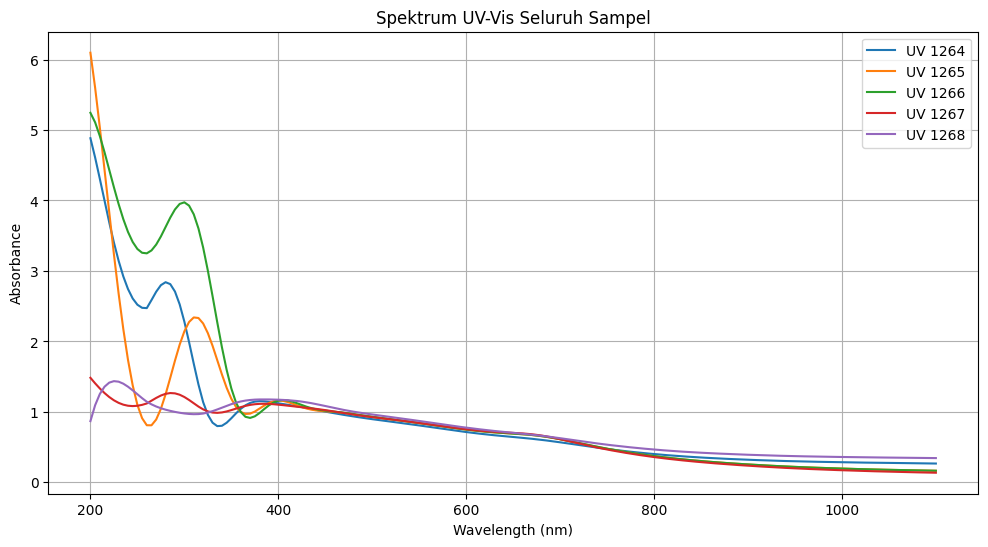

In [8]:
plt.figure(figsize=(12,6))

for i in range(len(df_clean)):

    sample_name = df_clean.iloc[i]['Name']

    absorbance = df_clean.iloc[
        i
    ][wavelength_cols].values

    plt.plot(

        wavelength,

        absorbance,

        label=sample_name

    )

plt.xlabel(
    'Wavelength (nm)'
)

plt.ylabel(
    'Absorbance'
)

plt.title(
    'Spektrum UV-Vis Seluruh Sampel'
)

plt.legend()

plt.grid(True)

plt.show()

## Evaluasi Model

In [9]:
def evaluate_model(model_name, y_test, y_pred):

    r2 = r2_score(
        y_test,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )

    return [
        model_name,
        r2,
        rmse
    ]

## Fungsi Visualisasi

In [10]:
def plot_result(
        wavelength,
        y_actual,
        y_pred,
        sample_name,
        model_name,
        split_label):

    plt.figure(figsize=(12,6))

    plt.plot(
        wavelength,
        y_actual,
        label='Aktual',
        linewidth=3
    )

    plt.plot(
        wavelength,
        y_pred,
        '--',
        label='Prediksi'
    )

    plt.xlabel(
        'Wavelength (nm)'
    )

    plt.ylabel(
        'Absorbance'
    )

    plt.title(
        f'{sample_name} - {model_name} ({split_label})'
    )

    plt.legend()

    plt.grid(True)

    plt.show()

## Main Function

In [11]:
def run_sample(
        sample_name,
        transformed_data,
        test_size=0.3,
        show_plot=True):

    print("\n")
    print("="*60)
    print(
        f"SAMPEL : {sample_name}"
    )
    print("="*60)
    
    split_label = (
        f"{int((1-test_size)*100)}:"
        f"{int(test_size*100)}"
    )

    # Bentuk X dan y

    X = transformed_data[
        ['Wavelength']
    ].values
    y = transformed_data[
        'Absorbance'
    ].values
    print(
        "Shape X :",
        X.shape
    )
    print(
        "Shape y :",
        y.shape
    )

    # Split Data

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        shuffle=True,
        random_state=42
    )

    # Tampilkan Train dan Test

    train_df = pd.DataFrame({

        'Wavelength':
            X_train.flatten(),
        'Absorbance':
            y_train
    })

    test_df = pd.DataFrame({

        'Wavelength':
            X_test.flatten(),
        'Absorbance':
            y_test
    })

    print("\nTRAIN DATA")
    display(train_df)

    print("\nTEST DATA")
    display(test_df)

    # StandardScaler

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(
        X_train
    )
    X_test_scaled = scaler.transform(
        X_test
    )
    X_full_scaled = scaler.transform(
        X
    )
    results = []

    # Linear Regression

    linear = LinearRegression()
    linear.fit(
        X_train_scaled,
        y_train
    )
    pred_test = linear.predict(
        X_test_scaled
    )
    pred_full = linear.predict(
        X_full_scaled
    )

    # Residu
    residu = y_test - pred_test

    df_residu = pd.DataFrame({
    'Wavelength': X_test.flatten(),
    'Aktual': y_test,
    'Prediksi': pred_test,
    'Residu': residu
    })
    df_residu = df_residu.sort_values(
        by='Wavelength'
    ).reset_index(drop=True)

    print("\nResidu Linear Regression")
    display(df_residu)

    results.append(
        evaluate_model(
            "Linear Regression",
            y_test,
            pred_test
        )
    )

    if show_plot:
        plot_result(
            wavelength,
            y,
            pred_full,
            sample_name,
            "Linear Regression",
            split_label
        )

    # Polynomial Regression

    poly = Pipeline([
        ('poly',PolynomialFeatures(degree=2, include_bias=False)),
        ('linear', LinearRegression())
    ])

    poly.fit(
        X_train_scaled,
        y_train
    )

    pred_test = poly.predict(
        X_test_scaled
    )

    pred_full = poly.predict(
        X_full_scaled
    )

    residu = y_test - pred_test
    df_residu = pd.DataFrame({
    'Wavelength': X_test.flatten(),
    'Aktual': y_test,
    'Prediksi': pred_test,
    'Residu': residu
    })
    df_residu = df_residu.sort_values(
        by='Wavelength'
    ).reset_index(drop=True)

    print("\nResidu Polynomial Regression")
    display(df_residu)

    results.append(
        evaluate_model(
            "Polynomial Regression",
            y_test,
            pred_test
        )
    )

    if show_plot:
        plot_result(
            wavelength,
            y,
            pred_full,
            sample_name,
            "Polynomial Regression",
            split_label
        )

    # Random Forest

    rf = RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )

    rf.fit(
        X_train_scaled,
        y_train
    )
    pred_test = rf.predict(
        X_test_scaled
    )
    pred_full = rf.predict(
        X_full_scaled
    )

    residu = y_test - pred_test
    df_residu = pd.DataFrame({
    'Wavelength': X_test.flatten(),
    'Aktual': y_test,
    'Prediksi': pred_test,
    'Residu': residu
    })
    df_residu = df_residu.sort_values(
        by='Wavelength'
    ).reset_index(drop=True)

    print("\nResidu Random Forest")
    display(df_residu)

    results.append(
        evaluate_model(
            "Random Forest",
            y_test,
            pred_test
        )
    )

    if show_plot:
        plot_result(
            wavelength,
            y,
            pred_full,
            sample_name,
            "Random Forest",
            split_label
        )

    hasil = pd.DataFrame(
        results,
        columns=[
            "Model",
            "R2",
            "RMSE"
        ]
    )
    hasil.insert(
        0,
        "Split",
        split_label
    )

    hasil.insert(
        0,
        "Sample",
        sample_name
    )

    print("\nHASIL EVALUASI")

    display(
        hasil
    )

    # Cari model terbaik berdasarkan RMSE terkecil
    best_idx = hasil['RMSE'].idxmin()

    best_model = hasil.loc[
        best_idx,
        'Model'
    ]

    print("\nModel terbaik :", best_model)

    if best_model == "Linear Regression":

        best_pred = pred_full

    elif best_model == "Polynomial Regression":

        best_pred = pred_full

    else:

        best_pred = pred_full

    return hasil, best_model, best_pred

In [12]:
sample_data = {}

for i in range(len(df_clean)):

    sample_name, transformed = transform_sample(
        df_clean,
        i
    )

    sample_data[sample_name] = transformed

print(sample_data.keys())

dict_keys(['UV 1264', 'UV 1265', 'UV 1266', 'UV 1267', 'UV 1268'])


## Daftar Split Data

In [13]:
split_list = [

    0.4,   # 60:40
    0.3,   # 70:30
    0.2,   # 80:20
    0.1    # 90:10

]

## Skenario 1
Train:
UV 1264, 1265, 1266
Test/Pembanding:
UV 1267



SAMPEL : UV 1264
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,760,0.4573
1,220,3.6904
2,360,1.0427
3,705,0.5584
4,840,0.3606
...,...,...
103,730,0.5099
104,270,2.7046
105,660,0.6311
106,1095,0.2681



TEST DATA


,Wavelength,Absorbance
0,295,2.5257
1,410,1.1009
2,965,0.2942
3,590,0.7313
4,925,0.3086
...,...,...
68,575,0.7594
69,930,0.3065
70,255,2.4765
71,230,3.1441



Residu Linear Regression


,Wavelength,Aktual,Prediksi,Residu
0,210,4.3077,2.135262,2.172438
1,230,3.1441,2.080442,1.063658
2,245,2.6087,2.039326,0.569374
3,255,2.4765,2.011916,0.464584
4,260,2.4723,1.998211,0.474089
...,...,...,...,...
68,1045,0.2763,-0.153498,0.429798
69,1055,0.2748,-0.180908,0.455708
70,1060,0.2741,-0.194613,0.468713
71,1065,0.2733,-0.208319,0.481619


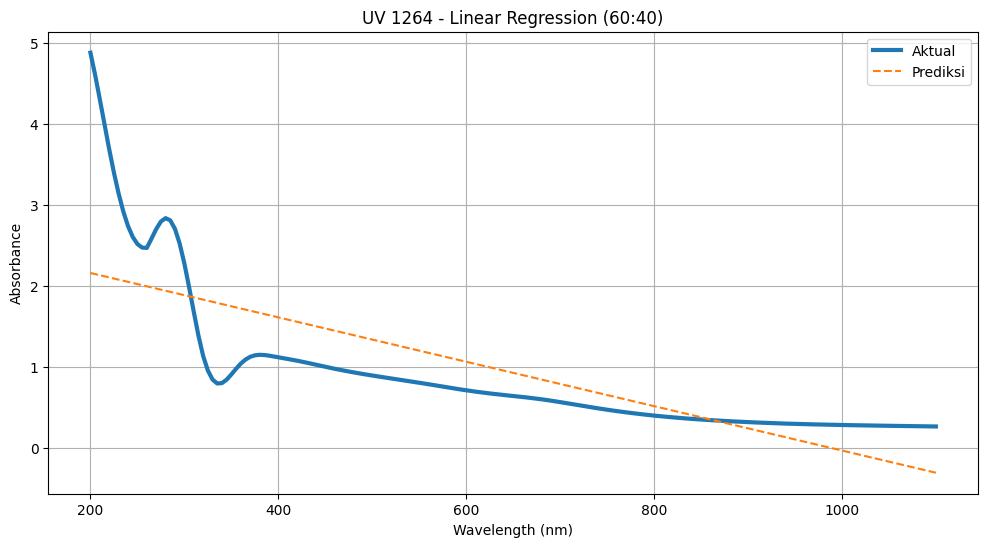


Residu Polynomial Regression


,Wavelength,Aktual,Prediksi,Residu
0,210,4.3077,3.033462,1.274238
1,230,3.1441,2.857663,0.286437
2,245,2.6087,2.729480,-0.12078
3,255,2.4765,2.645772,-0.169272
4,260,2.4723,2.604441,-0.132141
...,...,...,...,...
68,1045,0.2763,0.447407,-0.171107
69,1055,0.2748,0.475461,-0.200661
70,1060,0.2741,0.490012,-0.215912
71,1065,0.2733,0.504912,-0.231612


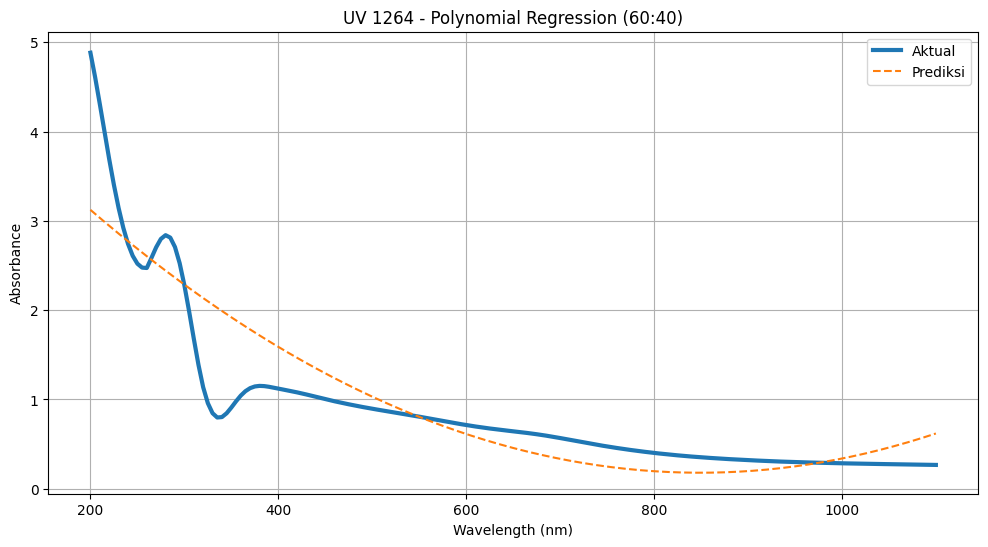


Residu Random Forest


,Wavelength,Aktual,Prediksi,Residu
0,210,4.3077,4.150860,0.15684
1,230,3.1441,3.235408,-0.091308
2,245,2.6087,2.618651,-0.009951
3,255,2.4765,2.576159,-0.099659
4,260,2.4723,2.601311,-0.129011
...,...,...,...,...
68,1045,0.2763,0.276783,-0.000483
69,1055,0.2748,0.275559,-0.000759
70,1060,0.2741,0.274571,-0.000471
71,1065,0.2733,0.272960,0.00034


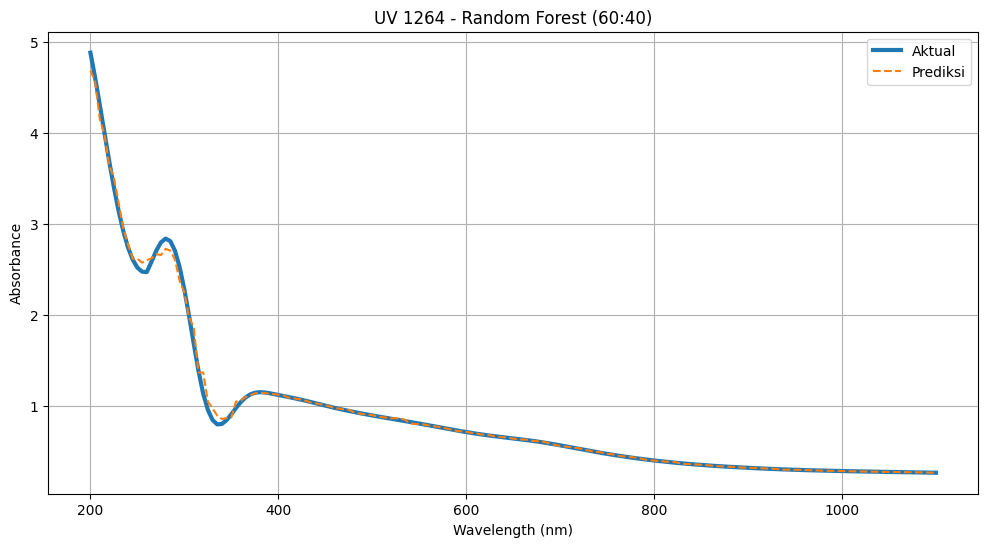


HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1264,60:40,Linear Regression,0.596734,0.521653
1,UV 1264,60:40,Polynomial Regression,0.754241,0.407231
2,UV 1264,60:40,Random Forest,0.995025,0.057941



Model terbaik : Random Forest


SAMPEL : UV 1264
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,625,0.675
1,960,0.2957
2,610,0.6972
3,935,0.3044
4,330,0.8463
...,...,...
121,730,0.5099
122,270,2.7046
123,660,0.6311
124,1095,0.2681



TEST DATA


,Wavelength,Absorbance
0,295,2.5257
1,410,1.1009
2,965,0.2942
3,590,0.7313
4,925,0.3086
5,275,2.7978
6,320,1.1376
7,540,0.8257
8,765,0.4494
9,790,0.4139



Residu Linear Regression


,Wavelength,Aktual,Prediksi,Residu
0,210,4.3077,2.088663,2.219037
1,245,2.6087,1.995159,0.613541
2,260,2.4723,1.955086,0.517214
3,275,2.7978,1.915012,0.882788
4,280,2.8399,1.901655,0.938245
5,290,2.7072,1.874939,0.832261
6,295,2.5257,1.861582,0.664118
7,320,1.1376,1.794793,-0.657193
8,345,0.8455,1.728005,-0.882505
9,350,0.9094,1.714647,-0.805247


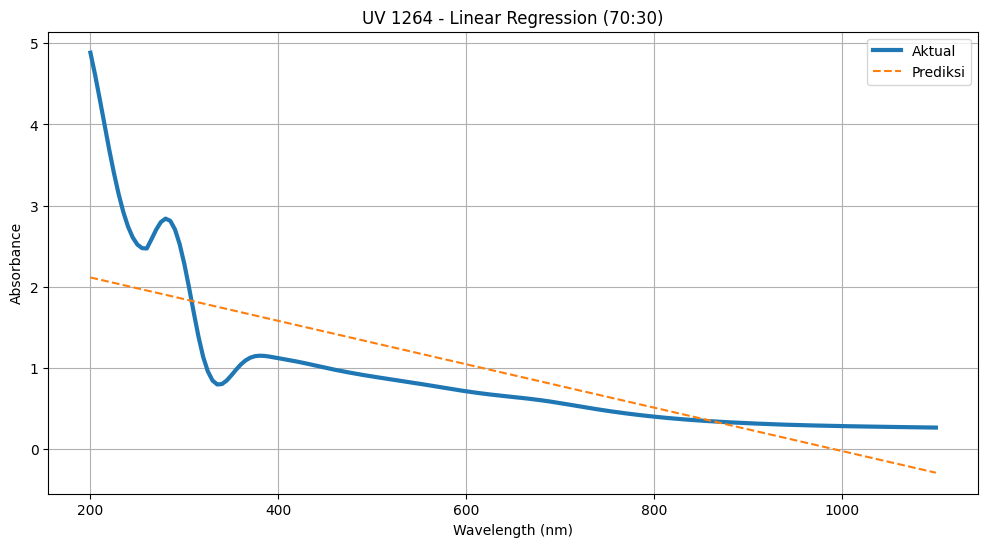


Residu Polynomial Regression


,Wavelength,Aktual,Prediksi,Residu
0,210,4.3077,2.917840,1.38986
1,245,2.6087,2.628034,-0.019334
2,260,2.4723,2.508824,-0.036524
3,275,2.7978,2.392611,0.405189
4,280,2.8399,2.354538,0.485362
5,290,2.7072,2.279393,0.427807
6,295,2.5257,2.242319,0.283381
7,320,1.1376,2.061944,-0.924344
8,345,0.8455,1.889891,-1.044391
9,350,0.9094,1.856479,-0.947079


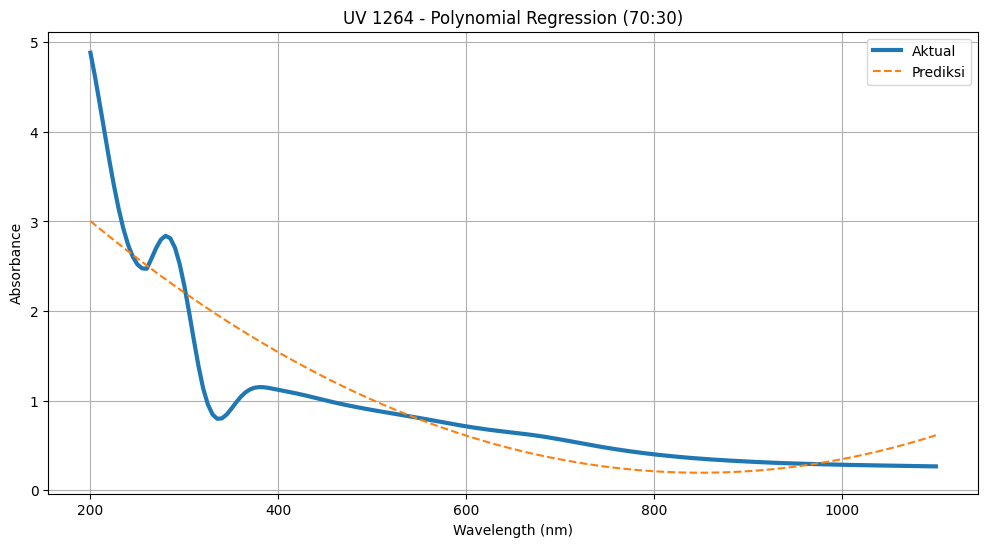


Residu Random Forest


,Wavelength,Aktual,Prediksi,Residu
0,210,4.3077,4.474426,-0.166726
1,245,2.6087,2.584963,0.023737
2,260,2.4723,2.522037,-0.049737
3,275,2.7978,2.672178,0.125622
4,280,2.8399,2.737968,0.101932
5,290,2.7072,2.574224,0.132976
6,295,2.5257,2.337813,0.187887
7,320,1.1376,1.282452,-0.144852
8,345,0.8455,0.816370,0.02913
9,350,0.9094,0.870560,0.03884


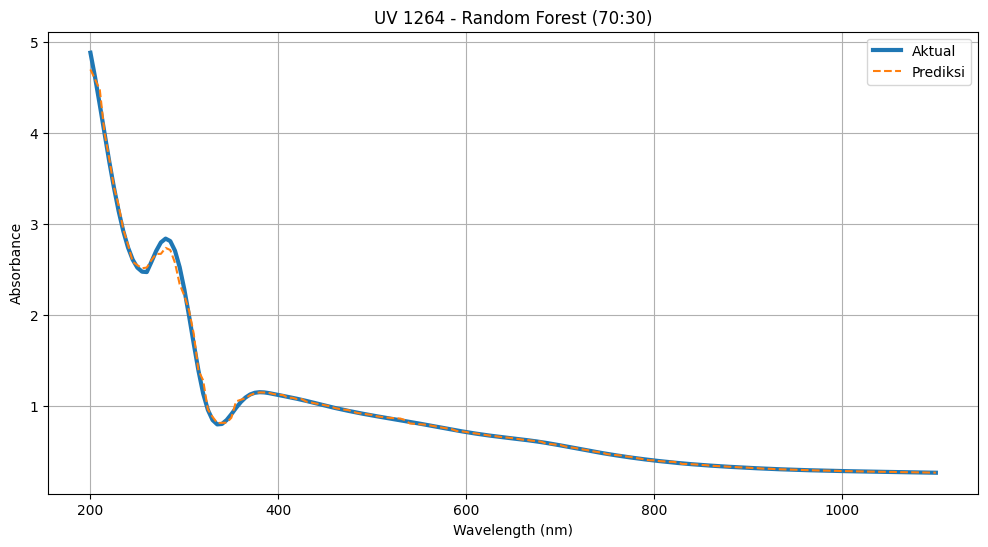


HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1264,70:30,Linear Regression,0.606055,0.526247
1,UV 1264,70:30,Polynomial Regression,0.796119,0.378583
2,UV 1264,70:30,Random Forest,0.996370,0.050512



Model terbaik : Random Forest


SAMPEL : UV 1264
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,525,0.8523
1,535,0.8347
2,355,0.9791
3,260,2.4723
4,405,1.1112
...,...,...
139,730,0.5099
140,270,2.7046
141,660,0.6311
142,1095,0.2681



TEST DATA


,Wavelength,Absorbance
0,295,2.5257
1,410,1.1009
2,965,0.2942
3,590,0.7313
4,925,0.3086
5,275,2.7978
6,320,1.1376
7,540,0.8257
8,765,0.4494
9,790,0.4139



Residu Linear Regression


,Wavelength,Aktual,Prediksi,Residu
0,245,2.6087,1.995716,0.612984
1,275,2.7978,1.916089,0.881711
2,280,2.8399,1.902818,0.937082
3,290,2.7072,1.876276,0.830924
4,295,2.5257,1.863005,0.662695
5,320,1.1376,1.796650,-0.65905
6,345,0.8455,1.730295,-0.884795
7,350,0.9094,1.717024,-0.807624
8,410,1.1009,1.557772,-0.456872
9,425,1.0678,1.517959,-0.450159


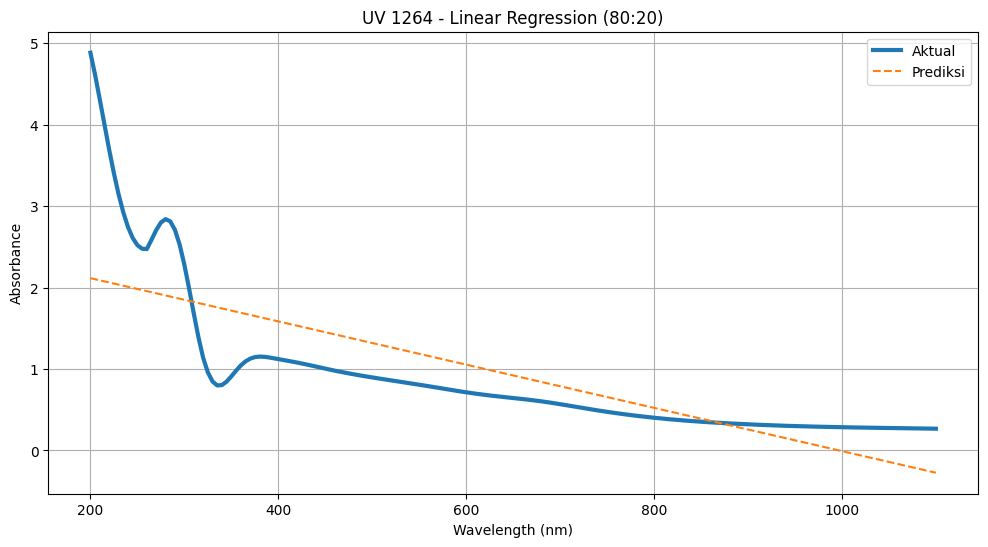


Residu Polynomial Regression


,Wavelength,Aktual,Prediksi,Residu
0,245,2.6087,2.643155,-0.034455
1,275,2.7978,2.404912,0.392888
2,280,2.8399,2.366385,0.473515
3,290,2.7072,2.290343,0.416857
4,295,2.5257,2.252827,0.272873
5,320,1.1376,2.070309,-0.932709
6,345,0.8455,1.896222,-1.050722
7,350,0.9094,1.862416,-0.953016
8,410,1.1009,1.483048,-0.382148
9,425,1.0678,1.395794,-0.327994


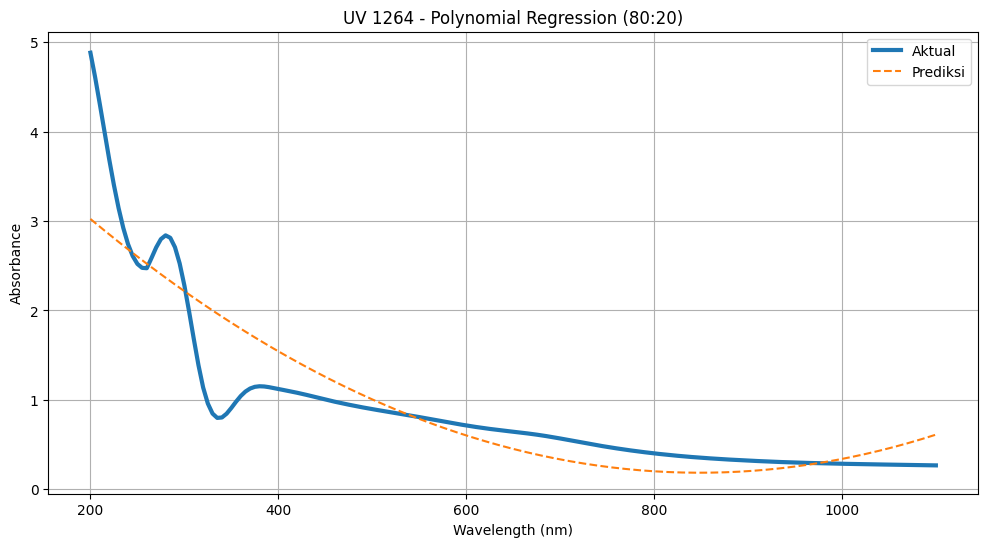


Residu Random Forest


,Wavelength,Aktual,Prediksi,Residu
0,245,2.6087,2.579916,0.028784
1,275,2.7978,2.673433,0.124367
2,280,2.8399,2.759800,0.0801
3,290,2.7072,2.630179,0.077021
4,295,2.5257,2.388003,0.137697
5,320,1.1376,1.290664,-0.153064
6,345,0.8455,0.820263,0.025237
7,350,0.9094,0.976782,-0.067382
8,410,1.1009,1.104999,-0.004099
9,425,1.0678,1.073675,-0.005875


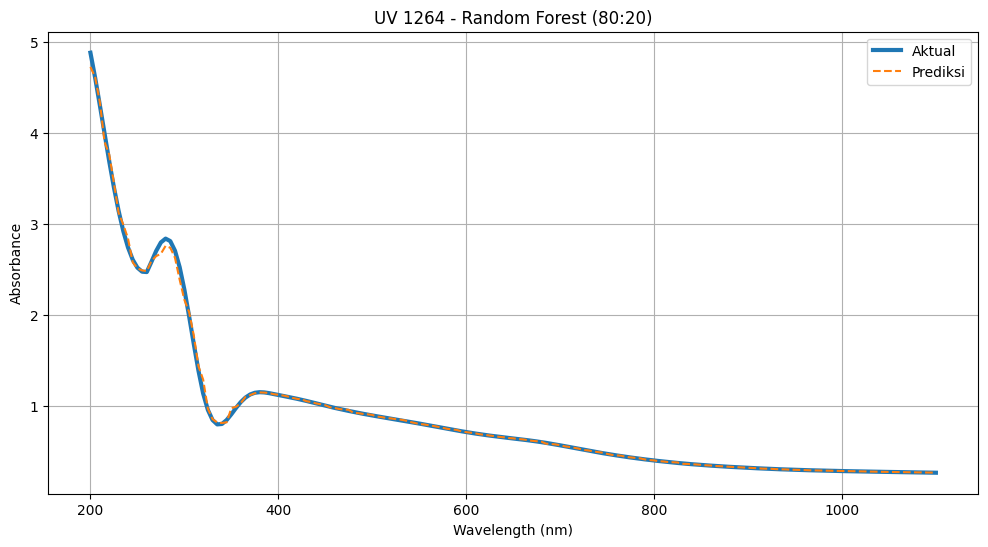


HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1264,80:20,Linear Regression,0.644148,0.455123
1,UV 1264,80:20,Polynomial Regression,0.791625,0.348271
2,UV 1264,80:20,Random Forest,0.996429,0.045590



Model terbaik : Random Forest


SAMPEL : UV 1264
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,480,0.9353
1,685,0.5949
2,800,0.4014
3,915,0.3132
4,350,0.9094
...,...,...
157,730,0.5099
158,270,2.7046
159,660,0.6311
160,1095,0.2681



TEST DATA


,Wavelength,Absorbance
0,295,2.5257
1,410,1.1009
2,965,0.2942
3,590,0.7313
4,925,0.3086
5,275,2.7978
6,320,1.1376
7,540,0.8257
8,765,0.4494
9,790,0.4139



Residu Linear Regression


,Wavelength,Aktual,Prediksi,Residu
0,275,2.7978,1.886243,0.911557
1,280,2.8399,1.873244,0.966656
2,295,2.5257,1.834247,0.691453
3,320,1.1376,1.769252,-0.631652
4,410,1.1009,1.535270,-0.43437
5,425,1.0678,1.496272,-0.428472
6,455,0.9913,1.418278,-0.426978
7,540,0.8257,1.197295,-0.371595
8,545,0.8166,1.184296,-0.367696
9,590,0.7313,1.067305,-0.336005


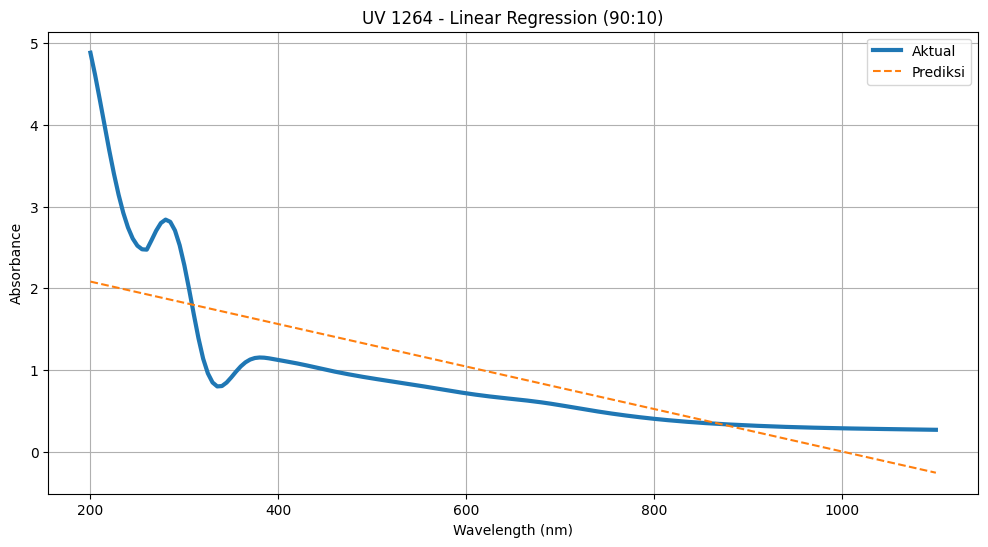


Residu Polynomial Regression


,Wavelength,Aktual,Prediksi,Residu
0,275,2.7978,2.366018,0.431782
1,280,2.8399,2.328371,0.511529
2,295,2.5257,2.217402,0.308298
3,320,1.1376,2.039030,-0.90143
4,410,1.1009,1.464967,-0.364067
5,425,1.0678,1.379649,-0.311849
6,455,0.9913,1.217891,-0.226591
7,540,0.8257,0.823869,0.001831
8,545,0.8166,0.803651,0.012949
9,590,0.7313,0.636487,0.094813


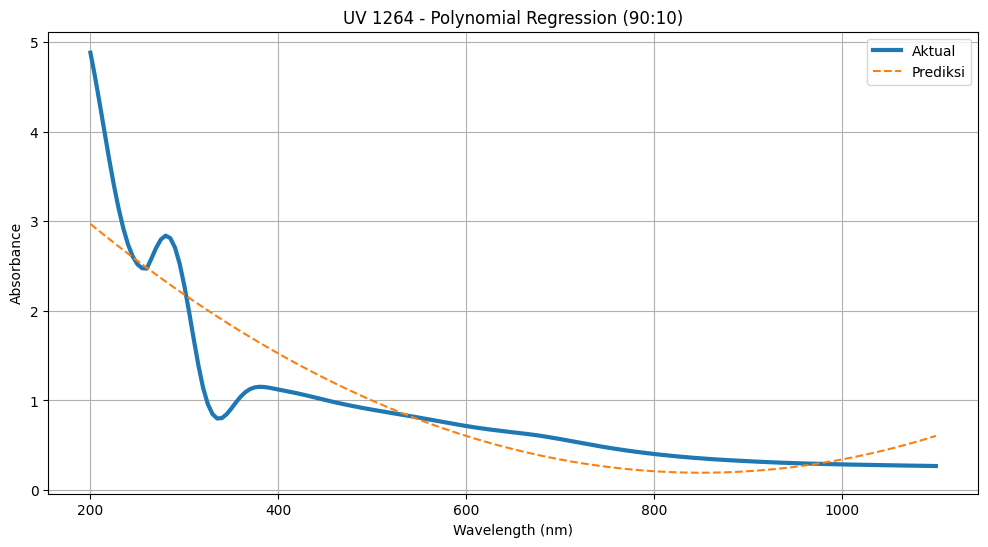


Residu Random Forest


,Wavelength,Aktual,Prediksi,Residu
0,275,2.7978,2.654676,0.143124
1,280,2.8399,2.756945,0.082955
2,295,2.5257,2.548711,-0.023011
3,320,1.1376,1.291877,-0.154277
4,410,1.1009,1.106168,-0.005268
5,425,1.0678,1.073467,-0.005667
6,455,0.9913,1.001041,-0.009741
7,540,0.8257,0.830282,-0.004582
8,545,0.8166,0.815850,0.00075
9,590,0.7313,0.726712,0.004588


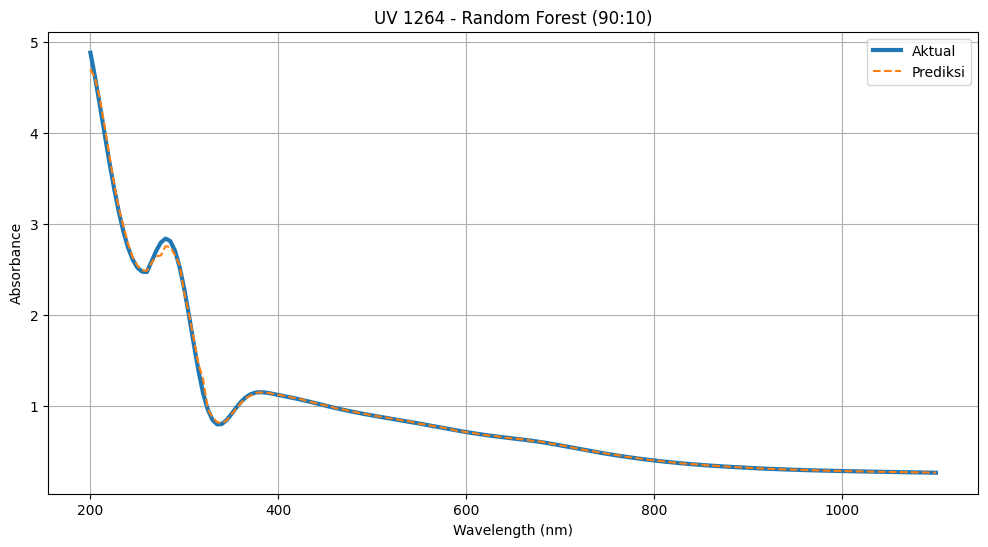


HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1264,90:10,Linear Regression,0.686715,0.452037
1,UV 1264,90:10,Polynomial Regression,0.849001,0.313828
2,UV 1264,90:10,Random Forest,0.995807,0.052293



Model terbaik : Random Forest


SAMPEL : UV 1265
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,760,0.4526
1,220,3.8294
2,360,0.9995
3,705,0.5985
4,840,0.3136
...,...,...
103,730,0.5288
104,270,0.8914
105,660,0.6832
106,1095,0.1657



TEST DATA


,Wavelength,Absorbance
0,295,1.9538
1,410,1.1399
2,965,0.2108
3,590,0.7662
4,925,0.2348
...,...,...
68,575,0.7937
69,930,0.2313
70,255,0.9102
71,230,2.6797



Residu Linear Regression


,Wavelength,Aktual,Prediksi,Residu
0,210,5.036,2.082287,2.953713
1,230,2.6797,2.027982,0.651718
2,245,1.376,1.987253,-0.611253
3,255,0.9102,1.960101,-1.049901
4,260,0.8102,1.946524,-1.136324
...,...,...,...,...
68,1045,0.1789,-0.184954,0.363854
69,1055,0.176,-0.212106,0.388106
70,1060,0.1747,-0.225683,0.400383
71,1065,0.1733,-0.239259,0.412559


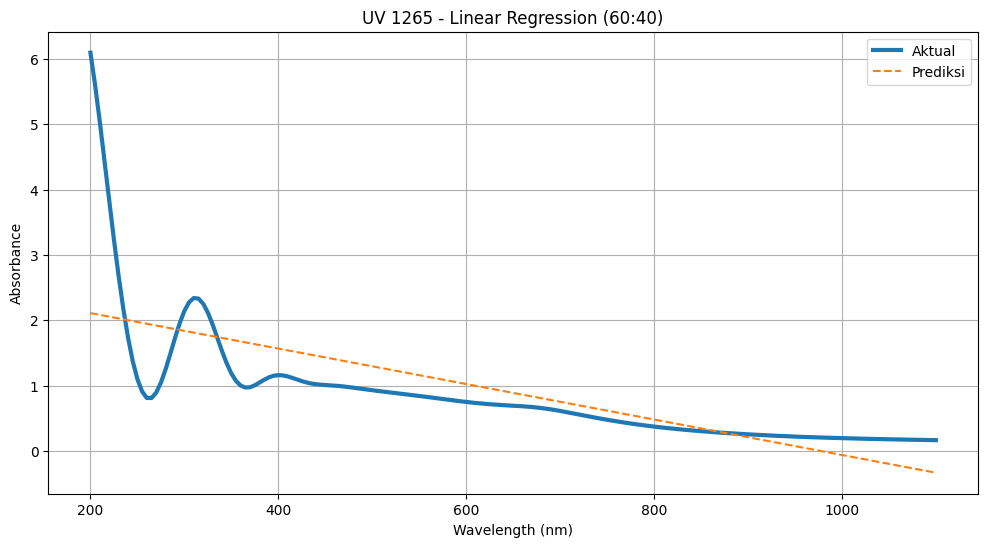


Residu Polynomial Regression


,Wavelength,Aktual,Prediksi,Residu
0,210,5.036,2.851712,2.184288
1,230,2.6797,2.693773,-0.014073
2,245,1.376,2.578460,-1.20246
3,255,0.9102,2.503081,-1.592881
4,260,0.8102,2.465840,-1.65564
...,...,...,...,...
68,1045,0.1789,0.329800,-0.1509
69,1055,0.176,0.350159,-0.174159
70,1060,0.1747,0.360788,-0.186088
71,1065,0.1733,0.371716,-0.198416


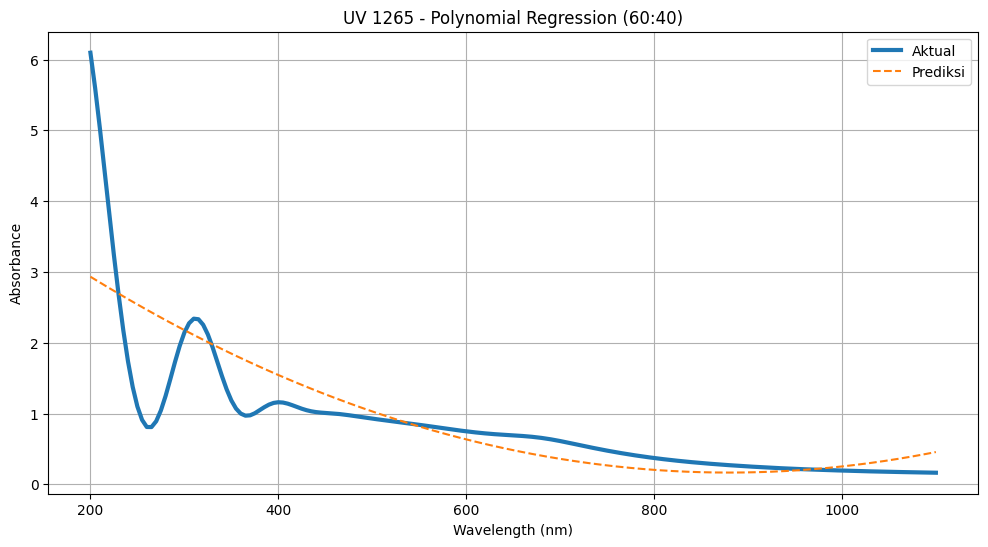


Residu Random Forest


,Wavelength,Aktual,Prediksi,Residu
0,210,5.036,4.727121,0.308879
1,230,2.6797,2.862499,-0.182799
2,245,1.376,1.359515,0.016485
3,255,0.9102,1.139212,-0.229012
4,260,0.8102,0.946942,-0.136742
...,...,...,...,...
68,1045,0.1789,0.179815,-0.000915
69,1055,0.176,0.177527,-0.001527
70,1060,0.1747,0.175703,-0.001003
71,1065,0.1733,0.172762,0.000538


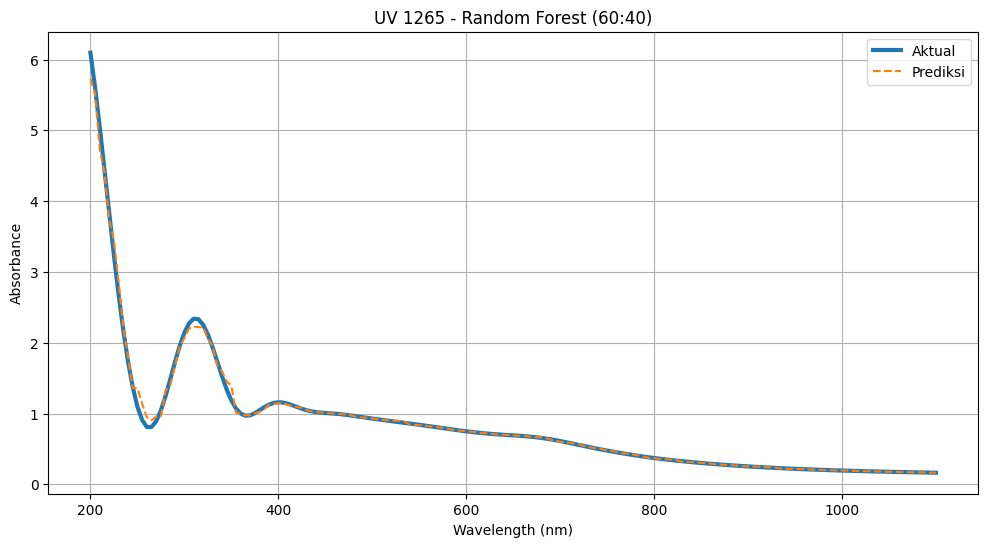


HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1265,60:40,Linear Regression,0.541387,0.506828
1,UV 1265,60:40,Polynomial Regression,0.550878,0.501556
2,UV 1265,60:40,Random Forest,0.992735,0.063791



Model terbaik : Random Forest


SAMPEL : UV 1265
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,625,0.7144
1,960,0.2133
2,610,0.7337
3,935,0.228
4,330,1.9379
...,...,...
121,730,0.5288
122,270,0.8914
123,660,0.6832
124,1095,0.1657



TEST DATA


,Wavelength,Absorbance
0,295,1.9538
1,410,1.1399
2,965,0.2108
3,590,0.7662
4,925,0.2348
5,275,1.0436
6,320,2.2541
7,540,0.8595
8,765,0.4412
9,790,0.39



Residu Linear Regression


,Wavelength,Aktual,Prediksi,Residu
0,210,5.036,2.055529,2.980471
1,245,1.376,1.962056,-0.586056
2,260,0.8102,1.921996,-1.111796
3,275,1.0436,1.881937,-0.838337
4,280,1.2481,1.868583,-0.620483
5,290,1.7269,1.841877,-0.114977
6,295,1.9538,1.828524,0.125276
7,320,2.2541,1.761757,0.492343
8,345,1.3422,1.694991,-0.352791
9,350,1.1858,1.681638,-0.495838


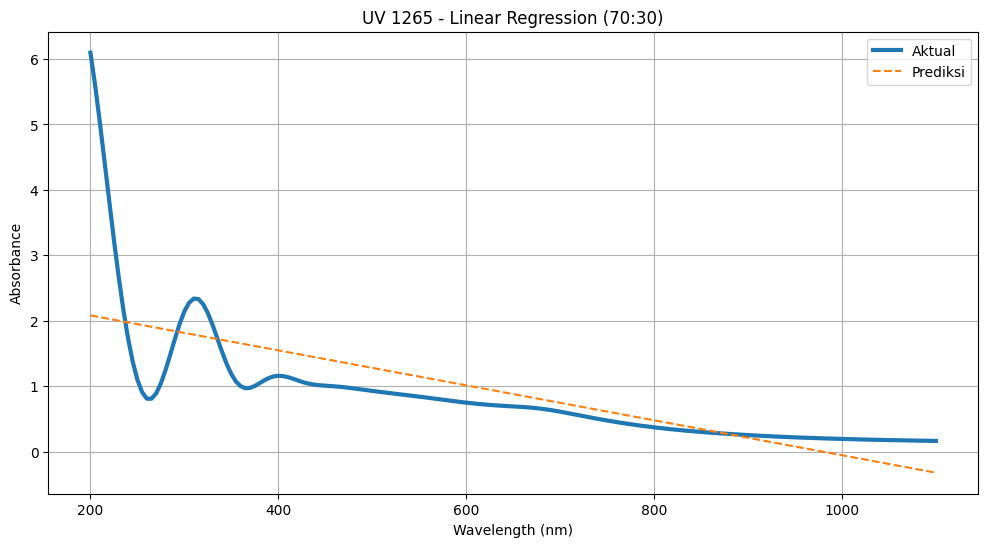


Residu Polynomial Regression


,Wavelength,Aktual,Prediksi,Residu
0,210,5.036,2.745672,2.290328
1,245,1.376,2.488812,-1.112812
2,260,0.8102,2.382886,-1.572686
3,275,1.0436,2.279452,-1.235852
4,280,1.2481,2.245529,-0.997429
5,290,1.7269,2.178512,-0.451612
6,295,1.9538,2.145420,-0.19162
7,320,2.2541,1.984113,0.269987
8,345,1.3422,1.829733,-0.487533
9,350,1.1858,1.799688,-0.613888


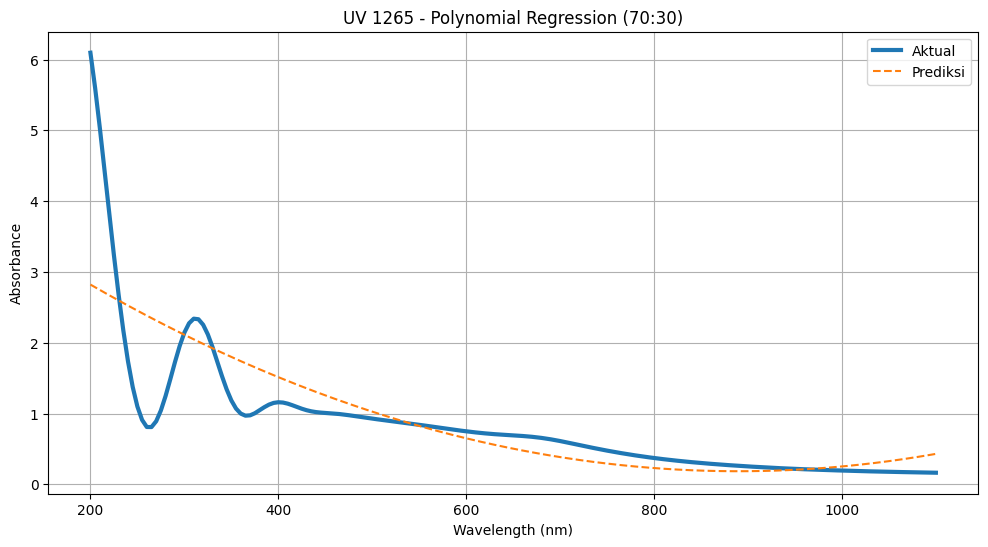


Residu Random Forest


,Wavelength,Aktual,Prediksi,Residu
0,210,5.036,5.340207,-0.304207
1,245,1.376,1.272292,0.103708
2,260,0.8102,0.953561,-0.143361
3,275,1.0436,0.965406,0.078194
4,280,1.2481,1.281571,-0.033471
5,290,1.7269,1.746030,-0.01913
6,295,1.9538,2.038481,-0.084681
7,320,2.2541,2.264456,-0.010356
8,345,1.3422,1.625160,-0.28296
9,350,1.1858,1.405760,-0.21996


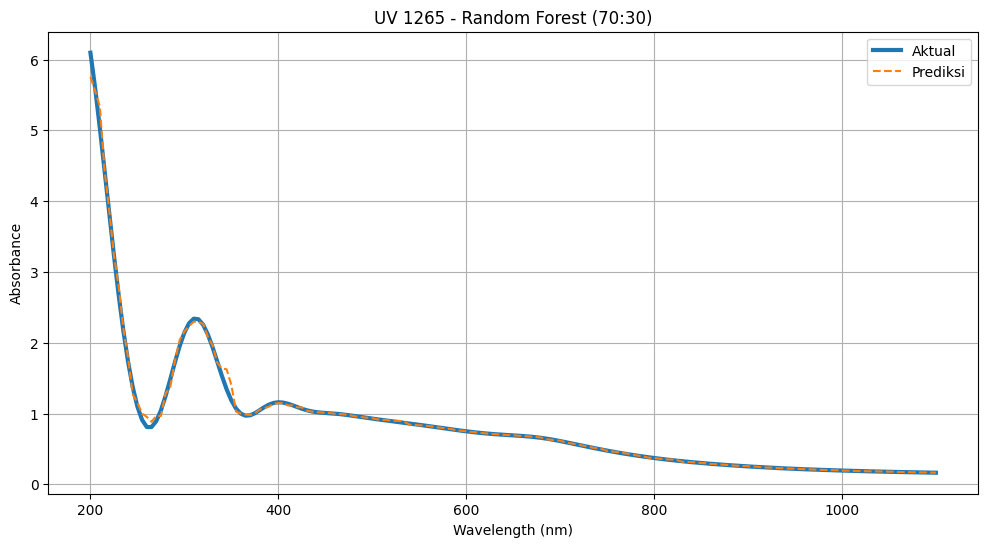


HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1265,70:30,Linear Regression,0.488901,0.535297
1,UV 1265,70:30,Polynomial Regression,0.538044,0.508912
2,UV 1265,70:30,Random Forest,0.991157,0.070413



Model terbaik : Random Forest


SAMPEL : UV 1265
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,525,0.8855
1,535,0.8683
2,355,1.0705
3,260,0.8102
4,405,1.1554
...,...,...
139,730,0.5288
140,270,0.8914
141,660,0.6832
142,1095,0.1657



TEST DATA


,Wavelength,Absorbance
0,295,1.9538
1,410,1.1399
2,965,0.2108
3,590,0.7662
4,925,0.2348
5,275,1.0436
6,320,2.2541
7,540,0.8595
8,765,0.4412
9,790,0.39



Residu Linear Regression


,Wavelength,Aktual,Prediksi,Residu
0,245,1.376,1.953963,-0.577963
1,275,1.0436,1.874663,-0.831063
2,280,1.2481,1.861447,-0.613347
3,290,1.7269,1.835014,-0.108114
4,295,1.9538,1.821797,0.132003
5,320,2.2541,1.755715,0.498385
6,345,1.3422,1.689632,-0.347432
7,350,1.1858,1.676416,-0.490616
8,410,1.1399,1.517817,-0.377917
9,425,1.0682,1.478168,-0.409968


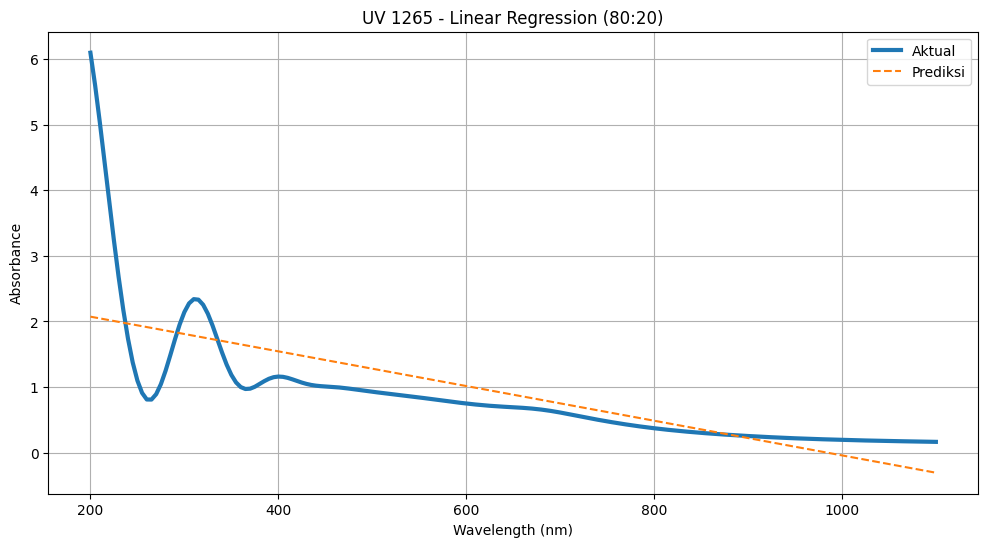


Residu Polynomial Regression


,Wavelength,Aktual,Prediksi,Residu
0,245,1.376,2.494984,-1.118984
1,275,1.0436,2.283139,-1.239539
2,280,1.2481,2.248818,-1.000718
3,290,1.7269,2.181021,-0.454121
4,295,1.9538,2.147546,-0.193746
5,320,2.2541,1.984393,0.269707
6,345,1.3422,1.828286,-0.486086
7,350,1.1858,1.797910,-0.61211
8,410,1.1399,1.455376,-0.315476
9,425,1.0682,1.376083,-0.307883


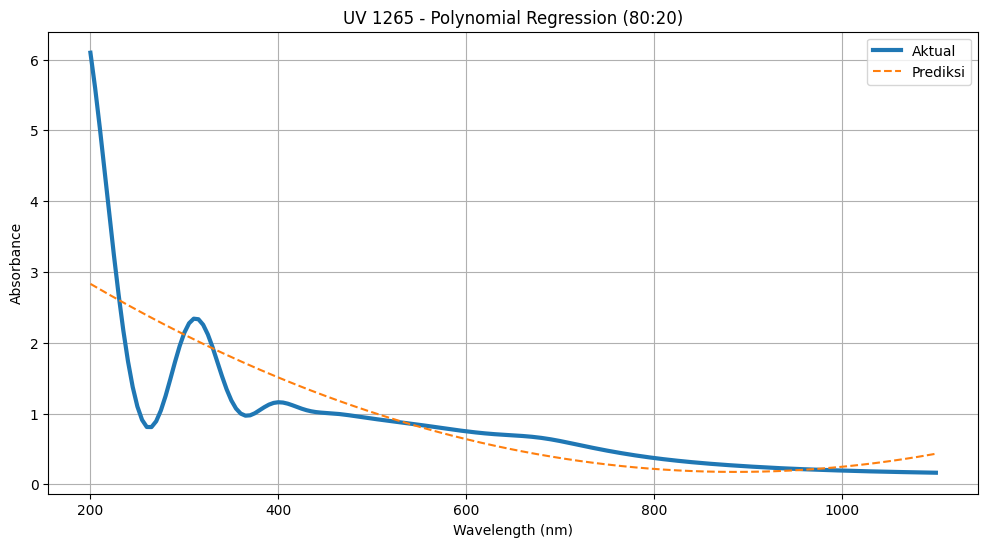


Residu Random Forest


,Wavelength,Aktual,Prediksi,Residu
0,245,1.376,1.259400,0.1166
1,275,1.0436,0.933428,0.110172
2,280,1.2481,1.328756,-0.080656
3,290,1.7269,1.675506,0.051394
4,295,1.9538,1.973238,-0.019438
5,320,2.2541,2.257070,-0.00297
6,345,1.3422,1.538745,-0.196545
7,350,1.1858,1.108902,0.076898
8,410,1.1399,1.141651,-0.001751
9,425,1.0682,1.082364,-0.014164


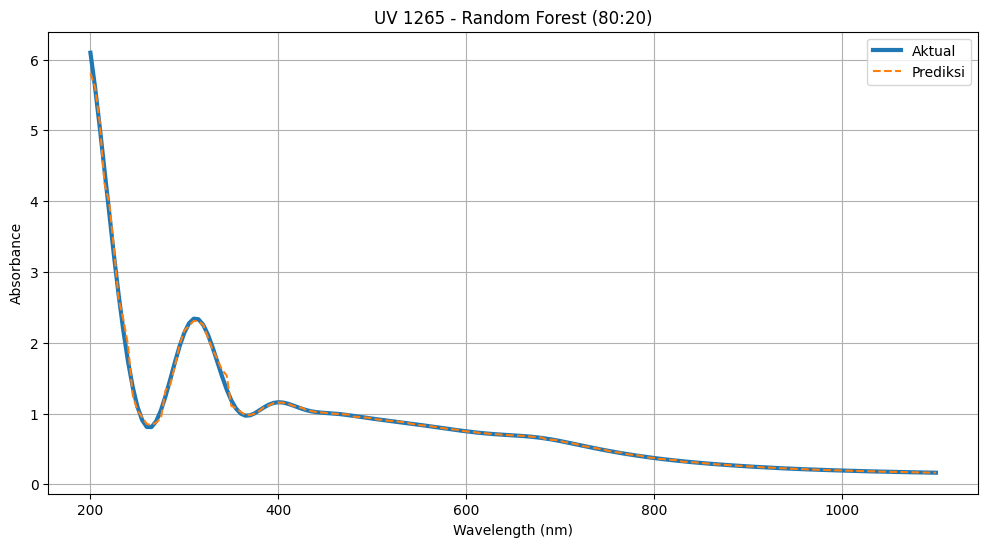


HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1265,80:20,Linear Regression,0.612800,0.322010
1,UV 1265,80:20,Polynomial Regression,0.449189,0.384064
2,UV 1265,80:20,Random Forest,0.991850,0.046716



Model terbaik : Random Forest


SAMPEL : UV 1265
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,480,0.967
1,685,0.6469
2,800,0.3721
3,915,0.242
4,350,1.1858
...,...,...
157,730,0.5288
158,270,0.8914
159,660,0.6832
160,1095,0.1657



TEST DATA


,Wavelength,Absorbance
0,295,1.9538
1,410,1.1399
2,965,0.2108
3,590,0.7662
4,925,0.2348
5,275,1.0436
6,320,2.2541
7,540,0.8595
8,765,0.4412
9,790,0.39



Residu Linear Regression


,Wavelength,Aktual,Prediksi,Residu
0,275,1.0436,1.823033,-0.779433
1,280,1.2481,1.810287,-0.562187
2,295,1.9538,1.772048,0.181752
3,320,2.2541,1.708317,0.545783
4,410,1.1399,1.478884,-0.338984
5,425,1.0682,1.440645,-0.372445
6,455,1.0043,1.364168,-0.359868
7,540,0.8595,1.147481,-0.287981
8,545,0.8505,1.134735,-0.284235
9,590,0.7662,1.020018,-0.253818


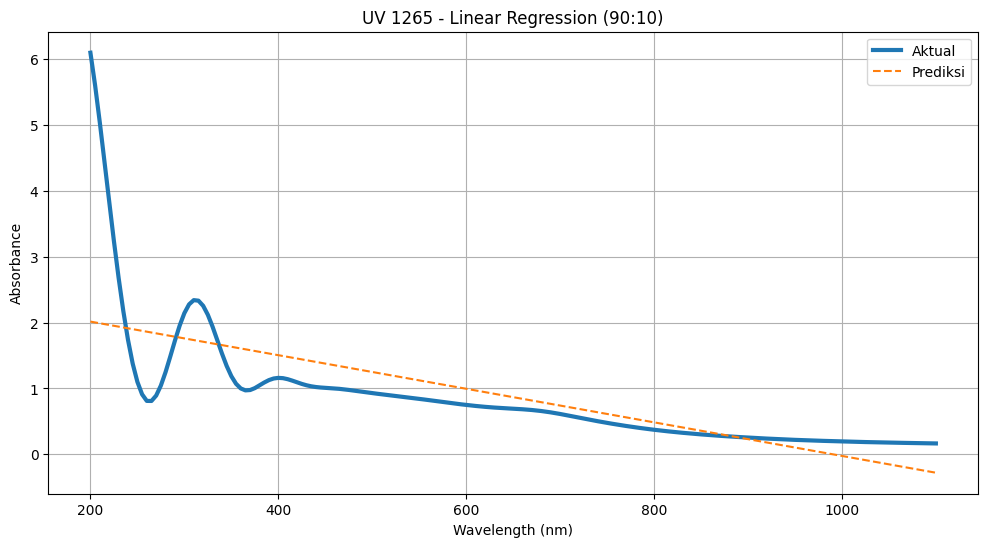


Residu Polynomial Regression


,Wavelength,Aktual,Prediksi,Residu
0,275,1.0436,2.207396,-1.163796
1,280,1.2481,2.174903,-0.926803
2,295,1.9538,2.079005,-0.125205
3,320,2.2541,1.924445,0.329655
4,410,1.1399,1.422563,-0.282663
5,425,1.0682,1.347214,-0.279014
6,455,1.0043,1.203631,-0.199331
7,540,0.8595,0.848318,0.011182
8,545,0.8505,0.829788,0.020712
9,590,0.7662,0.674876,0.091324


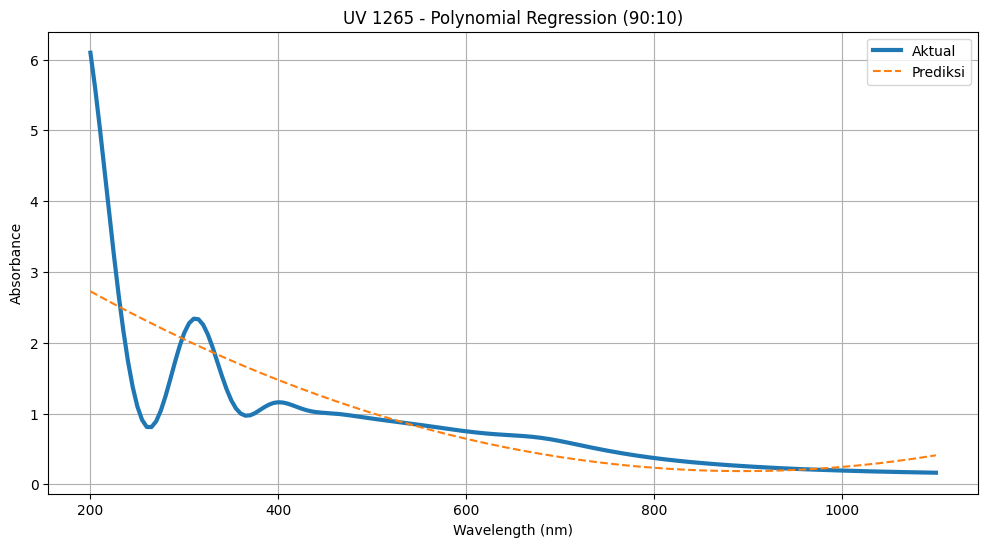


Residu Random Forest


,Wavelength,Aktual,Prediksi,Residu
0,275,1.0436,0.889238,0.154362
1,280,1.2481,1.354891,-0.106791
2,295,1.9538,1.834951,0.118849
3,320,2.2541,2.260193,-0.006093
4,410,1.1399,1.144935,-0.005035
5,425,1.0682,1.082046,-0.013846
6,455,1.0043,1.007770,-0.00347
7,540,0.8595,0.863942,-0.004442
8,545,0.8505,0.849726,0.000774
9,590,0.7662,0.761717,0.004483


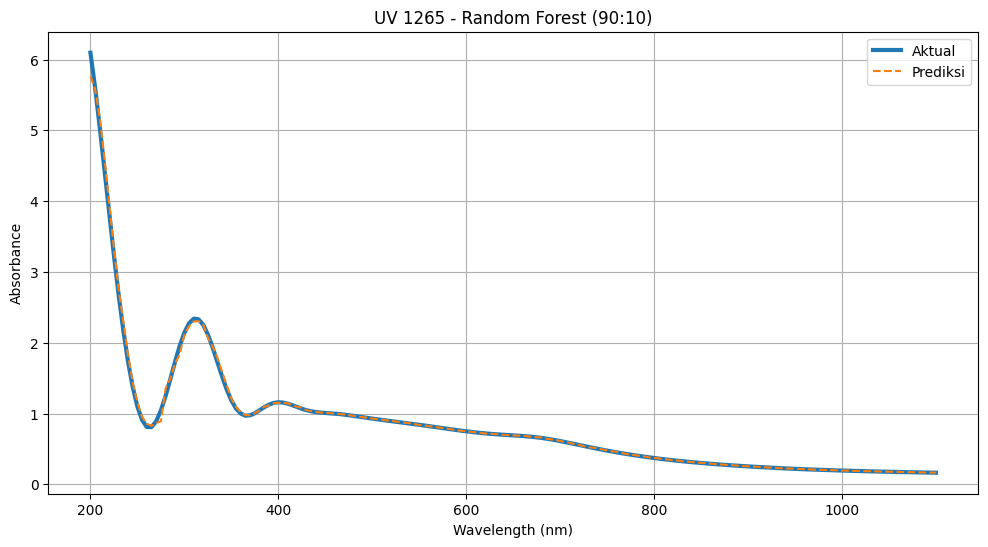


HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1265,90:10,Linear Regression,0.653368,0.325909
1,UV 1265,90:10,Polynomial Regression,0.534224,0.377791
2,UV 1265,90:10,Random Forest,0.991455,0.051171



Model terbaik : Random Forest


SAMPEL : UV 1266
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,760,0.4534
1,220,4.4369
2,360,0.9993
3,705,0.599
4,840,0.3139
...,...,...
103,730,0.5294
104,270,3.3737
105,660,0.6833
106,1095,0.1661



TEST DATA


,Wavelength,Absorbance
0,295,3.9506
1,410,1.162
2,965,0.2112
3,590,0.7658
4,925,0.2352
...,...,...
68,575,0.7934
69,930,0.2317
70,255,3.2576
71,230,3.9494



Residu Linear Regression


,Wavelength,Aktual,Prediksi,Residu
0,210,4.9146,2.703984,2.210616
1,230,3.9494,2.629750,1.31965
2,245,3.4102,2.574075,0.836125
3,255,3.2576,2.536958,0.720642
4,260,3.2495,2.518400,0.7311
...,...,...,...,...
68,1045,0.1791,-0.395271,0.574371
69,1055,0.1762,-0.432387,0.608587
70,1060,0.1748,-0.450946,0.625746
71,1065,0.1735,-0.469504,0.643004


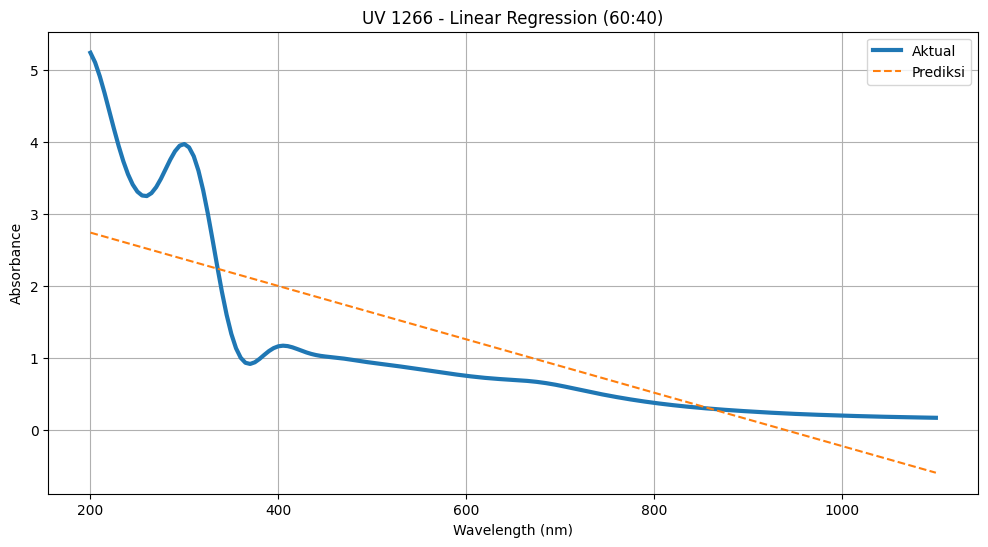


Residu Polynomial Regression


,Wavelength,Aktual,Prediksi,Residu
0,210,4.9146,3.902676,1.011924
1,230,3.9494,3.666990,0.28241
2,245,3.4102,3.495120,-0.08492
3,255,3.2576,3.382870,-0.12527
4,260,3.2495,3.327445,-0.077945
...,...,...,...,...
68,1045,0.1791,0.406667,-0.227567
69,1055,0.1762,0.443570,-0.26737
70,1060,0.1748,0.462721,-0.287921
71,1065,0.1735,0.482337,-0.308837


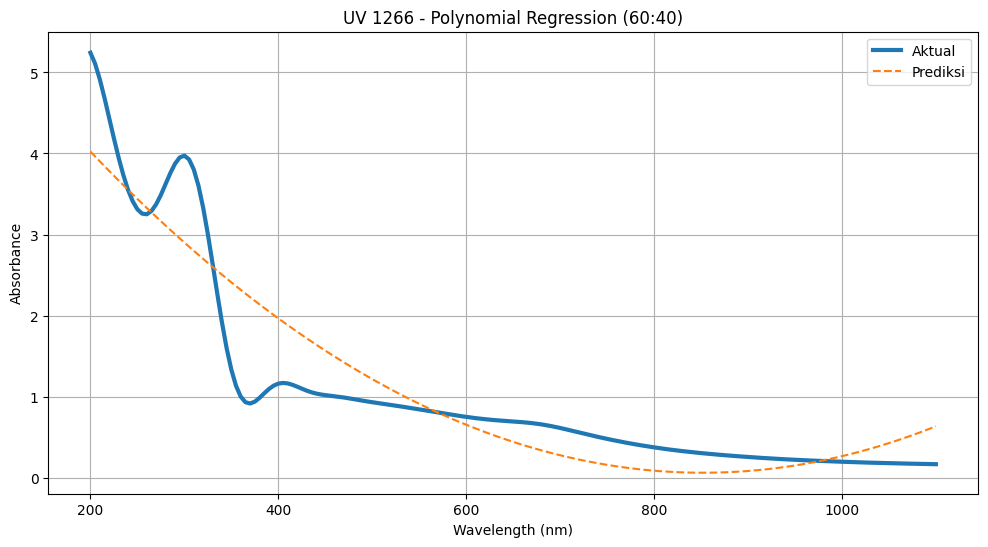


Residu Random Forest


,Wavelength,Aktual,Prediksi,Residu
0,210,4.9146,4.786310,0.12829
1,230,3.9494,4.027739,-0.078339
2,245,3.4102,3.413916,-0.003716
3,255,3.2576,3.348764,-0.091164
4,260,3.2495,3.325656,-0.076156
...,...,...,...,...
68,1045,0.1791,0.180085,-0.000985
69,1055,0.1762,0.177740,-0.00154
70,1060,0.1748,0.175874,-0.001074
71,1065,0.1735,0.172881,0.000619


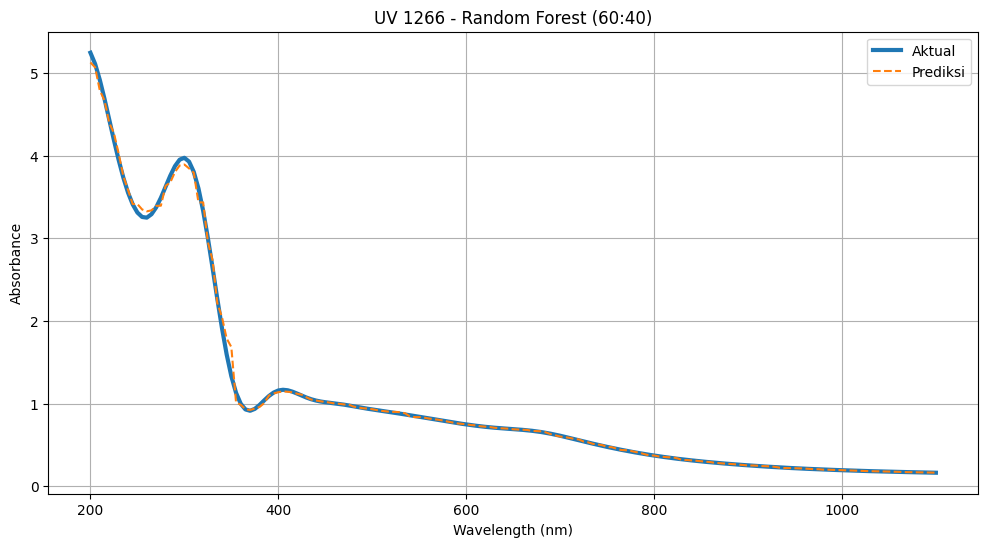


HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1266,60:40,Linear Regression,0.662691,0.695484
1,UV 1266,60:40,Polynomial Regression,0.853266,0.458711
2,UV 1266,60:40,Random Forest,0.997552,0.059248



Model terbaik : Random Forest


SAMPEL : UV 1266
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,625,0.7145
1,960,0.2137
2,610,0.7336
3,935,0.2284
4,330,2.6432
...,...,...
121,730,0.5294
122,270,3.3737
123,660,0.6833
124,1095,0.1661



TEST DATA


,Wavelength,Absorbance
0,295,3.9506
1,410,1.162
2,965,0.2112
3,590,0.7658
4,925,0.2352
5,275,3.4888
6,320,3.3315
7,540,0.8603
8,765,0.442
9,790,0.3906



Residu Linear Regression


,Wavelength,Aktual,Prediksi,Residu
0,210,4.9146,2.748457,2.166143
1,245,3.4102,2.616015,0.794185
2,260,3.2495,2.559254,0.690246
3,275,3.4888,2.502493,0.986307
4,280,3.6221,2.483573,1.138527
5,290,3.8724,2.445732,1.426668
6,295,3.9506,2.426812,1.523788
7,320,3.3315,2.332211,0.999289
8,345,1.5968,2.237609,-0.640809
9,350,1.332,2.218689,-0.886689


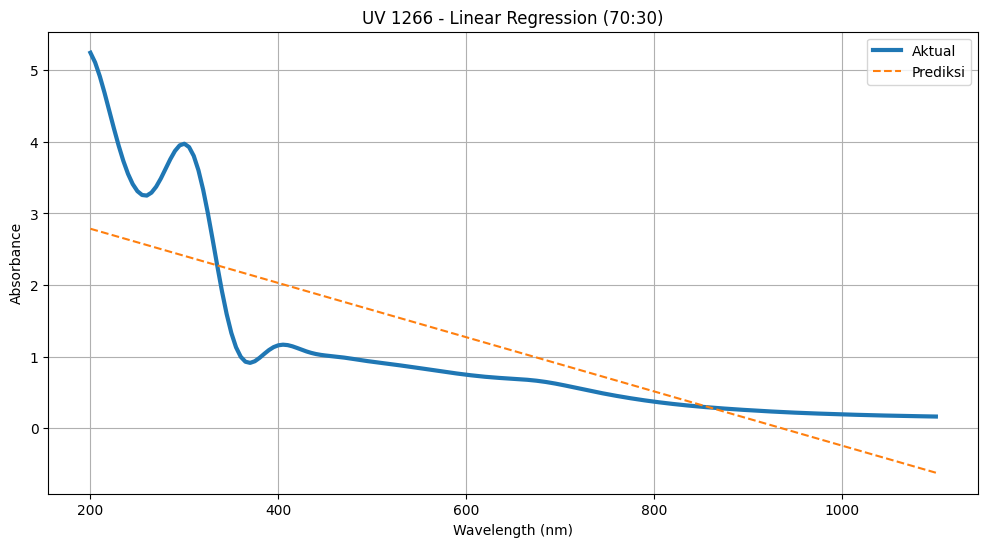


Residu Polynomial Regression


,Wavelength,Aktual,Prediksi,Residu
0,210,4.9146,3.900577,1.014023
1,245,3.4102,3.495379,-0.085179
2,260,3.2495,3.328660,-0.07916
3,275,3.4888,3.166103,0.322697
4,280,3.6221,3.112843,0.509257
5,290,3.8724,3.007710,0.86469
6,295,3.9506,2.955837,0.994763
7,320,3.3315,2.703410,0.62809
8,345,1.5968,2.462547,-0.865747
9,350,1.332,2.415762,-1.083762


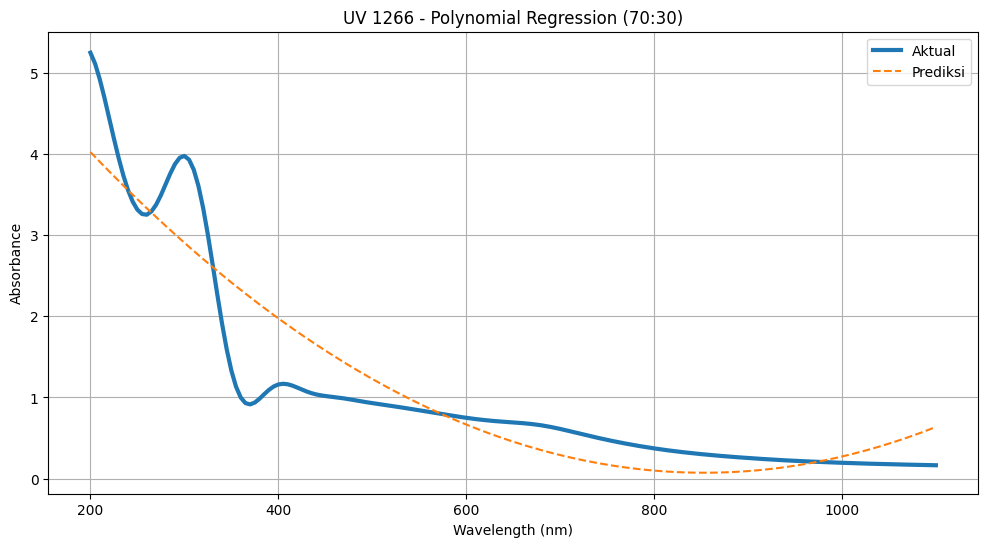


Residu Random Forest


,Wavelength,Aktual,Prediksi,Residu
0,210,4.9146,5.008250,-0.09365
1,245,3.4102,3.379398,0.030802
2,260,3.2495,3.288530,-0.03903
3,275,3.4888,3.405579,0.083221
4,280,3.6221,3.613040,0.00906
5,290,3.8724,3.831746,0.040654
6,295,3.9506,3.925051,0.025549
7,320,3.3315,3.432190,-0.10069
8,345,1.5968,2.084666,-0.487866
9,350,1.332,1.700107,-0.368107


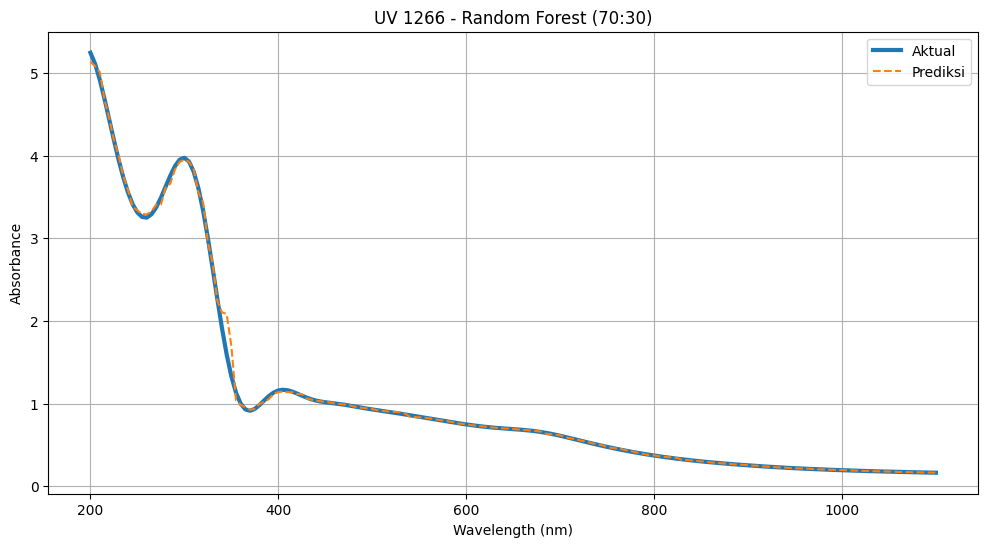


HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1266,70:30,Linear Regression,0.629928,0.712486
1,UV 1266,70:30,Polynomial Regression,0.834952,0.475816
2,UV 1266,70:30,Random Forest,0.994462,0.087162



Model terbaik : Random Forest


SAMPEL : UV 1266
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,525,0.8874
1,535,0.8695
2,355,1.1318
3,260,3.2495
4,405,1.168
...,...,...
139,730,0.5294
140,270,3.3737
141,660,0.6833
142,1095,0.1661



TEST DATA


,Wavelength,Absorbance
0,295,3.9506
1,410,1.162
2,965,0.2112
3,590,0.7658
4,925,0.2352
5,275,3.4888
6,320,3.3315
7,540,0.8603
8,765,0.442
9,790,0.3906



Residu Linear Regression


,Wavelength,Aktual,Prediksi,Residu
0,245,3.4102,2.575833,0.834367
1,275,3.4888,2.465061,1.023739
2,280,3.6221,2.446599,1.175501
3,290,3.8724,2.409675,1.462725
4,295,3.9506,2.391213,1.559387
5,320,3.3315,2.298903,1.032597
6,345,1.5968,2.206593,-0.609793
7,350,1.332,2.188131,-0.856131
8,410,1.162,1.966587,-0.804587
9,425,1.0972,1.911202,-0.814002


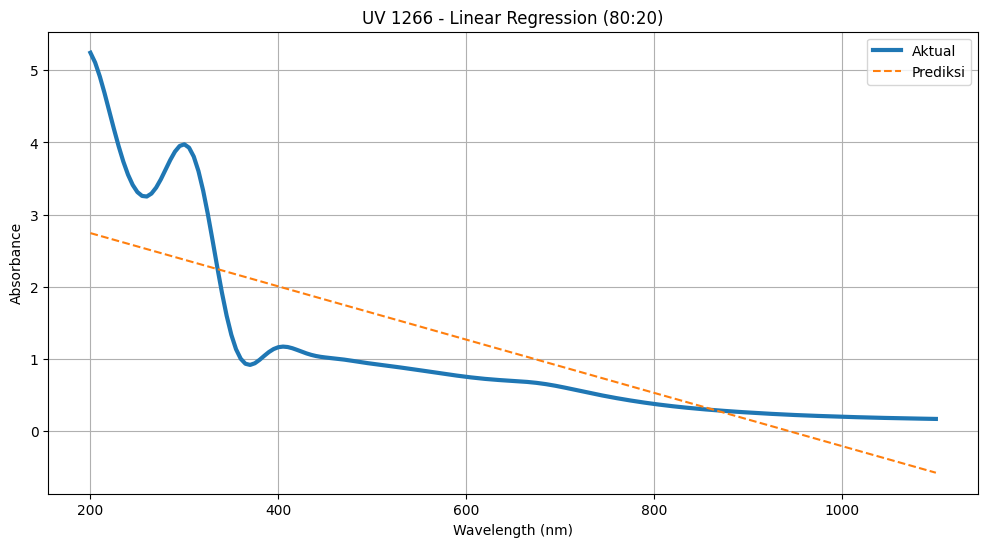


Residu Polynomial Regression


,Wavelength,Aktual,Prediksi,Residu
0,245,3.4102,3.459129,-0.048929
1,275,3.4888,3.131957,0.356843
2,280,3.6221,3.079039,0.543061
3,290,3.8724,2.974582,0.897818
4,295,3.9506,2.923044,1.027556
5,320,3.3315,2.672254,0.659246
6,345,1.5968,2.432965,-0.836165
7,350,1.332,2.386488,-1.054488
8,410,1.162,1.864643,-0.702643
9,425,1.0972,1.744533,-0.647333


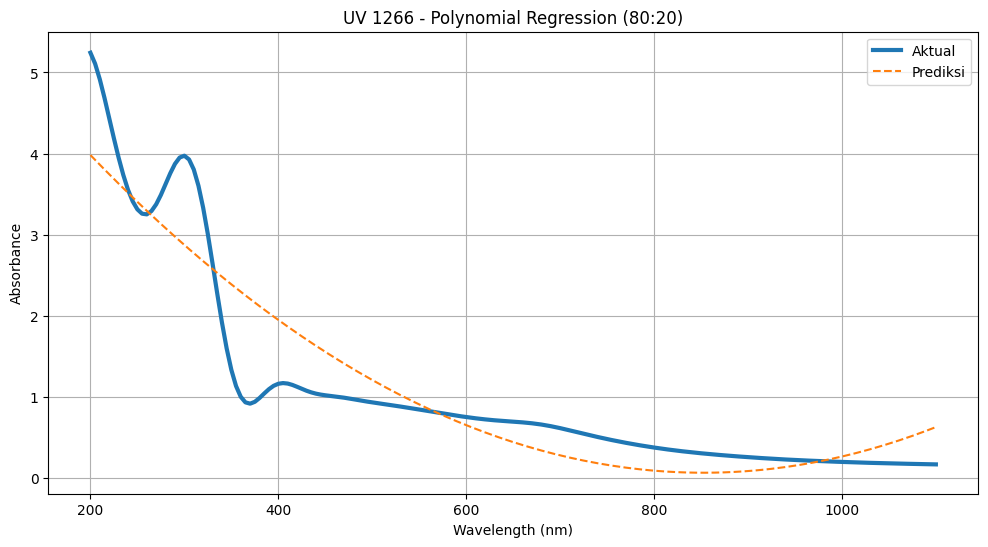


Residu Random Forest


,Wavelength,Aktual,Prediksi,Residu
0,245,3.4102,3.374131,0.036069
1,275,3.4888,3.389244,0.099556
2,280,3.6221,3.648695,-0.026595
3,290,3.8724,3.806624,0.065776
4,295,3.9506,3.902137,0.048463
5,320,3.3315,3.428146,-0.096646
6,345,1.5968,1.932266,-0.335466
7,350,1.332,1.193911,0.138089
8,410,1.162,1.157708,0.004292
9,425,1.0972,1.110888,-0.013688


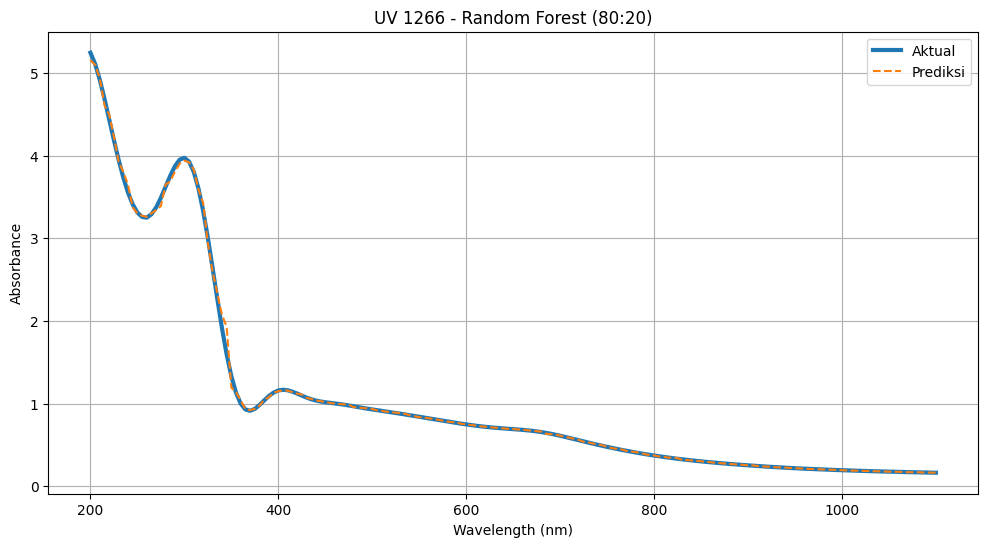


HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1266,80:20,Linear Regression,0.669266,0.668227
1,UV 1266,80:20,Polynomial Regression,0.854393,0.443380
2,UV 1266,80:20,Random Forest,0.996787,0.065862



Model terbaik : Random Forest


SAMPEL : UV 1266
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,480,0.9685
1,685,0.6471
2,800,0.3727
3,915,0.2424
4,350,1.332
...,...,...
157,730,0.5294
158,270,3.3737
159,660,0.6833
160,1095,0.1661



TEST DATA


,Wavelength,Absorbance
0,295,3.9506
1,410,1.162
2,965,0.2112
3,590,0.7658
4,925,0.2352
5,275,3.4888
6,320,3.3315
7,540,0.8603
8,765,0.442
9,790,0.3906



Residu Linear Regression


,Wavelength,Aktual,Prediksi,Residu
0,275,3.4888,2.438231,1.050569
1,280,3.6221,2.420018,1.202082
2,295,3.9506,2.365379,1.585221
3,320,3.3315,2.274313,1.057187
4,410,1.162,1.946478,-0.784478
5,425,1.0972,1.891838,-0.794638
6,455,1.0103,1.782560,-0.77226
7,540,0.8603,1.472937,-0.612637
8,545,0.8509,1.454724,-0.603824
9,590,0.7658,1.290806,-0.525006


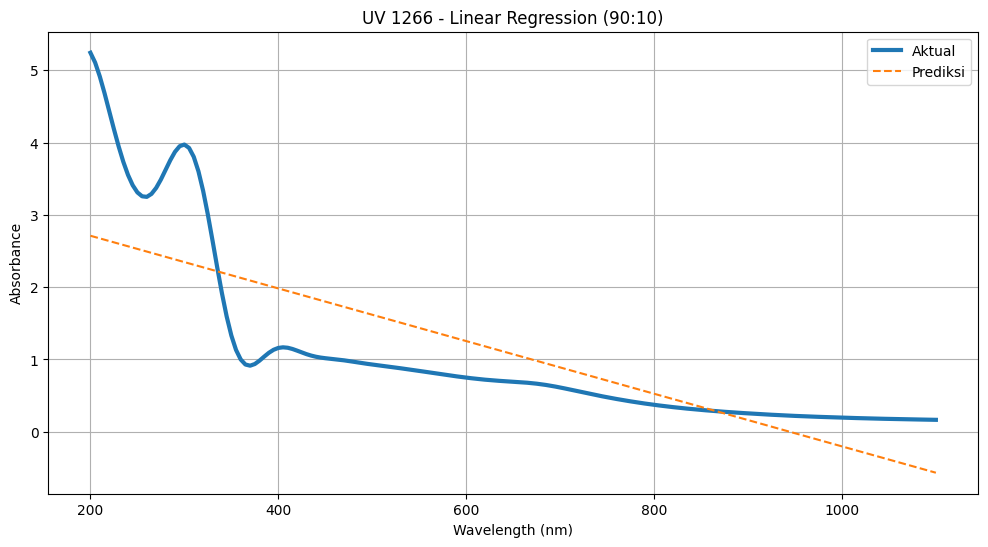


Residu Polynomial Regression


,Wavelength,Aktual,Prediksi,Residu
0,275,3.4888,3.099913,0.388887
1,280,3.6221,3.047706,0.574394
2,295,3.9506,2.893807,1.056793
3,320,3.3315,2.646379,0.685121
4,410,1.162,1.849520,-0.68752
5,425,1.0972,1.730997,-0.633797
6,455,1.0103,1.506196,-0.495896
7,540,0.8603,0.957927,-0.097627
8,545,0.8509,0.929758,-0.078858
9,590,0.7658,0.696643,0.069157


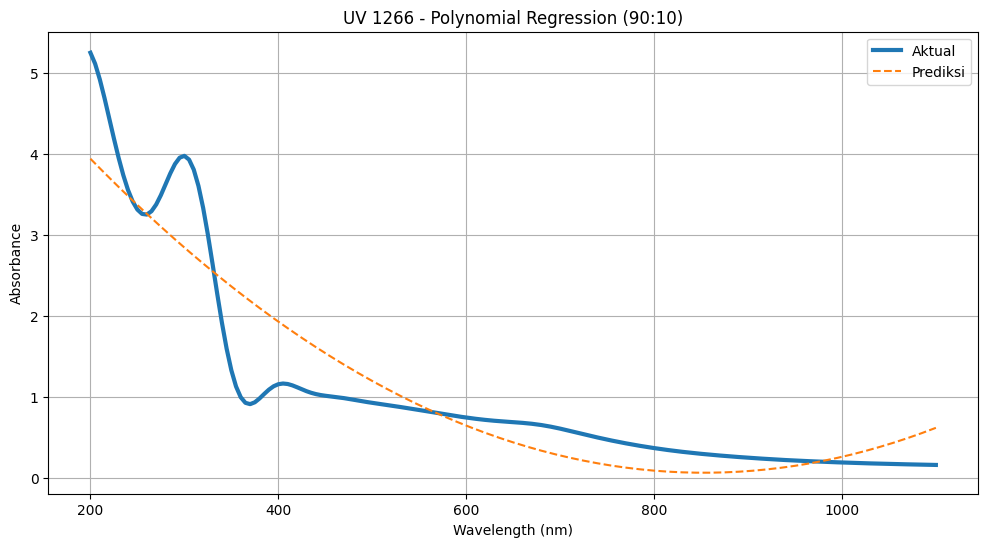


Residu Random Forest


,Wavelength,Aktual,Prediksi,Residu
0,275,3.4888,3.356832,0.131968
1,280,3.6221,3.663620,-0.04152
2,295,3.9506,3.878368,0.072232
3,320,3.3315,3.431858,-0.100358
4,410,1.162,1.160609,0.001391
5,425,1.0972,1.110055,-0.012855
6,455,1.0103,1.016233,-0.005933
7,540,0.8603,0.864989,-0.004689
8,545,0.8509,0.850249,0.000651
9,590,0.7658,0.761417,0.004383


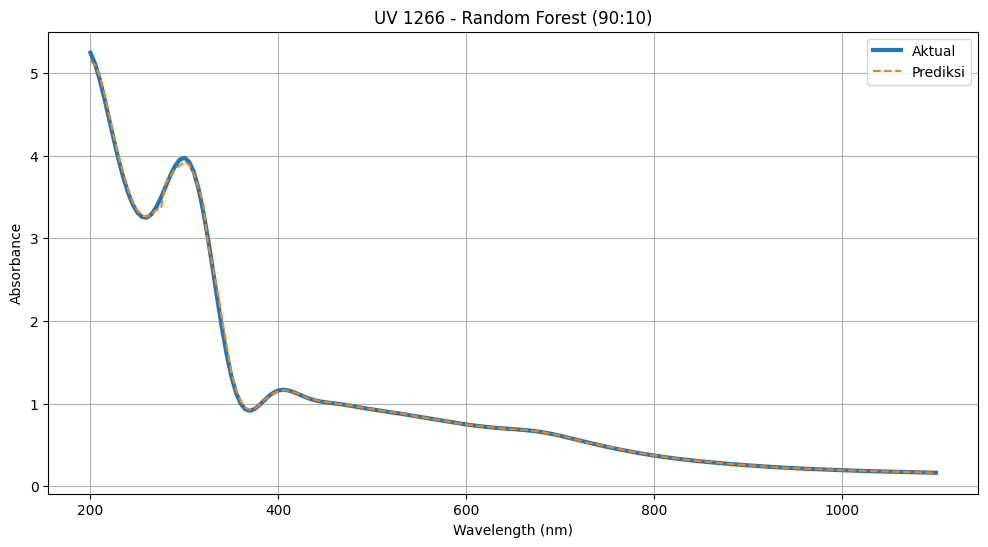


HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1266,90:10,Linear Regression,0.680302,0.710859
1,UV 1266,90:10,Polynomial Regression,0.877780,0.439526
2,UV 1266,90:10,Random Forest,0.998843,0.042772



Model terbaik : Random Forest


In [14]:
hasil_s1 = []

scenario1_samples = [

    'UV 1264',
    'UV 1265',
    'UV 1266'

]

for sample in scenario1_samples:

    data = sample_data[sample]

    for ts in split_list:

        hasil, best_model, best_pred = run_sample(
            sample_name=sample,
            transformed_data=data,
            test_size=ts,
            show_plot=True
        )

        hasil.insert(
            0,
            "Scenario",
            "Scenario 1"
        )

        hasil_s1.append(
            hasil
        )
        
best_prediction_s1 = {}

best_prediction_s1[sample] = {

    'model': best_model,

    'prediction': best_pred

}

In [15]:
hasil_s1_df = pd.concat(

    hasil_s1,

    ignore_index=True

)

print(
    "\nHASIL SKENARIO 1"
)

display(
    hasil_s1_df
)


HASIL SKENARIO 1


,Scenario,Sample,Split,Model,R2,RMSE
0,Scenario 1,UV 1264,60:40,Linear Regression,0.596734,0.521653
1,Scenario 1,UV 1264,60:40,Polynomial Regression,0.754241,0.407231
2,Scenario 1,UV 1264,60:40,Random Forest,0.995025,0.057941
3,Scenario 1,UV 1264,70:30,Linear Regression,0.606055,0.526247
4,Scenario 1,UV 1264,70:30,Polynomial Regression,0.796119,0.378583
5,Scenario 1,UV 1264,70:30,Random Forest,0.996370,0.050512
6,Scenario 1,UV 1264,80:20,Linear Regression,0.644148,0.455123
7,Scenario 1,UV 1264,80:20,Polynomial Regression,0.791625,0.348271
8,Scenario 1,UV 1264,80:20,Random Forest,0.996429,0.045590
9,Scenario 1,UV 1264,90:10,Linear Regression,0.686715,0.452037


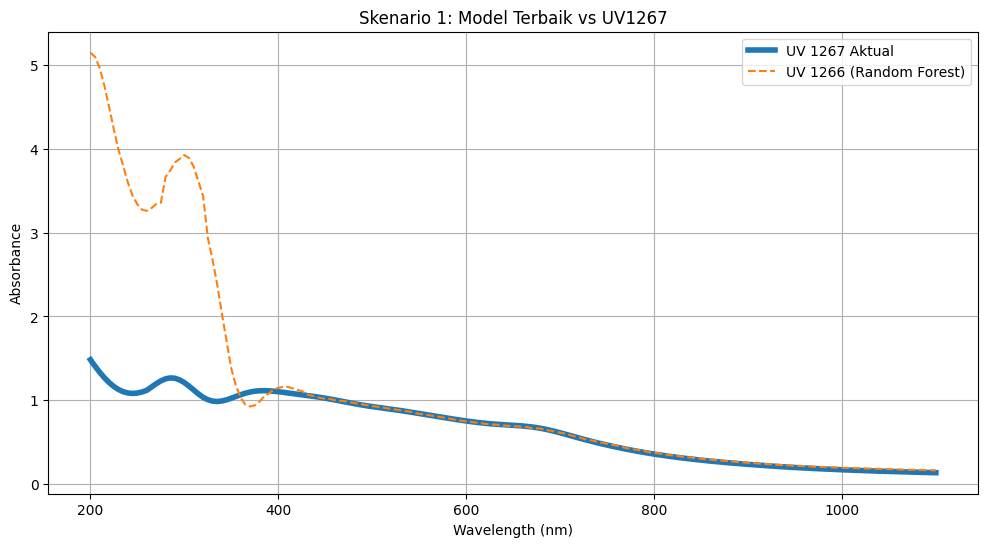

In [16]:
uv1267 = sample_data[
    'UV 1267'
]['Absorbance'].values

plt.figure(figsize=(12,6))

plt.plot(
    wavelength,
    uv1267,
    linewidth=4,
    label='UV 1267 Aktual'
)

for sample in best_prediction_s1:

    pred = best_prediction_s1[
        sample
    ]['prediction']

    model = best_prediction_s1[
        sample
    ]['model']

    plt.plot(
        wavelength,
        pred,
        '--',
        label=f'{sample} ({model})'
    )

plt.xlabel('Wavelength (nm)')
plt.ylabel('Absorbance')

plt.title(
    'Skenario 1: Model Terbaik vs UV1267'
)

plt.legend()
plt.grid(True)
plt.show()

In [17]:
comparison_s1 = []

for sample in best_prediction_s1:

    pred = best_prediction_s1[
        sample
    ]['prediction']

    rmse = np.sqrt(

        mean_squared_error(

            uv1267,

            pred

        )

    )

    comparison_s1.append([

        sample,

        best_prediction_s1[
            sample
        ]['model'],

        rmse

    ])

comparison_s1 = pd.DataFrame(

    comparison_s1,

    columns=[

        'Sample',

        'Best Model',

        'RMSE vs UV1267'

    ]

)

display(
    comparison_s1.sort_values(
        'RMSE vs UV1267'
    )
)

,Sample,Best Model,RMSE vs UV1267
0,UV 1266,Random Forest,1.044466


## Skenario 2
Train:
UV 1264, 1265, 1266, 1267
Test:
UV 1268



SAMPEL : UV 1264
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,760,0.4573
1,220,3.6904
2,360,1.0427
3,705,0.5584
4,840,0.3606
...,...,...
103,730,0.5099
104,270,2.7046
105,660,0.6311
106,1095,0.2681



TEST DATA


,Wavelength,Absorbance
0,295,2.5257
1,410,1.1009
2,965,0.2942
3,590,0.7313
4,925,0.3086
...,...,...
68,575,0.7594
69,930,0.3065
70,255,2.4765
71,230,3.1441



Residu Linear Regression


,Wavelength,Aktual,Prediksi,Residu
0,210,4.3077,2.135262,2.172438
1,230,3.1441,2.080442,1.063658
2,245,2.6087,2.039326,0.569374
3,255,2.4765,2.011916,0.464584
4,260,2.4723,1.998211,0.474089
...,...,...,...,...
68,1045,0.2763,-0.153498,0.429798
69,1055,0.2748,-0.180908,0.455708
70,1060,0.2741,-0.194613,0.468713
71,1065,0.2733,-0.208319,0.481619


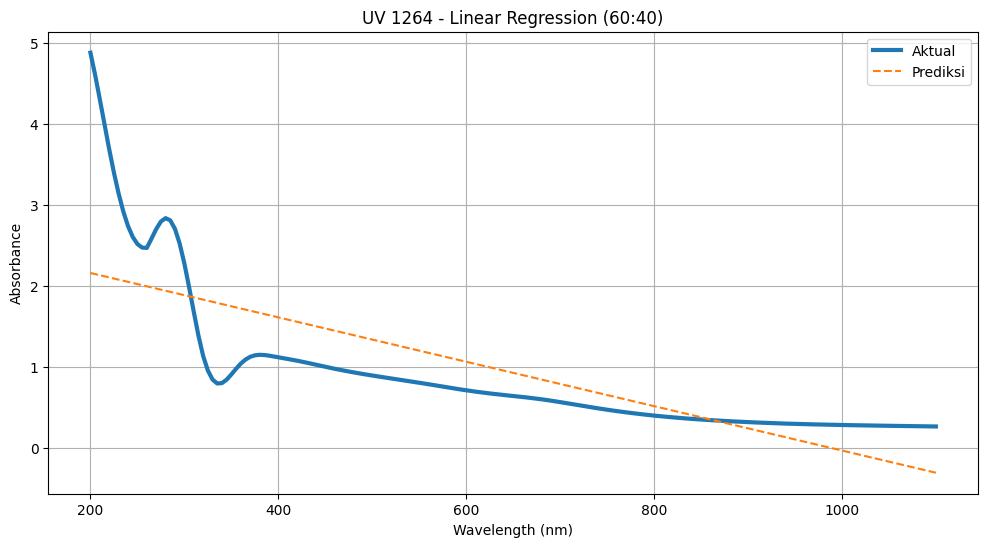


Residu Polynomial Regression


,Wavelength,Aktual,Prediksi,Residu
0,210,4.3077,3.033462,1.274238
1,230,3.1441,2.857663,0.286437
2,245,2.6087,2.729480,-0.12078
3,255,2.4765,2.645772,-0.169272
4,260,2.4723,2.604441,-0.132141
...,...,...,...,...
68,1045,0.2763,0.447407,-0.171107
69,1055,0.2748,0.475461,-0.200661
70,1060,0.2741,0.490012,-0.215912
71,1065,0.2733,0.504912,-0.231612


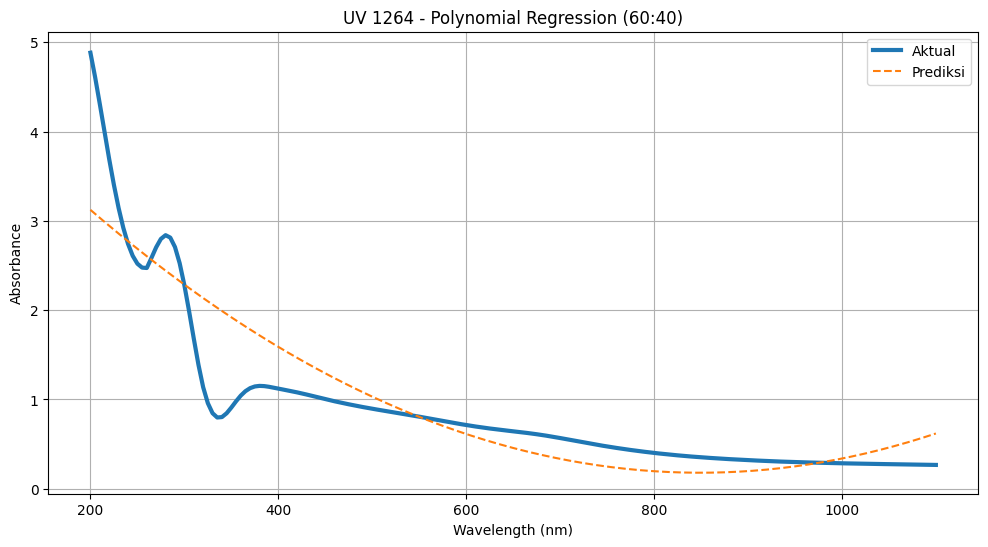


Residu Random Forest


,Wavelength,Aktual,Prediksi,Residu
0,210,4.3077,4.150860,0.15684
1,230,3.1441,3.235408,-0.091308
2,245,2.6087,2.618651,-0.009951
3,255,2.4765,2.576159,-0.099659
4,260,2.4723,2.601311,-0.129011
...,...,...,...,...
68,1045,0.2763,0.276783,-0.000483
69,1055,0.2748,0.275559,-0.000759
70,1060,0.2741,0.274571,-0.000471
71,1065,0.2733,0.272960,0.00034


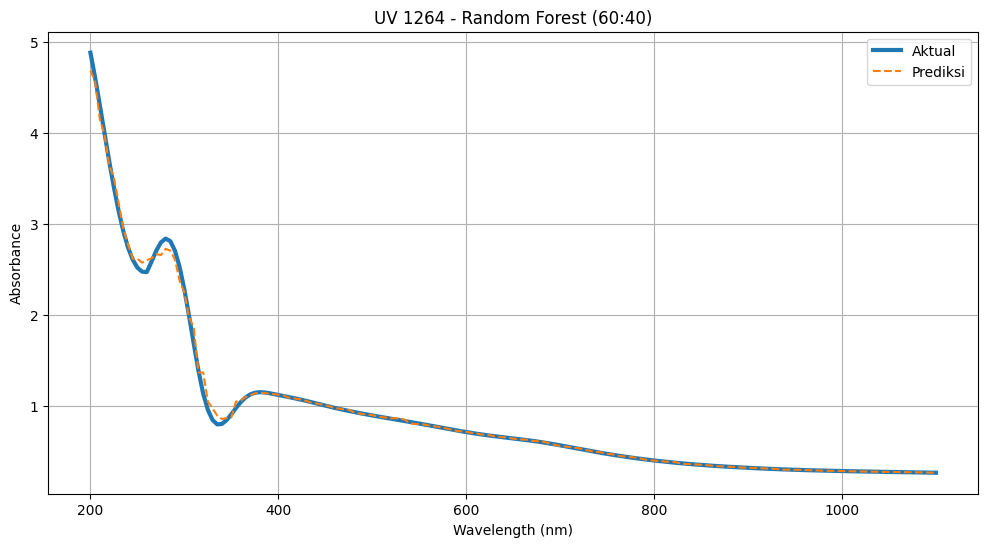


HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1264,60:40,Linear Regression,0.596734,0.521653
1,UV 1264,60:40,Polynomial Regression,0.754241,0.407231
2,UV 1264,60:40,Random Forest,0.995025,0.057941



Model terbaik : Random Forest


SAMPEL : UV 1264
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,625,0.675
1,960,0.2957
2,610,0.6972
3,935,0.3044
4,330,0.8463
...,...,...
121,730,0.5099
122,270,2.7046
123,660,0.6311
124,1095,0.2681



TEST DATA


,Wavelength,Absorbance
0,295,2.5257
1,410,1.1009
2,965,0.2942
3,590,0.7313
4,925,0.3086
5,275,2.7978
6,320,1.1376
7,540,0.8257
8,765,0.4494
9,790,0.4139



Residu Linear Regression


,Wavelength,Aktual,Prediksi,Residu
0,210,4.3077,2.088663,2.219037
1,245,2.6087,1.995159,0.613541
2,260,2.4723,1.955086,0.517214
3,275,2.7978,1.915012,0.882788
4,280,2.8399,1.901655,0.938245
5,290,2.7072,1.874939,0.832261
6,295,2.5257,1.861582,0.664118
7,320,1.1376,1.794793,-0.657193
8,345,0.8455,1.728005,-0.882505
9,350,0.9094,1.714647,-0.805247


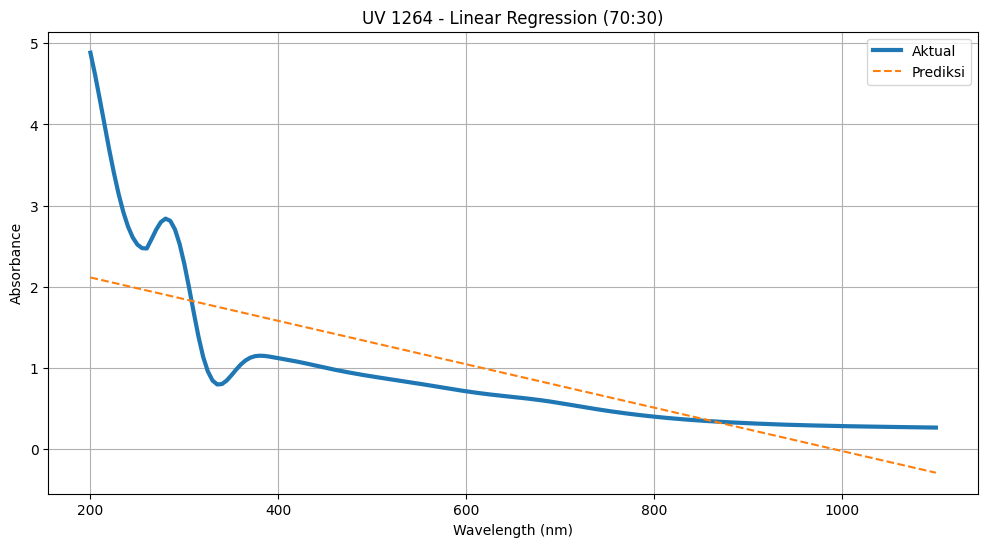


Residu Polynomial Regression


,Wavelength,Aktual,Prediksi,Residu
0,210,4.3077,2.917840,1.38986
1,245,2.6087,2.628034,-0.019334
2,260,2.4723,2.508824,-0.036524
3,275,2.7978,2.392611,0.405189
4,280,2.8399,2.354538,0.485362
5,290,2.7072,2.279393,0.427807
6,295,2.5257,2.242319,0.283381
7,320,1.1376,2.061944,-0.924344
8,345,0.8455,1.889891,-1.044391
9,350,0.9094,1.856479,-0.947079


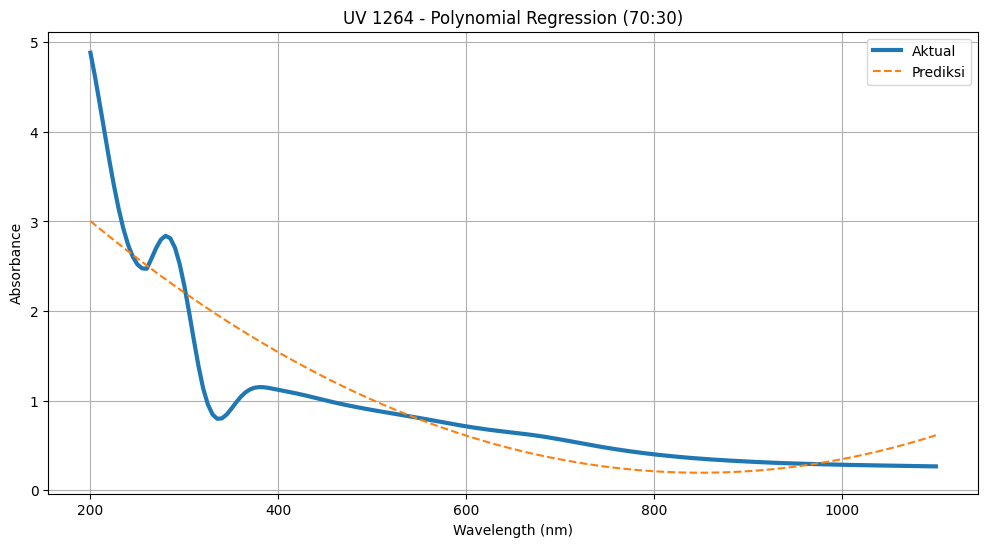


Residu Random Forest


,Wavelength,Aktual,Prediksi,Residu
0,210,4.3077,4.474426,-0.166726
1,245,2.6087,2.584963,0.023737
2,260,2.4723,2.522037,-0.049737
3,275,2.7978,2.672178,0.125622
4,280,2.8399,2.737968,0.101932
5,290,2.7072,2.574224,0.132976
6,295,2.5257,2.337813,0.187887
7,320,1.1376,1.282452,-0.144852
8,345,0.8455,0.816370,0.02913
9,350,0.9094,0.870560,0.03884


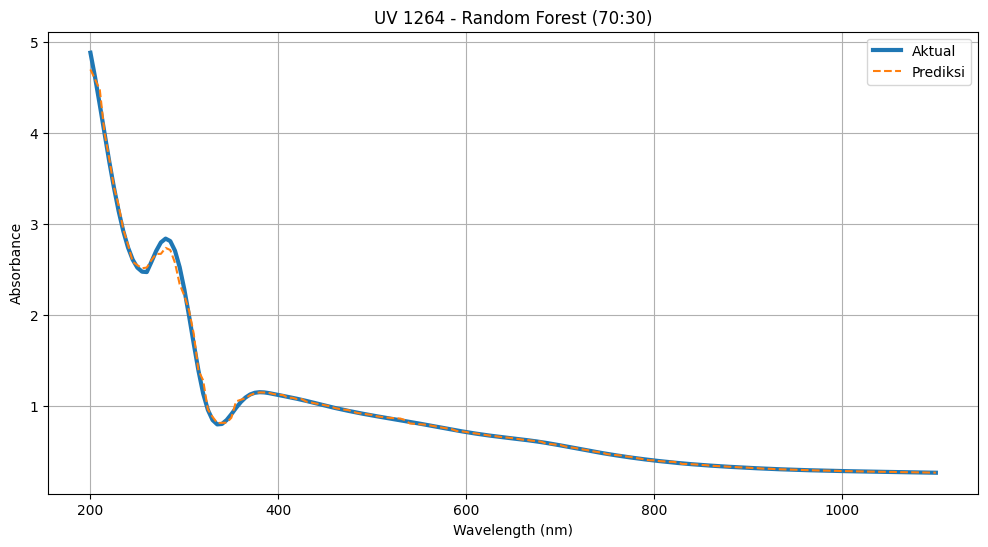


HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1264,70:30,Linear Regression,0.606055,0.526247
1,UV 1264,70:30,Polynomial Regression,0.796119,0.378583
2,UV 1264,70:30,Random Forest,0.996370,0.050512



Model terbaik : Random Forest


SAMPEL : UV 1264
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,525,0.8523
1,535,0.8347
2,355,0.9791
3,260,2.4723
4,405,1.1112
...,...,...
139,730,0.5099
140,270,2.7046
141,660,0.6311
142,1095,0.2681



TEST DATA


,Wavelength,Absorbance
0,295,2.5257
1,410,1.1009
2,965,0.2942
3,590,0.7313
4,925,0.3086
5,275,2.7978
6,320,1.1376
7,540,0.8257
8,765,0.4494
9,790,0.4139



Residu Linear Regression


,Wavelength,Aktual,Prediksi,Residu
0,245,2.6087,1.995716,0.612984
1,275,2.7978,1.916089,0.881711
2,280,2.8399,1.902818,0.937082
3,290,2.7072,1.876276,0.830924
4,295,2.5257,1.863005,0.662695
5,320,1.1376,1.796650,-0.65905
6,345,0.8455,1.730295,-0.884795
7,350,0.9094,1.717024,-0.807624
8,410,1.1009,1.557772,-0.456872
9,425,1.0678,1.517959,-0.450159


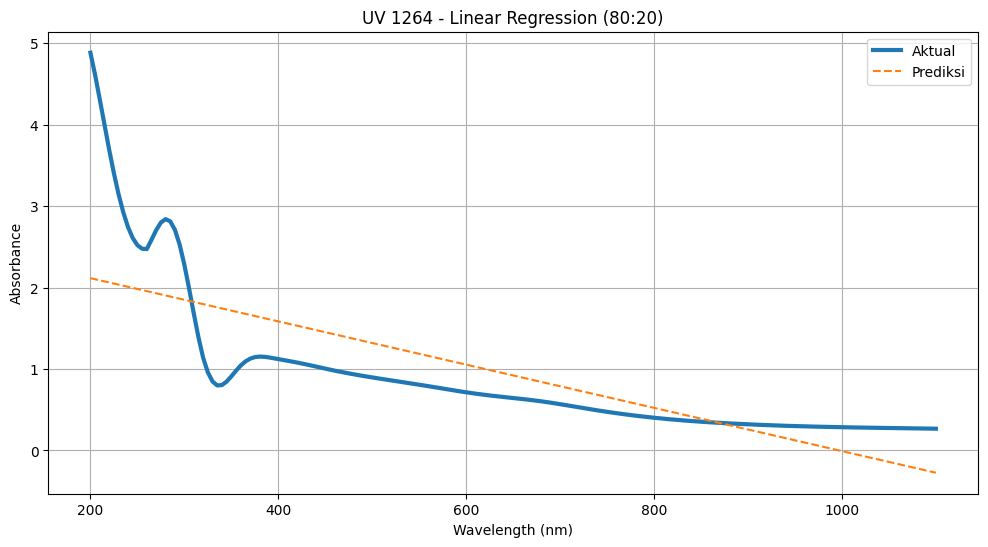


Residu Polynomial Regression


,Wavelength,Aktual,Prediksi,Residu
0,245,2.6087,2.643155,-0.034455
1,275,2.7978,2.404912,0.392888
2,280,2.8399,2.366385,0.473515
3,290,2.7072,2.290343,0.416857
4,295,2.5257,2.252827,0.272873
5,320,1.1376,2.070309,-0.932709
6,345,0.8455,1.896222,-1.050722
7,350,0.9094,1.862416,-0.953016
8,410,1.1009,1.483048,-0.382148
9,425,1.0678,1.395794,-0.327994


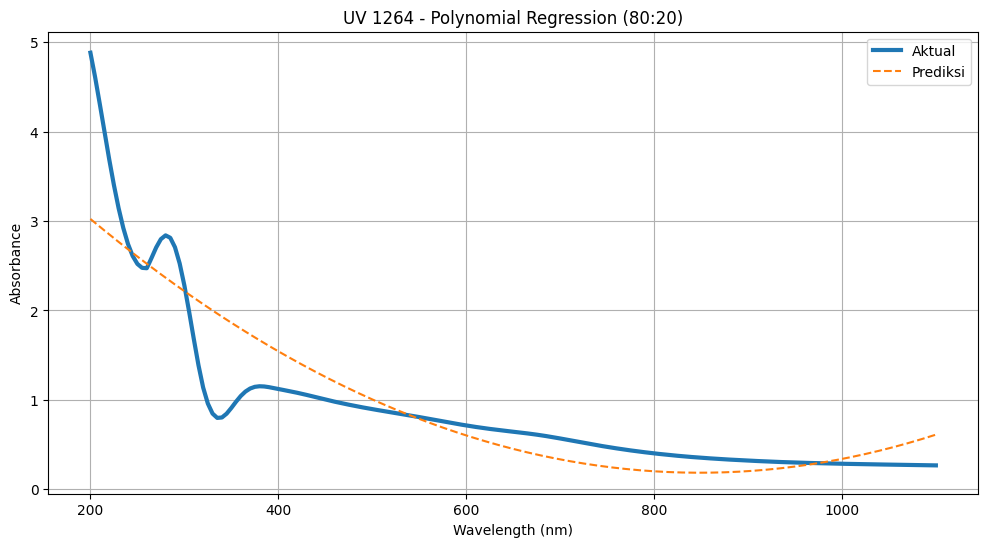


Residu Random Forest


,Wavelength,Aktual,Prediksi,Residu
0,245,2.6087,2.579916,0.028784
1,275,2.7978,2.673433,0.124367
2,280,2.8399,2.759800,0.0801
3,290,2.7072,2.630179,0.077021
4,295,2.5257,2.388003,0.137697
5,320,1.1376,1.290664,-0.153064
6,345,0.8455,0.820263,0.025237
7,350,0.9094,0.976782,-0.067382
8,410,1.1009,1.104999,-0.004099
9,425,1.0678,1.073675,-0.005875


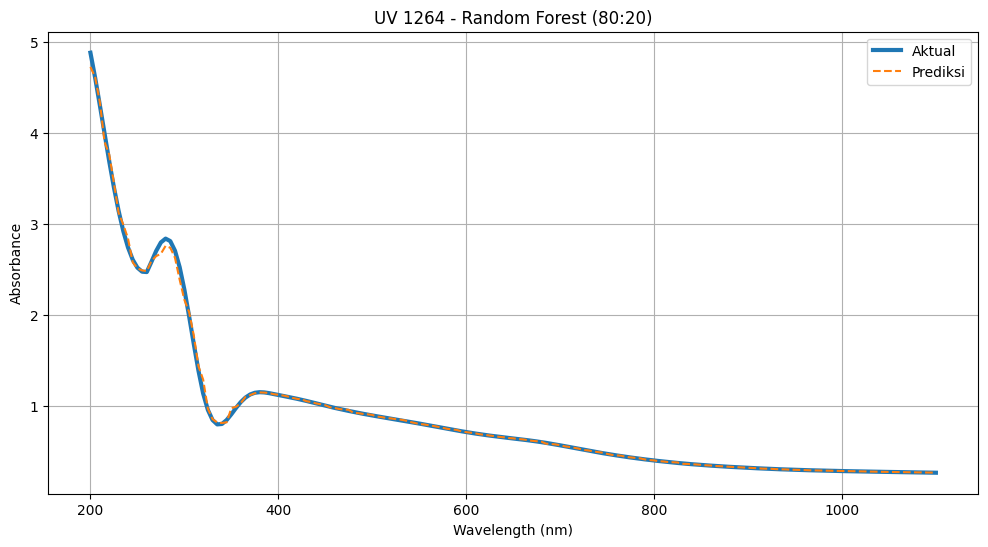


HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1264,80:20,Linear Regression,0.644148,0.455123
1,UV 1264,80:20,Polynomial Regression,0.791625,0.348271
2,UV 1264,80:20,Random Forest,0.996429,0.045590



Model terbaik : Random Forest


SAMPEL : UV 1264
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,480,0.9353
1,685,0.5949
2,800,0.4014
3,915,0.3132
4,350,0.9094
...,...,...
157,730,0.5099
158,270,2.7046
159,660,0.6311
160,1095,0.2681



TEST DATA


,Wavelength,Absorbance
0,295,2.5257
1,410,1.1009
2,965,0.2942
3,590,0.7313
4,925,0.3086
5,275,2.7978
6,320,1.1376
7,540,0.8257
8,765,0.4494
9,790,0.4139



Residu Linear Regression


,Wavelength,Aktual,Prediksi,Residu
0,275,2.7978,1.886243,0.911557
1,280,2.8399,1.873244,0.966656
2,295,2.5257,1.834247,0.691453
3,320,1.1376,1.769252,-0.631652
4,410,1.1009,1.535270,-0.43437
5,425,1.0678,1.496272,-0.428472
6,455,0.9913,1.418278,-0.426978
7,540,0.8257,1.197295,-0.371595
8,545,0.8166,1.184296,-0.367696
9,590,0.7313,1.067305,-0.336005


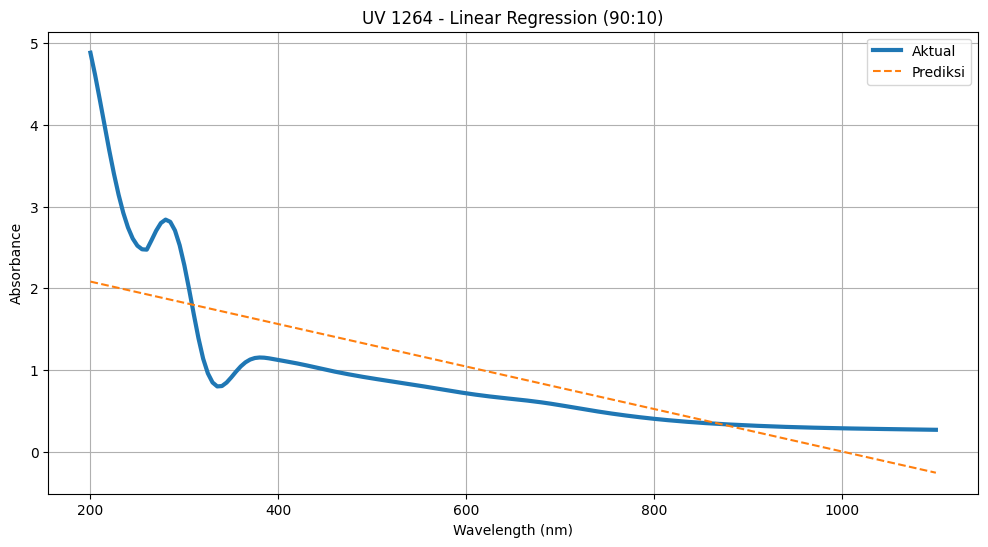


Residu Polynomial Regression


,Wavelength,Aktual,Prediksi,Residu
0,275,2.7978,2.366018,0.431782
1,280,2.8399,2.328371,0.511529
2,295,2.5257,2.217402,0.308298
3,320,1.1376,2.039030,-0.90143
4,410,1.1009,1.464967,-0.364067
5,425,1.0678,1.379649,-0.311849
6,455,0.9913,1.217891,-0.226591
7,540,0.8257,0.823869,0.001831
8,545,0.8166,0.803651,0.012949
9,590,0.7313,0.636487,0.094813


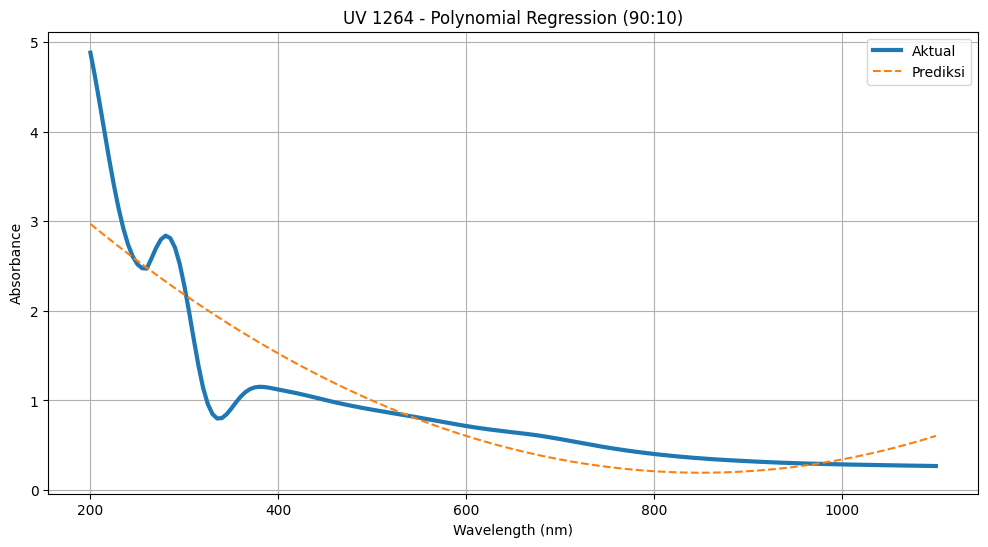


Residu Random Forest


,Wavelength,Aktual,Prediksi,Residu
0,275,2.7978,2.654676,0.143124
1,280,2.8399,2.756945,0.082955
2,295,2.5257,2.548711,-0.023011
3,320,1.1376,1.291877,-0.154277
4,410,1.1009,1.106168,-0.005268
5,425,1.0678,1.073467,-0.005667
6,455,0.9913,1.001041,-0.009741
7,540,0.8257,0.830282,-0.004582
8,545,0.8166,0.815850,0.00075
9,590,0.7313,0.726712,0.004588


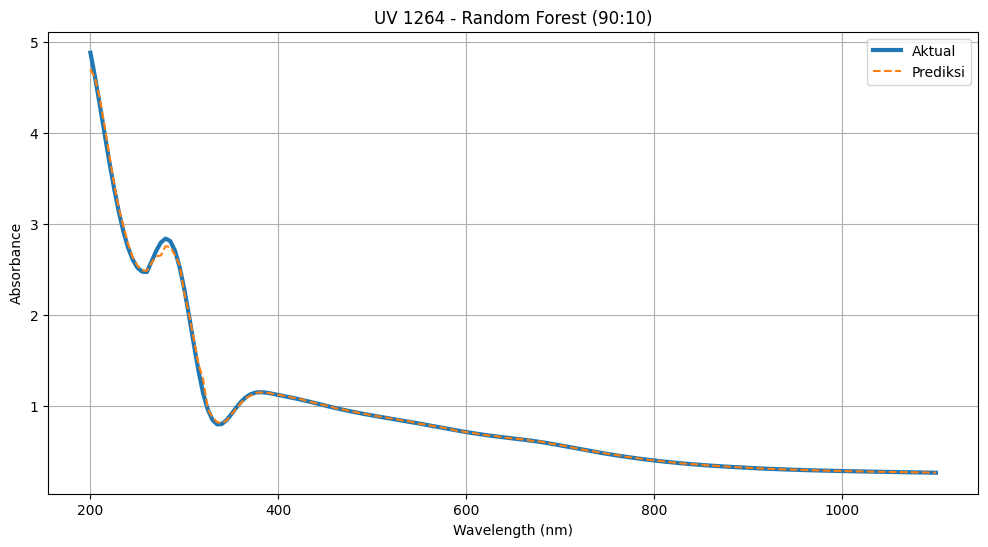


HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1264,90:10,Linear Regression,0.686715,0.452037
1,UV 1264,90:10,Polynomial Regression,0.849001,0.313828
2,UV 1264,90:10,Random Forest,0.995807,0.052293



Model terbaik : Random Forest


SAMPEL : UV 1265
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,760,0.4526
1,220,3.8294
2,360,0.9995
3,705,0.5985
4,840,0.3136
...,...,...
103,730,0.5288
104,270,0.8914
105,660,0.6832
106,1095,0.1657



TEST DATA


,Wavelength,Absorbance
0,295,1.9538
1,410,1.1399
2,965,0.2108
3,590,0.7662
4,925,0.2348
...,...,...
68,575,0.7937
69,930,0.2313
70,255,0.9102
71,230,2.6797



Residu Linear Regression


,Wavelength,Aktual,Prediksi,Residu
0,210,5.036,2.082287,2.953713
1,230,2.6797,2.027982,0.651718
2,245,1.376,1.987253,-0.611253
3,255,0.9102,1.960101,-1.049901
4,260,0.8102,1.946524,-1.136324
...,...,...,...,...
68,1045,0.1789,-0.184954,0.363854
69,1055,0.176,-0.212106,0.388106
70,1060,0.1747,-0.225683,0.400383
71,1065,0.1733,-0.239259,0.412559


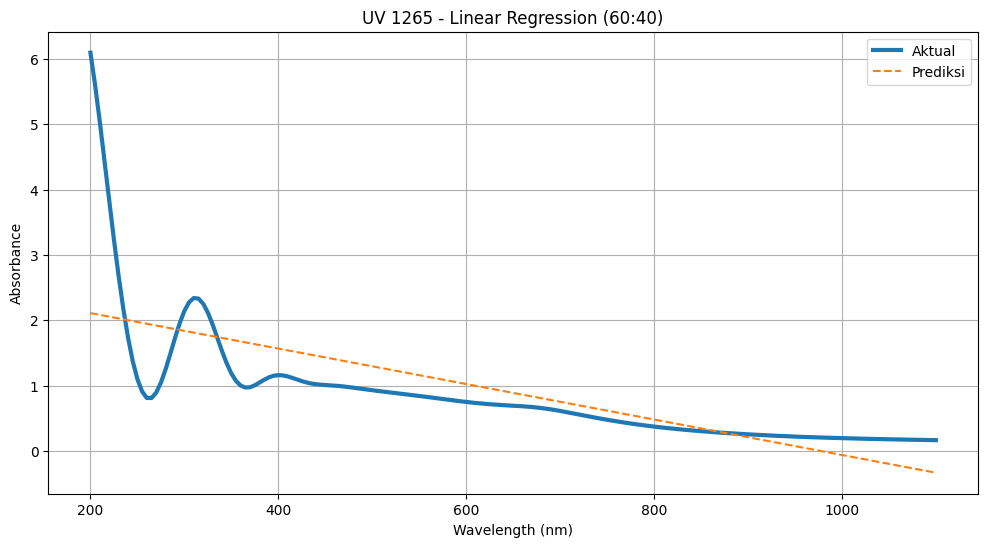


Residu Polynomial Regression


,Wavelength,Aktual,Prediksi,Residu
0,210,5.036,2.851712,2.184288
1,230,2.6797,2.693773,-0.014073
2,245,1.376,2.578460,-1.20246
3,255,0.9102,2.503081,-1.592881
4,260,0.8102,2.465840,-1.65564
...,...,...,...,...
68,1045,0.1789,0.329800,-0.1509
69,1055,0.176,0.350159,-0.174159
70,1060,0.1747,0.360788,-0.186088
71,1065,0.1733,0.371716,-0.198416


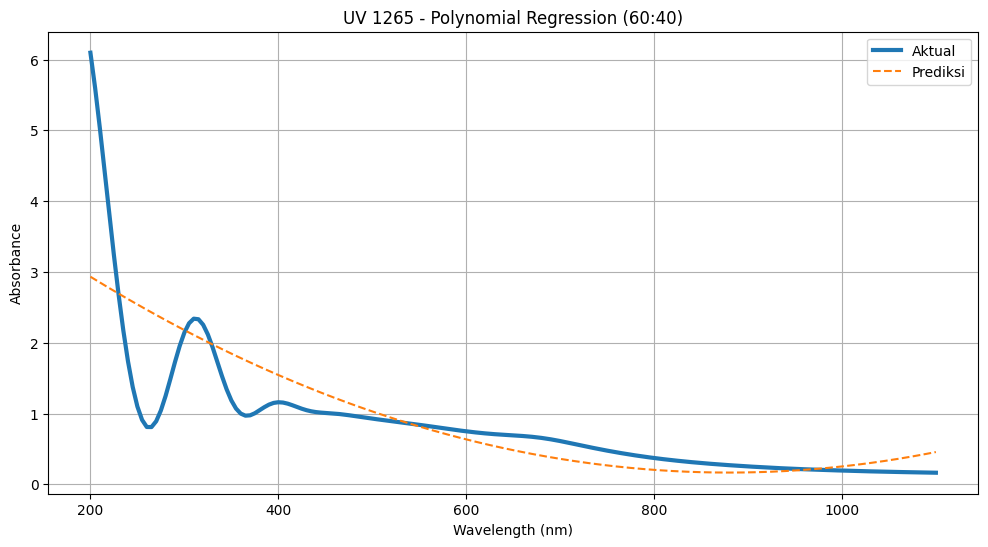


Residu Random Forest


,Wavelength,Aktual,Prediksi,Residu
0,210,5.036,4.727121,0.308879
1,230,2.6797,2.862499,-0.182799
2,245,1.376,1.359515,0.016485
3,255,0.9102,1.139212,-0.229012
4,260,0.8102,0.946942,-0.136742
...,...,...,...,...
68,1045,0.1789,0.179815,-0.000915
69,1055,0.176,0.177527,-0.001527
70,1060,0.1747,0.175703,-0.001003
71,1065,0.1733,0.172762,0.000538


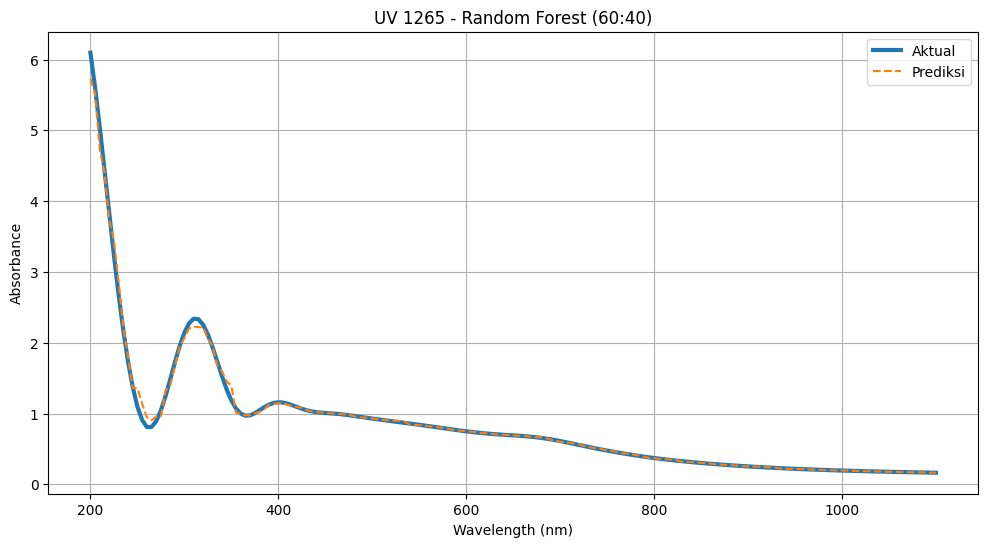


HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1265,60:40,Linear Regression,0.541387,0.506828
1,UV 1265,60:40,Polynomial Regression,0.550878,0.501556
2,UV 1265,60:40,Random Forest,0.992735,0.063791



Model terbaik : Random Forest


SAMPEL : UV 1265
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,625,0.7144
1,960,0.2133
2,610,0.7337
3,935,0.228
4,330,1.9379
...,...,...
121,730,0.5288
122,270,0.8914
123,660,0.6832
124,1095,0.1657



TEST DATA


,Wavelength,Absorbance
0,295,1.9538
1,410,1.1399
2,965,0.2108
3,590,0.7662
4,925,0.2348
5,275,1.0436
6,320,2.2541
7,540,0.8595
8,765,0.4412
9,790,0.39



Residu Linear Regression


,Wavelength,Aktual,Prediksi,Residu
0,210,5.036,2.055529,2.980471
1,245,1.376,1.962056,-0.586056
2,260,0.8102,1.921996,-1.111796
3,275,1.0436,1.881937,-0.838337
4,280,1.2481,1.868583,-0.620483
5,290,1.7269,1.841877,-0.114977
6,295,1.9538,1.828524,0.125276
7,320,2.2541,1.761757,0.492343
8,345,1.3422,1.694991,-0.352791
9,350,1.1858,1.681638,-0.495838


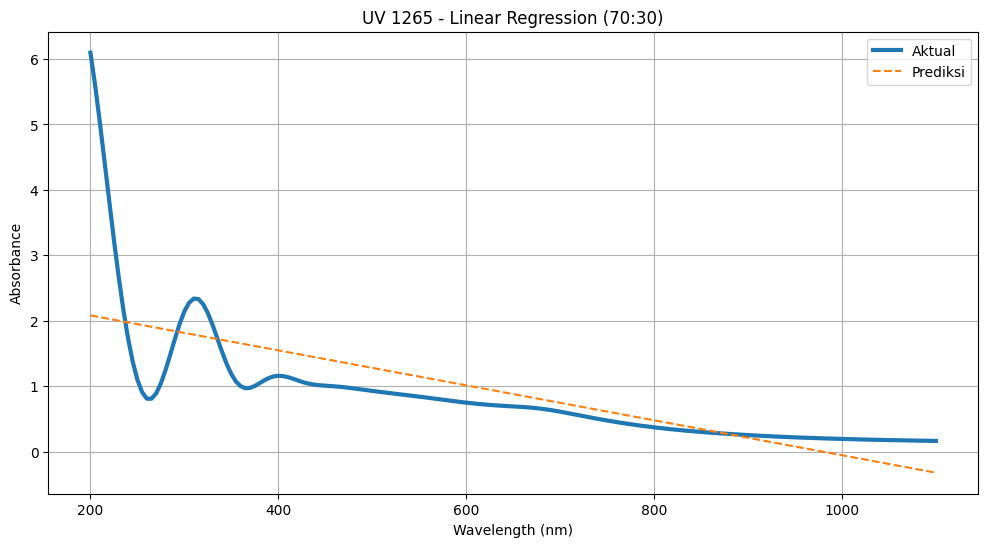


Residu Polynomial Regression


,Wavelength,Aktual,Prediksi,Residu
0,210,5.036,2.745672,2.290328
1,245,1.376,2.488812,-1.112812
2,260,0.8102,2.382886,-1.572686
3,275,1.0436,2.279452,-1.235852
4,280,1.2481,2.245529,-0.997429
5,290,1.7269,2.178512,-0.451612
6,295,1.9538,2.145420,-0.19162
7,320,2.2541,1.984113,0.269987
8,345,1.3422,1.829733,-0.487533
9,350,1.1858,1.799688,-0.613888


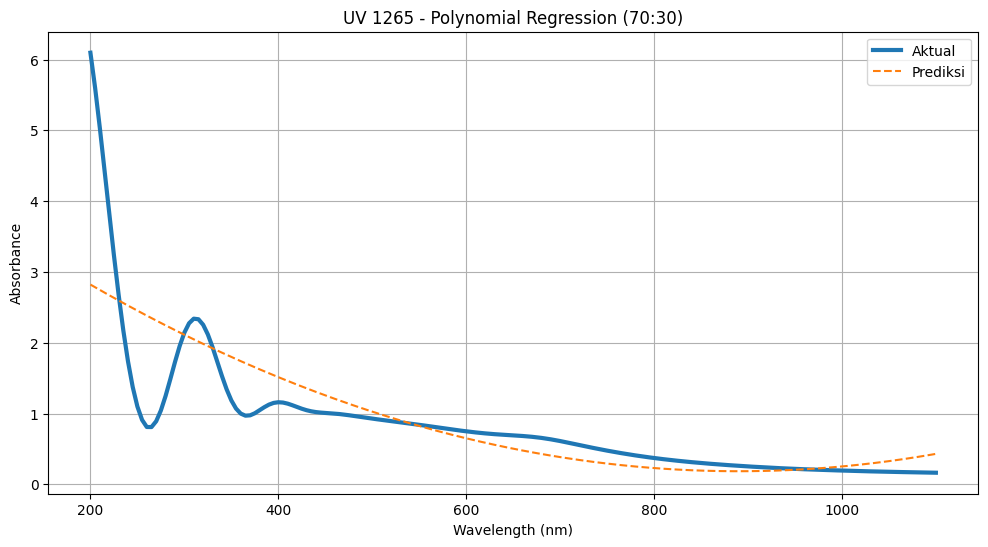


Residu Random Forest


,Wavelength,Aktual,Prediksi,Residu
0,210,5.036,5.340207,-0.304207
1,245,1.376,1.272292,0.103708
2,260,0.8102,0.953561,-0.143361
3,275,1.0436,0.965406,0.078194
4,280,1.2481,1.281571,-0.033471
5,290,1.7269,1.746030,-0.01913
6,295,1.9538,2.038481,-0.084681
7,320,2.2541,2.264456,-0.010356
8,345,1.3422,1.625160,-0.28296
9,350,1.1858,1.405760,-0.21996


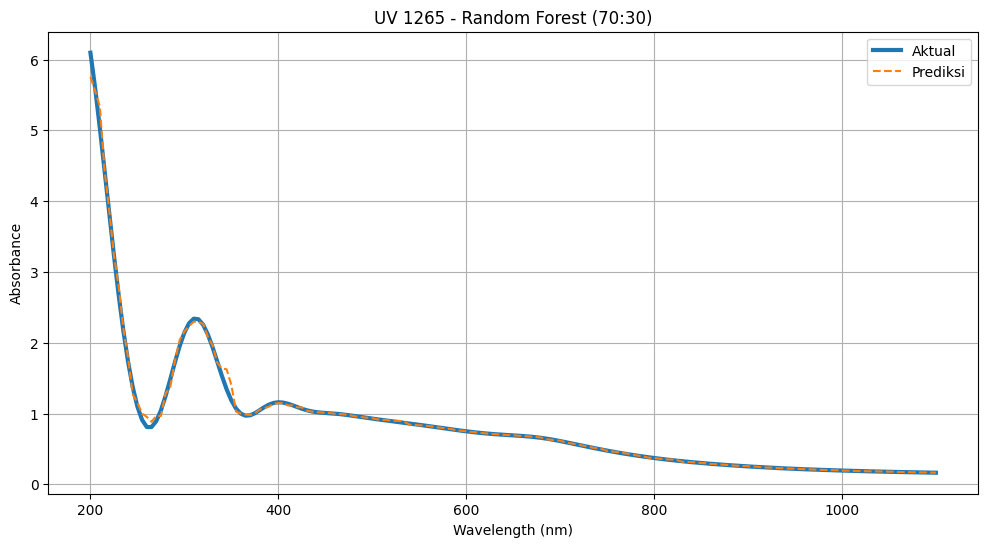


HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1265,70:30,Linear Regression,0.488901,0.535297
1,UV 1265,70:30,Polynomial Regression,0.538044,0.508912
2,UV 1265,70:30,Random Forest,0.991157,0.070413



Model terbaik : Random Forest


SAMPEL : UV 1265
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,525,0.8855
1,535,0.8683
2,355,1.0705
3,260,0.8102
4,405,1.1554
...,...,...
139,730,0.5288
140,270,0.8914
141,660,0.6832
142,1095,0.1657



TEST DATA


,Wavelength,Absorbance
0,295,1.9538
1,410,1.1399
2,965,0.2108
3,590,0.7662
4,925,0.2348
5,275,1.0436
6,320,2.2541
7,540,0.8595
8,765,0.4412
9,790,0.39



Residu Linear Regression


,Wavelength,Aktual,Prediksi,Residu
0,245,1.376,1.953963,-0.577963
1,275,1.0436,1.874663,-0.831063
2,280,1.2481,1.861447,-0.613347
3,290,1.7269,1.835014,-0.108114
4,295,1.9538,1.821797,0.132003
5,320,2.2541,1.755715,0.498385
6,345,1.3422,1.689632,-0.347432
7,350,1.1858,1.676416,-0.490616
8,410,1.1399,1.517817,-0.377917
9,425,1.0682,1.478168,-0.409968


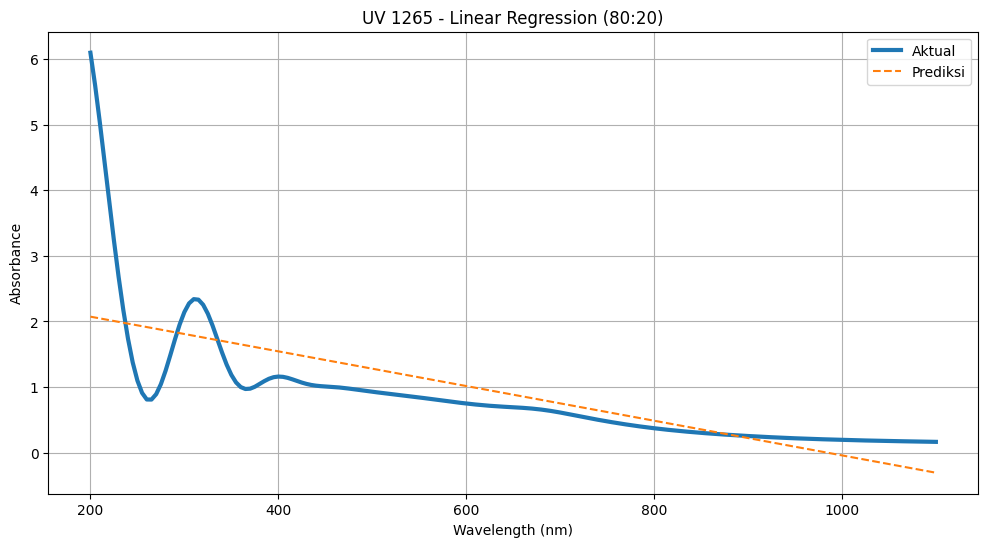


Residu Polynomial Regression


,Wavelength,Aktual,Prediksi,Residu
0,245,1.376,2.494984,-1.118984
1,275,1.0436,2.283139,-1.239539
2,280,1.2481,2.248818,-1.000718
3,290,1.7269,2.181021,-0.454121
4,295,1.9538,2.147546,-0.193746
5,320,2.2541,1.984393,0.269707
6,345,1.3422,1.828286,-0.486086
7,350,1.1858,1.797910,-0.61211
8,410,1.1399,1.455376,-0.315476
9,425,1.0682,1.376083,-0.307883


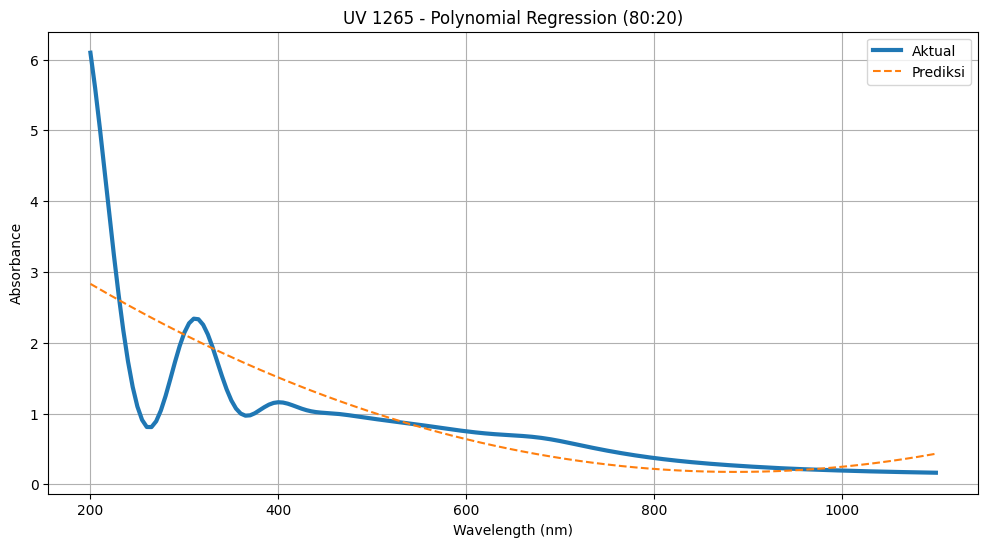


Residu Random Forest


,Wavelength,Aktual,Prediksi,Residu
0,245,1.376,1.259400,0.1166
1,275,1.0436,0.933428,0.110172
2,280,1.2481,1.328756,-0.080656
3,290,1.7269,1.675506,0.051394
4,295,1.9538,1.973238,-0.019438
5,320,2.2541,2.257070,-0.00297
6,345,1.3422,1.538745,-0.196545
7,350,1.1858,1.108902,0.076898
8,410,1.1399,1.141651,-0.001751
9,425,1.0682,1.082364,-0.014164


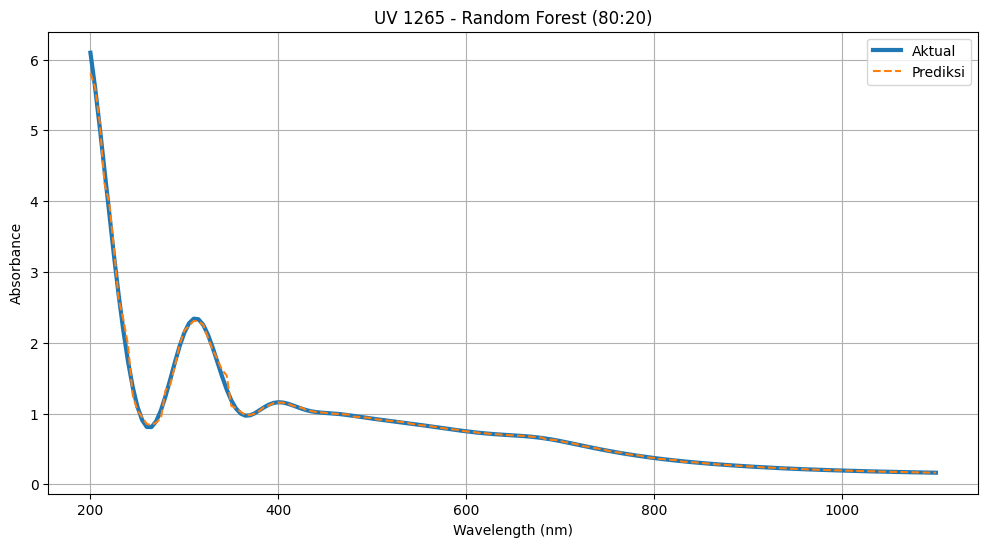


HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1265,80:20,Linear Regression,0.612800,0.322010
1,UV 1265,80:20,Polynomial Regression,0.449189,0.384064
2,UV 1265,80:20,Random Forest,0.991850,0.046716



Model terbaik : Random Forest


SAMPEL : UV 1265
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,480,0.967
1,685,0.6469
2,800,0.3721
3,915,0.242
4,350,1.1858
...,...,...
157,730,0.5288
158,270,0.8914
159,660,0.6832
160,1095,0.1657



TEST DATA


,Wavelength,Absorbance
0,295,1.9538
1,410,1.1399
2,965,0.2108
3,590,0.7662
4,925,0.2348
5,275,1.0436
6,320,2.2541
7,540,0.8595
8,765,0.4412
9,790,0.39



Residu Linear Regression


,Wavelength,Aktual,Prediksi,Residu
0,275,1.0436,1.823033,-0.779433
1,280,1.2481,1.810287,-0.562187
2,295,1.9538,1.772048,0.181752
3,320,2.2541,1.708317,0.545783
4,410,1.1399,1.478884,-0.338984
5,425,1.0682,1.440645,-0.372445
6,455,1.0043,1.364168,-0.359868
7,540,0.8595,1.147481,-0.287981
8,545,0.8505,1.134735,-0.284235
9,590,0.7662,1.020018,-0.253818


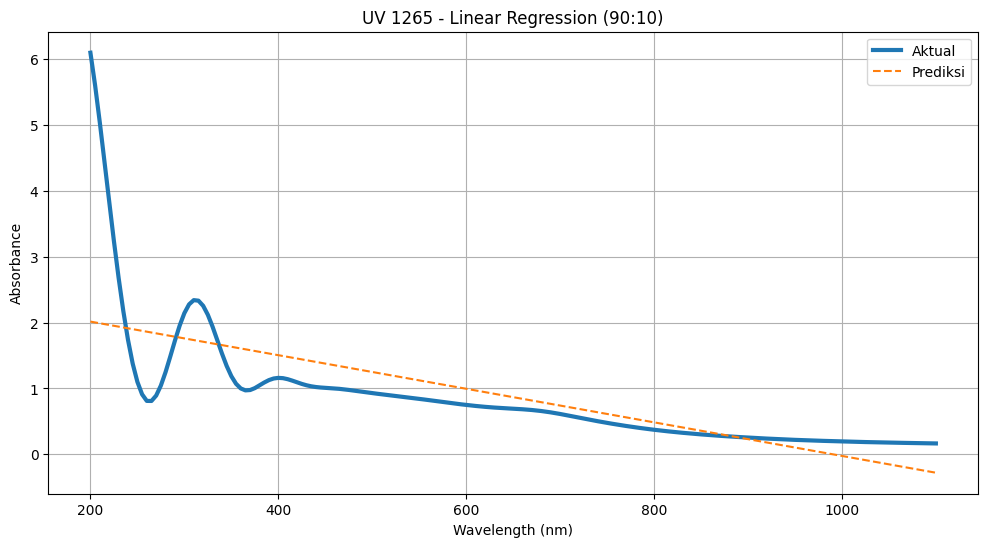


Residu Polynomial Regression


,Wavelength,Aktual,Prediksi,Residu
0,275,1.0436,2.207396,-1.163796
1,280,1.2481,2.174903,-0.926803
2,295,1.9538,2.079005,-0.125205
3,320,2.2541,1.924445,0.329655
4,410,1.1399,1.422563,-0.282663
5,425,1.0682,1.347214,-0.279014
6,455,1.0043,1.203631,-0.199331
7,540,0.8595,0.848318,0.011182
8,545,0.8505,0.829788,0.020712
9,590,0.7662,0.674876,0.091324


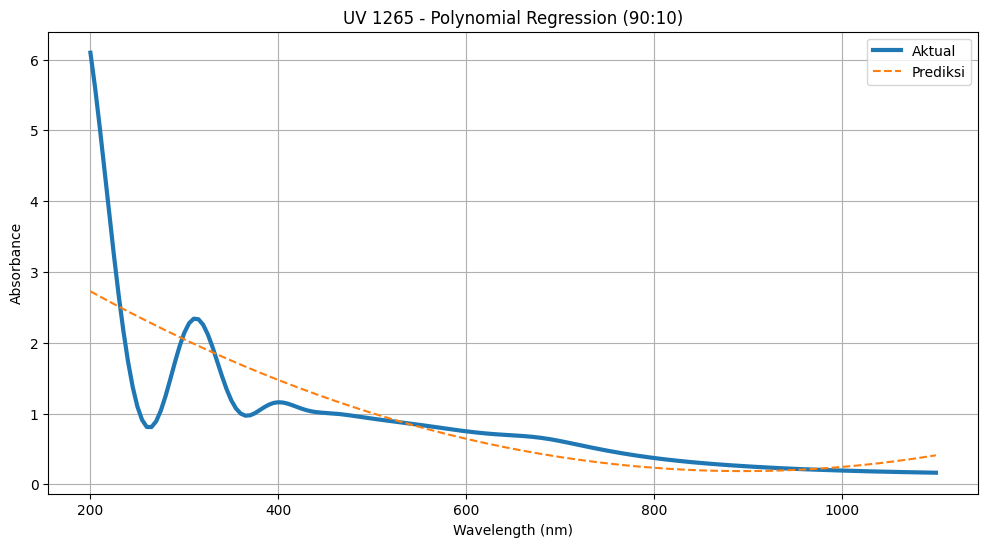


Residu Random Forest


,Wavelength,Aktual,Prediksi,Residu
0,275,1.0436,0.889238,0.154362
1,280,1.2481,1.354891,-0.106791
2,295,1.9538,1.834951,0.118849
3,320,2.2541,2.260193,-0.006093
4,410,1.1399,1.144935,-0.005035
5,425,1.0682,1.082046,-0.013846
6,455,1.0043,1.007770,-0.00347
7,540,0.8595,0.863942,-0.004442
8,545,0.8505,0.849726,0.000774
9,590,0.7662,0.761717,0.004483


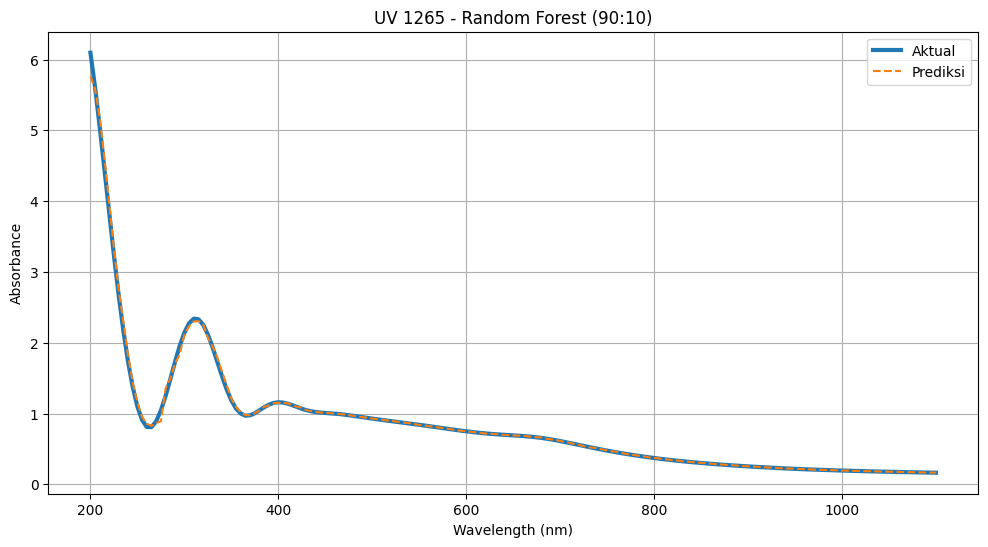


HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1265,90:10,Linear Regression,0.653368,0.325909
1,UV 1265,90:10,Polynomial Regression,0.534224,0.377791
2,UV 1265,90:10,Random Forest,0.991455,0.051171



Model terbaik : Random Forest


SAMPEL : UV 1266
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,760,0.4534
1,220,4.4369
2,360,0.9993
3,705,0.599
4,840,0.3139
...,...,...
103,730,0.5294
104,270,3.3737
105,660,0.6833
106,1095,0.1661



TEST DATA


,Wavelength,Absorbance
0,295,3.9506
1,410,1.162
2,965,0.2112
3,590,0.7658
4,925,0.2352
...,...,...
68,575,0.7934
69,930,0.2317
70,255,3.2576
71,230,3.9494



Residu Linear Regression


,Wavelength,Aktual,Prediksi,Residu
0,210,4.9146,2.703984,2.210616
1,230,3.9494,2.629750,1.31965
2,245,3.4102,2.574075,0.836125
3,255,3.2576,2.536958,0.720642
4,260,3.2495,2.518400,0.7311
...,...,...,...,...
68,1045,0.1791,-0.395271,0.574371
69,1055,0.1762,-0.432387,0.608587
70,1060,0.1748,-0.450946,0.625746
71,1065,0.1735,-0.469504,0.643004


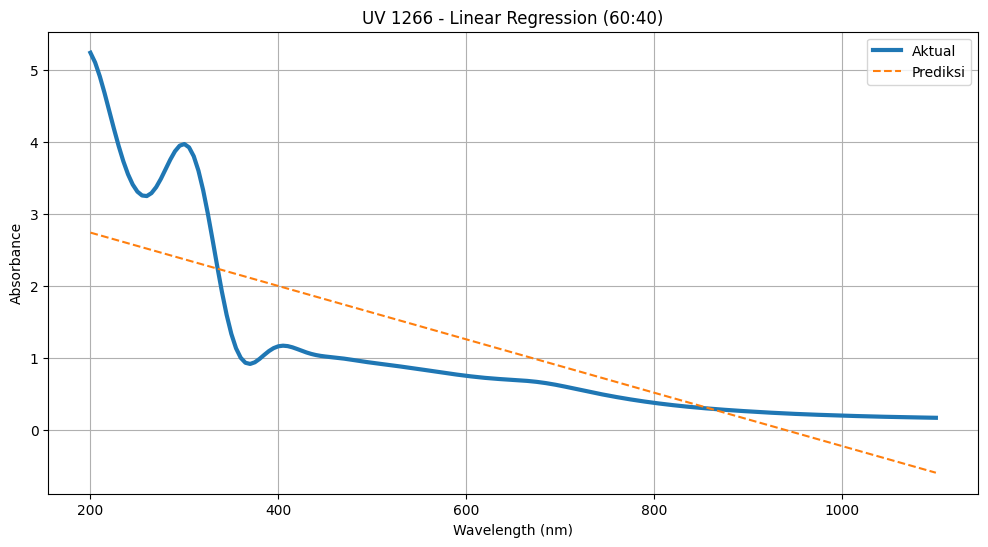


Residu Polynomial Regression


,Wavelength,Aktual,Prediksi,Residu
0,210,4.9146,3.902676,1.011924
1,230,3.9494,3.666990,0.28241
2,245,3.4102,3.495120,-0.08492
3,255,3.2576,3.382870,-0.12527
4,260,3.2495,3.327445,-0.077945
...,...,...,...,...
68,1045,0.1791,0.406667,-0.227567
69,1055,0.1762,0.443570,-0.26737
70,1060,0.1748,0.462721,-0.287921
71,1065,0.1735,0.482337,-0.308837


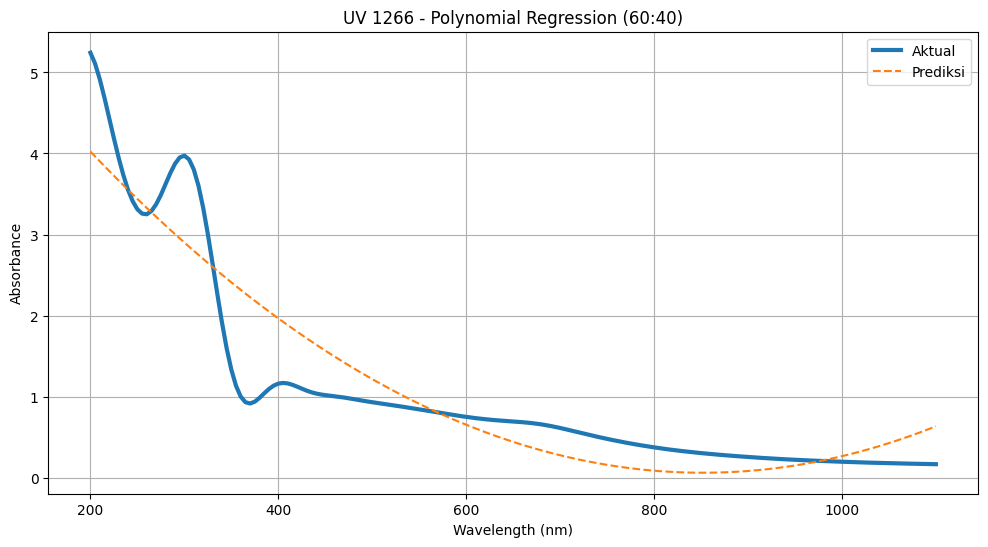


Residu Random Forest


,Wavelength,Aktual,Prediksi,Residu
0,210,4.9146,4.786310,0.12829
1,230,3.9494,4.027739,-0.078339
2,245,3.4102,3.413916,-0.003716
3,255,3.2576,3.348764,-0.091164
4,260,3.2495,3.325656,-0.076156
...,...,...,...,...
68,1045,0.1791,0.180085,-0.000985
69,1055,0.1762,0.177740,-0.00154
70,1060,0.1748,0.175874,-0.001074
71,1065,0.1735,0.172881,0.000619


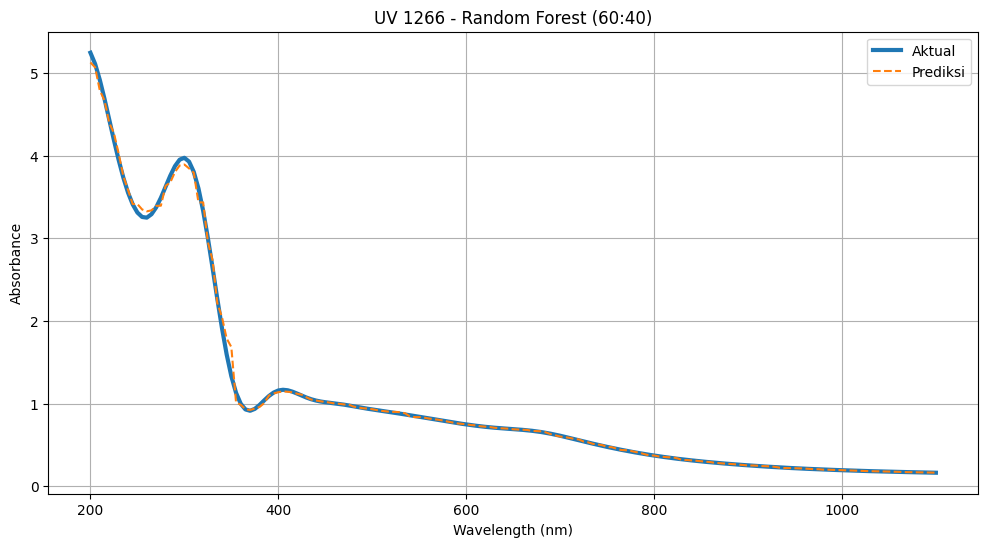


HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1266,60:40,Linear Regression,0.662691,0.695484
1,UV 1266,60:40,Polynomial Regression,0.853266,0.458711
2,UV 1266,60:40,Random Forest,0.997552,0.059248



Model terbaik : Random Forest


SAMPEL : UV 1266
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,625,0.7145
1,960,0.2137
2,610,0.7336
3,935,0.2284
4,330,2.6432
...,...,...
121,730,0.5294
122,270,3.3737
123,660,0.6833
124,1095,0.1661



TEST DATA


,Wavelength,Absorbance
0,295,3.9506
1,410,1.162
2,965,0.2112
3,590,0.7658
4,925,0.2352
5,275,3.4888
6,320,3.3315
7,540,0.8603
8,765,0.442
9,790,0.3906



Residu Linear Regression


,Wavelength,Aktual,Prediksi,Residu
0,210,4.9146,2.748457,2.166143
1,245,3.4102,2.616015,0.794185
2,260,3.2495,2.559254,0.690246
3,275,3.4888,2.502493,0.986307
4,280,3.6221,2.483573,1.138527
5,290,3.8724,2.445732,1.426668
6,295,3.9506,2.426812,1.523788
7,320,3.3315,2.332211,0.999289
8,345,1.5968,2.237609,-0.640809
9,350,1.332,2.218689,-0.886689


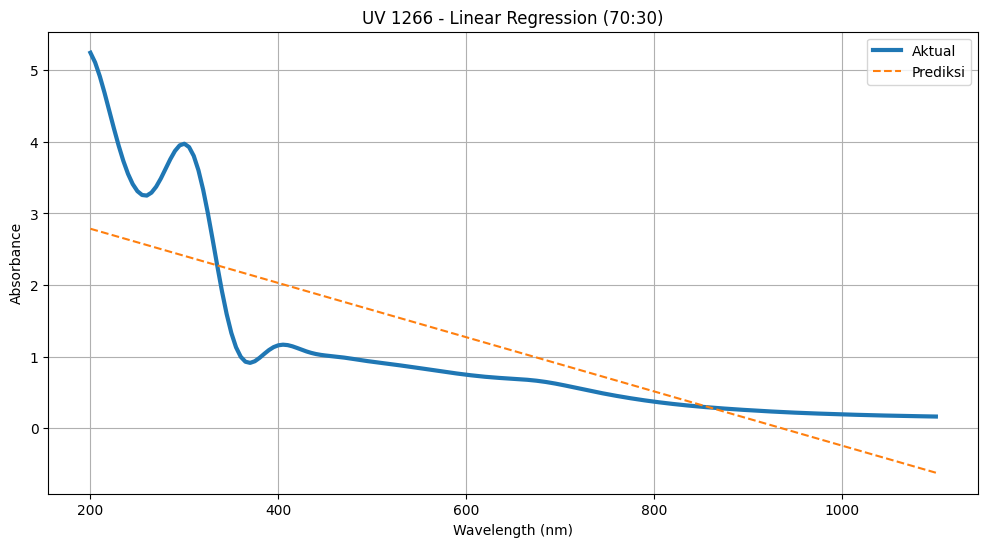


Residu Polynomial Regression


,Wavelength,Aktual,Prediksi,Residu
0,210,4.9146,3.900577,1.014023
1,245,3.4102,3.495379,-0.085179
2,260,3.2495,3.328660,-0.07916
3,275,3.4888,3.166103,0.322697
4,280,3.6221,3.112843,0.509257
5,290,3.8724,3.007710,0.86469
6,295,3.9506,2.955837,0.994763
7,320,3.3315,2.703410,0.62809
8,345,1.5968,2.462547,-0.865747
9,350,1.332,2.415762,-1.083762


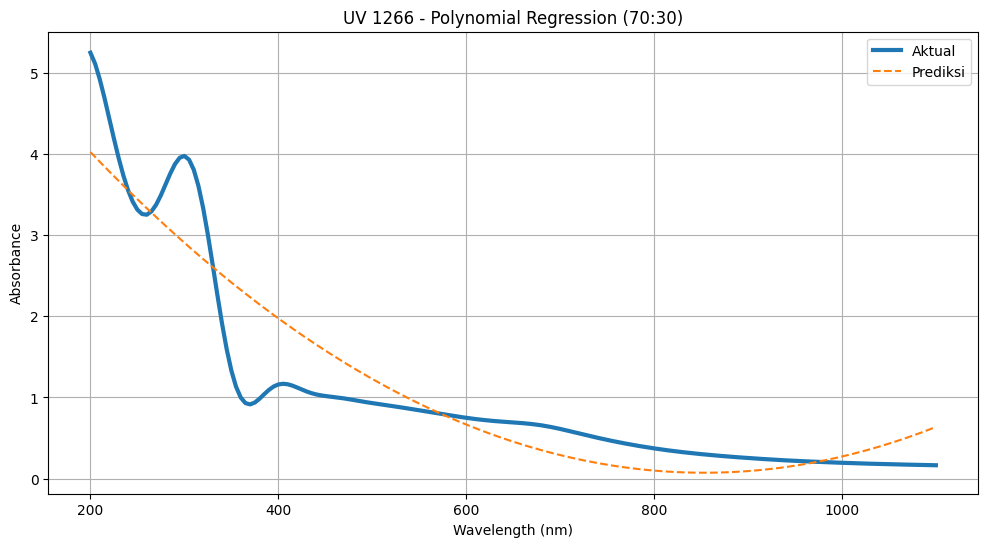


Residu Random Forest


,Wavelength,Aktual,Prediksi,Residu
0,210,4.9146,5.008250,-0.09365
1,245,3.4102,3.379398,0.030802
2,260,3.2495,3.288530,-0.03903
3,275,3.4888,3.405579,0.083221
4,280,3.6221,3.613040,0.00906
5,290,3.8724,3.831746,0.040654
6,295,3.9506,3.925051,0.025549
7,320,3.3315,3.432190,-0.10069
8,345,1.5968,2.084666,-0.487866
9,350,1.332,1.700107,-0.368107


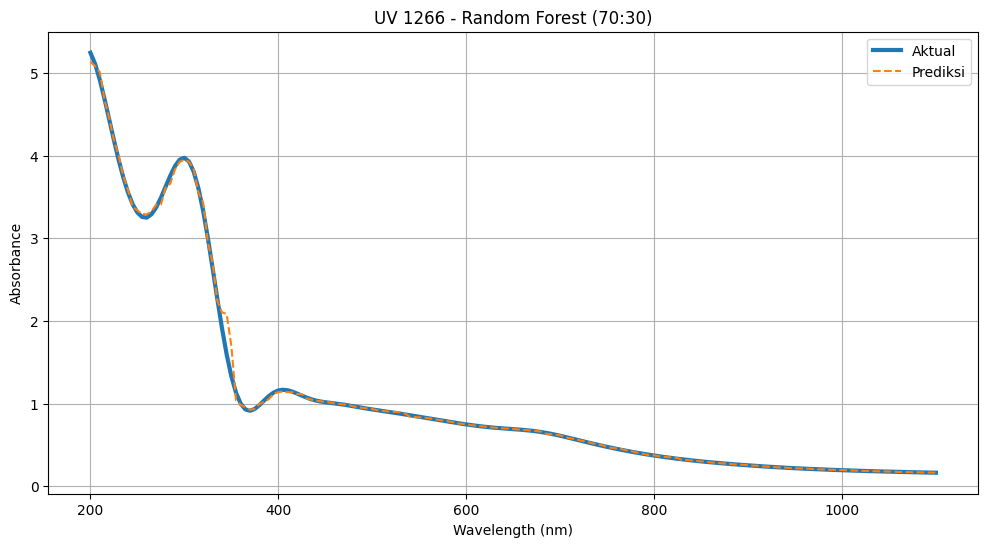


HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1266,70:30,Linear Regression,0.629928,0.712486
1,UV 1266,70:30,Polynomial Regression,0.834952,0.475816
2,UV 1266,70:30,Random Forest,0.994462,0.087162



Model terbaik : Random Forest


SAMPEL : UV 1266
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,525,0.8874
1,535,0.8695
2,355,1.1318
3,260,3.2495
4,405,1.168
...,...,...
139,730,0.5294
140,270,3.3737
141,660,0.6833
142,1095,0.1661



TEST DATA


,Wavelength,Absorbance
0,295,3.9506
1,410,1.162
2,965,0.2112
3,590,0.7658
4,925,0.2352
5,275,3.4888
6,320,3.3315
7,540,0.8603
8,765,0.442
9,790,0.3906



Residu Linear Regression


,Wavelength,Aktual,Prediksi,Residu
0,245,3.4102,2.575833,0.834367
1,275,3.4888,2.465061,1.023739
2,280,3.6221,2.446599,1.175501
3,290,3.8724,2.409675,1.462725
4,295,3.9506,2.391213,1.559387
5,320,3.3315,2.298903,1.032597
6,345,1.5968,2.206593,-0.609793
7,350,1.332,2.188131,-0.856131
8,410,1.162,1.966587,-0.804587
9,425,1.0972,1.911202,-0.814002


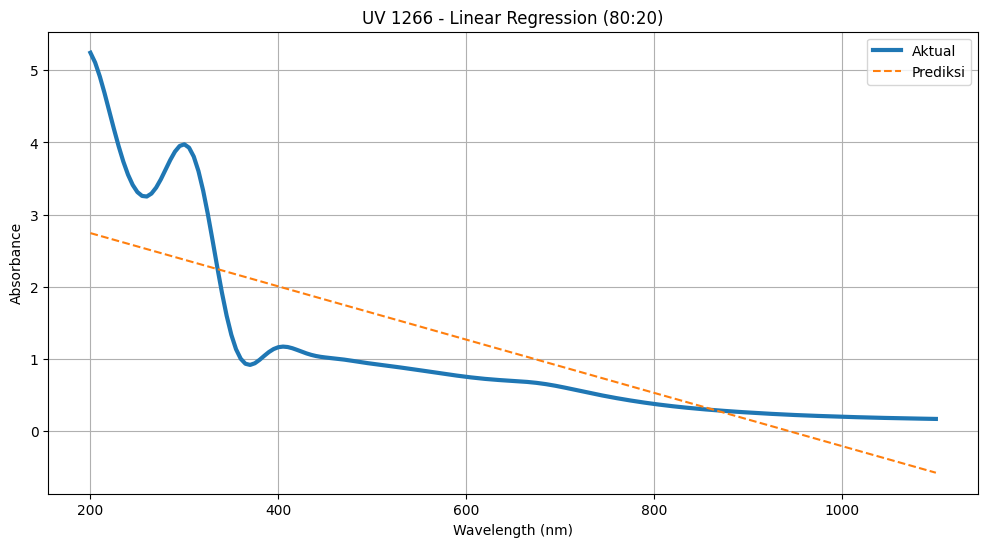


Residu Polynomial Regression


,Wavelength,Aktual,Prediksi,Residu
0,245,3.4102,3.459129,-0.048929
1,275,3.4888,3.131957,0.356843
2,280,3.6221,3.079039,0.543061
3,290,3.8724,2.974582,0.897818
4,295,3.9506,2.923044,1.027556
5,320,3.3315,2.672254,0.659246
6,345,1.5968,2.432965,-0.836165
7,350,1.332,2.386488,-1.054488
8,410,1.162,1.864643,-0.702643
9,425,1.0972,1.744533,-0.647333


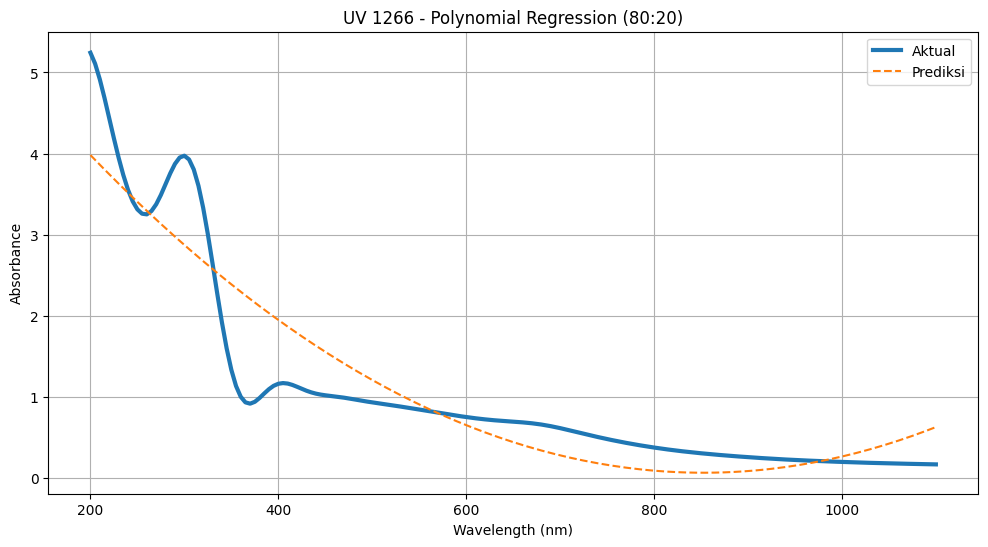


Residu Random Forest


,Wavelength,Aktual,Prediksi,Residu
0,245,3.4102,3.374131,0.036069
1,275,3.4888,3.389244,0.099556
2,280,3.6221,3.648695,-0.026595
3,290,3.8724,3.806624,0.065776
4,295,3.9506,3.902137,0.048463
5,320,3.3315,3.428146,-0.096646
6,345,1.5968,1.932266,-0.335466
7,350,1.332,1.193911,0.138089
8,410,1.162,1.157708,0.004292
9,425,1.0972,1.110888,-0.013688


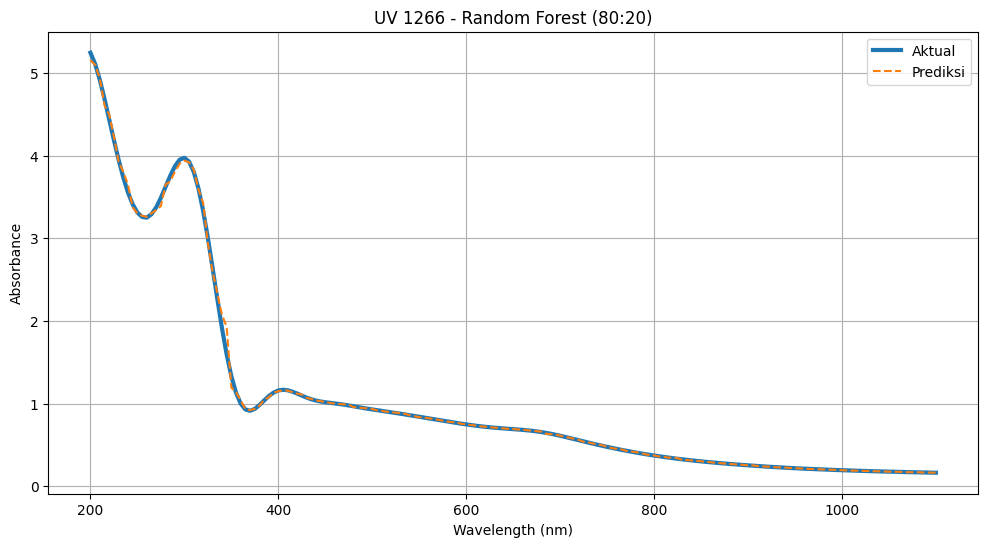


HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1266,80:20,Linear Regression,0.669266,0.668227
1,UV 1266,80:20,Polynomial Regression,0.854393,0.443380
2,UV 1266,80:20,Random Forest,0.996787,0.065862



Model terbaik : Random Forest


SAMPEL : UV 1266
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,480,0.9685
1,685,0.6471
2,800,0.3727
3,915,0.2424
4,350,1.332
...,...,...
157,730,0.5294
158,270,3.3737
159,660,0.6833
160,1095,0.1661



TEST DATA


,Wavelength,Absorbance
0,295,3.9506
1,410,1.162
2,965,0.2112
3,590,0.7658
4,925,0.2352
5,275,3.4888
6,320,3.3315
7,540,0.8603
8,765,0.442
9,790,0.3906



Residu Linear Regression


,Wavelength,Aktual,Prediksi,Residu
0,275,3.4888,2.438231,1.050569
1,280,3.6221,2.420018,1.202082
2,295,3.9506,2.365379,1.585221
3,320,3.3315,2.274313,1.057187
4,410,1.162,1.946478,-0.784478
5,425,1.0972,1.891838,-0.794638
6,455,1.0103,1.782560,-0.77226
7,540,0.8603,1.472937,-0.612637
8,545,0.8509,1.454724,-0.603824
9,590,0.7658,1.290806,-0.525006


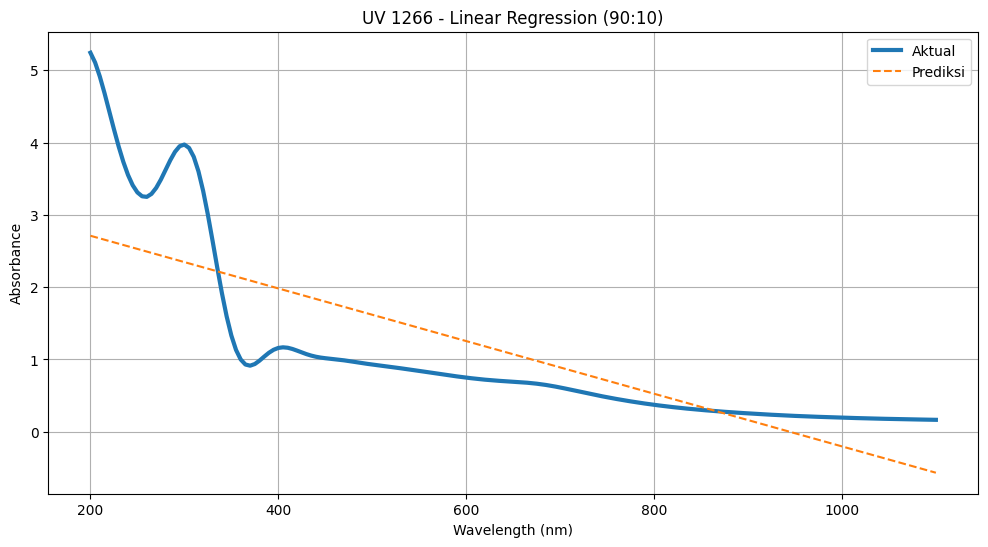


Residu Polynomial Regression


,Wavelength,Aktual,Prediksi,Residu
0,275,3.4888,3.099913,0.388887
1,280,3.6221,3.047706,0.574394
2,295,3.9506,2.893807,1.056793
3,320,3.3315,2.646379,0.685121
4,410,1.162,1.849520,-0.68752
5,425,1.0972,1.730997,-0.633797
6,455,1.0103,1.506196,-0.495896
7,540,0.8603,0.957927,-0.097627
8,545,0.8509,0.929758,-0.078858
9,590,0.7658,0.696643,0.069157


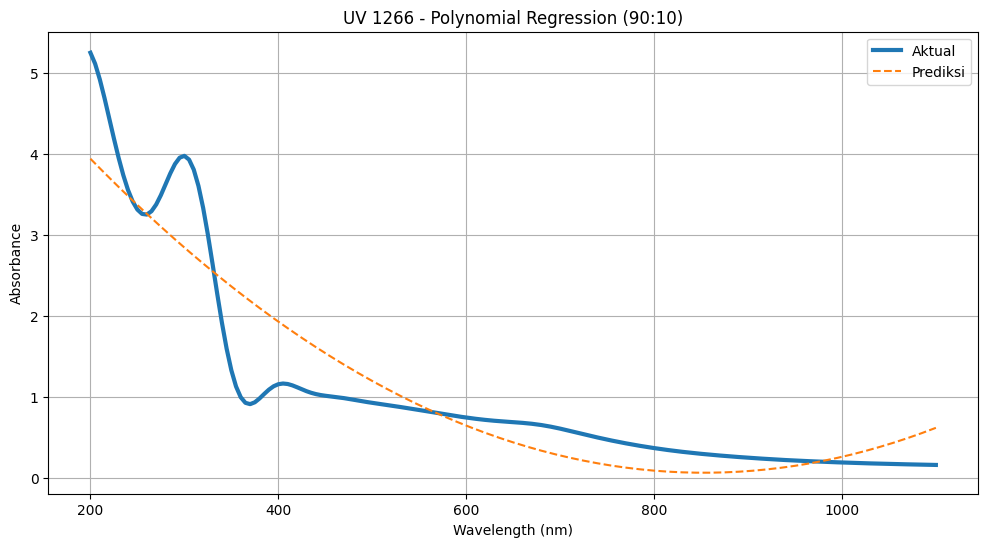


Residu Random Forest


,Wavelength,Aktual,Prediksi,Residu
0,275,3.4888,3.356832,0.131968
1,280,3.6221,3.663620,-0.04152
2,295,3.9506,3.878368,0.072232
3,320,3.3315,3.431858,-0.100358
4,410,1.162,1.160609,0.001391
5,425,1.0972,1.110055,-0.012855
6,455,1.0103,1.016233,-0.005933
7,540,0.8603,0.864989,-0.004689
8,545,0.8509,0.850249,0.000651
9,590,0.7658,0.761417,0.004383


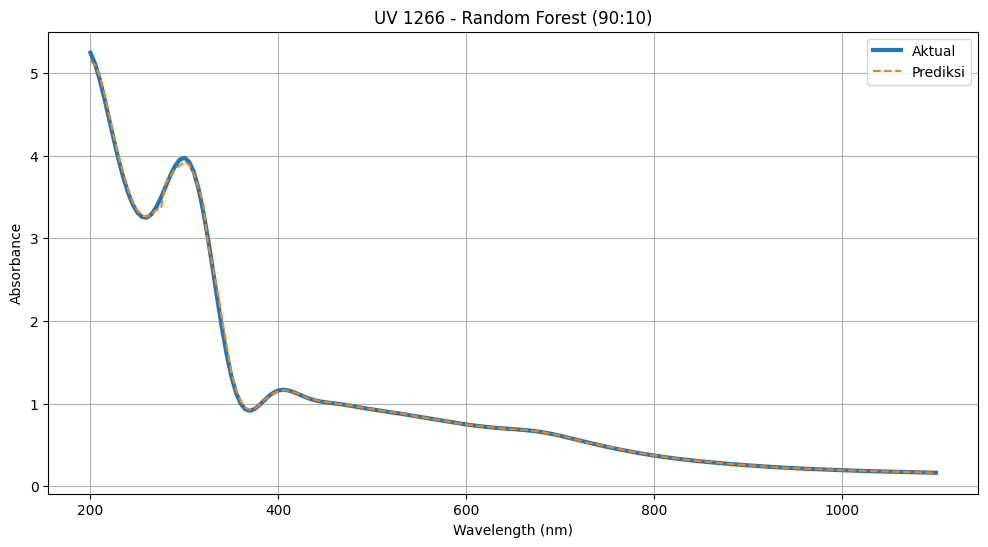


HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1266,90:10,Linear Regression,0.680302,0.710859
1,UV 1266,90:10,Polynomial Regression,0.877780,0.439526
2,UV 1266,90:10,Random Forest,0.998843,0.042772



Model terbaik : Random Forest


SAMPEL : UV 1267
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,760,0.4412
1,220,1.2108
2,360,1.067
3,705,0.5976
4,840,0.2988
...,...,...
103,730,0.5205
104,270,1.1977
105,660,0.6942
106,1095,0.1378



TEST DATA


,Wavelength,Absorbance
0,295,1.2434
1,410,1.0881
2,965,0.1896
3,590,0.7697
4,925,0.216
...,...,...
68,575,0.796
69,930,0.2122
70,255,1.0994
71,230,1.1279



Residu Linear Regression


,Wavelength,Aktual,Prediksi,Residu
0,210,1.3324,1.299944,0.032456
1,230,1.1279,1.271088,-0.143188
2,245,1.082,1.249446,-0.167446
3,255,1.0994,1.235018,-0.135618
4,260,1.1193,1.227805,-0.108505
...,...,...,...,...
68,1045,0.1533,0.095218,0.058082
69,1055,0.1498,0.080790,0.06901
70,1060,0.1481,0.073576,0.074524
71,1065,0.1465,0.066362,0.080138


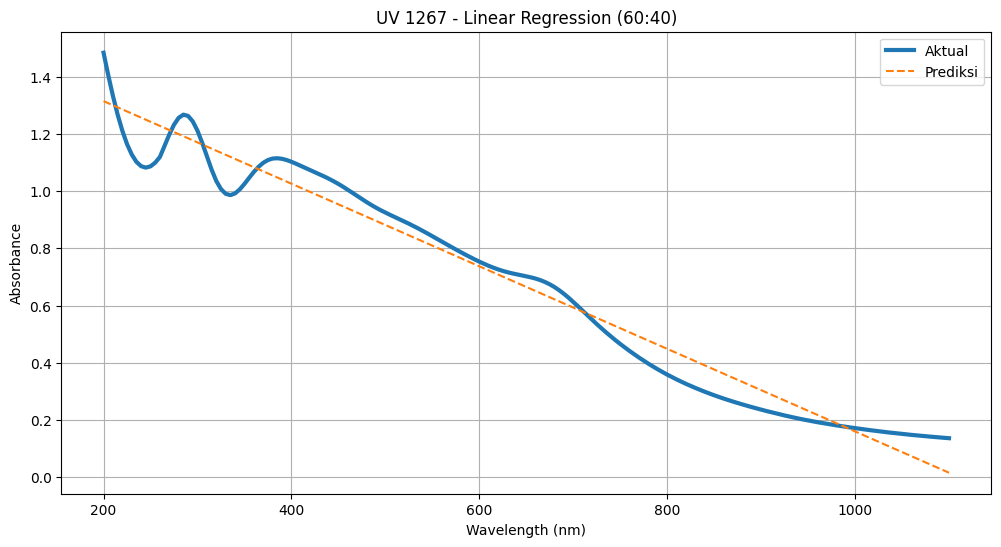


Residu Polynomial Regression


,Wavelength,Aktual,Prediksi,Residu
0,210,1.3324,1.312984,0.019416
1,230,1.1279,1.282372,-0.154472
2,245,1.082,1.259466,-0.177466
3,255,1.0994,1.244221,-0.144821
4,260,1.1193,1.236606,-0.117306
...,...,...,...,...
68,1045,0.1533,0.103942,0.049358
69,1055,0.1498,0.090319,0.059481
70,1060,0.1481,0.083516,0.064584
71,1065,0.1465,0.076717,0.069783


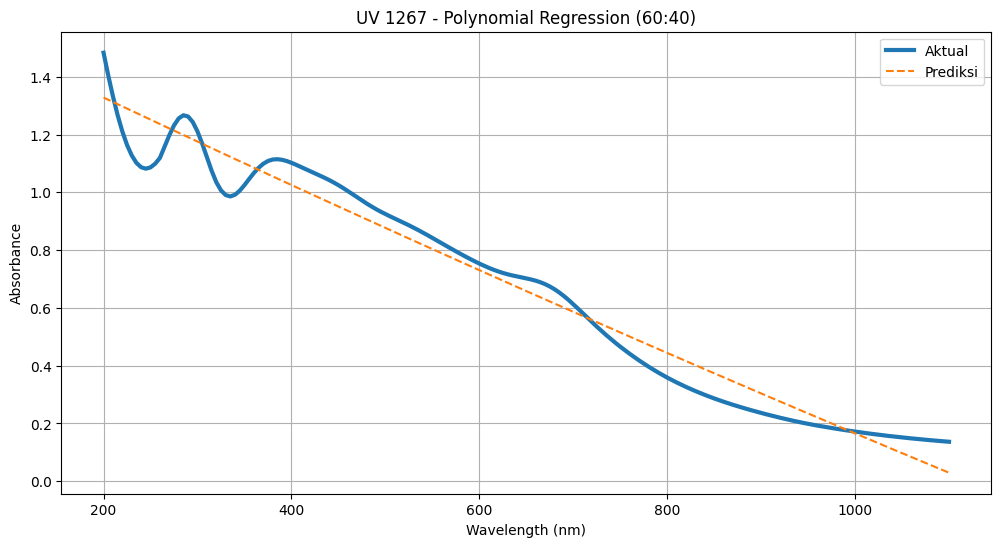


Residu Random Forest


,Wavelength,Aktual,Prediksi,Residu
0,210,1.3324,1.303638,0.028762
1,230,1.1279,1.143517,-0.015617
2,245,1.082,1.090196,-0.008196
3,255,1.0994,1.104677,-0.005277
4,260,1.1193,1.144450,-0.02515
...,...,...,...,...
68,1045,0.1533,0.154379,-0.001079
69,1055,0.1498,0.151635,-0.001835
70,1060,0.1481,0.149416,-0.001316
71,1065,0.1465,0.145811,0.000689


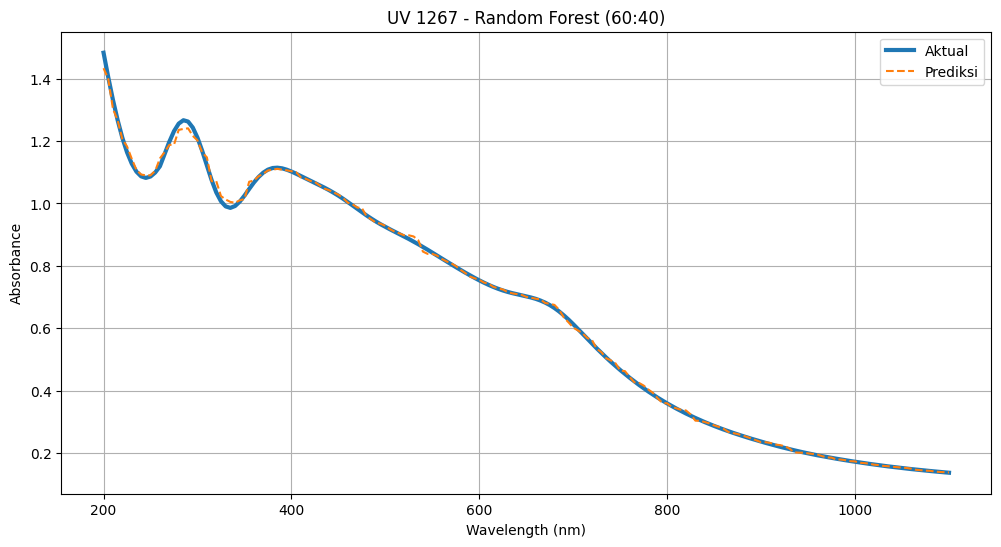


HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1267,60:40,Linear Regression,0.967204,0.069083
1,UV 1267,60:40,Polynomial Regression,0.966597,0.069720
2,UV 1267,60:40,Random Forest,0.998948,0.012370



Model terbaik : Random Forest


SAMPEL : UV 1267
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,625,0.7211
1,960,0.1924
2,610,0.7388
3,935,0.2086
4,330,0.9906
...,...,...
121,730,0.5205
122,270,1.1977
123,660,0.6942
124,1095,0.1378



TEST DATA


,Wavelength,Absorbance
0,295,1.2434
1,410,1.0881
2,965,0.1896
3,590,0.7697
4,925,0.216
5,275,1.2319
6,320,1.0354
7,540,0.8607
8,765,0.4295
9,790,0.377



Residu Linear Regression


,Wavelength,Aktual,Prediksi,Residu
0,210,1.3324,1.287154,0.045246
1,245,1.082,1.237304,-0.155304
2,260,1.1193,1.215940,-0.09664
3,275,1.2319,1.194576,0.037324
4,280,1.2561,1.187454,0.068646
5,290,1.2627,1.173211,0.089489
6,295,1.2434,1.166090,0.07731
7,320,1.0354,1.130483,-0.095083
8,345,1.0059,1.094876,-0.088976
9,350,1.0251,1.087754,-0.062654


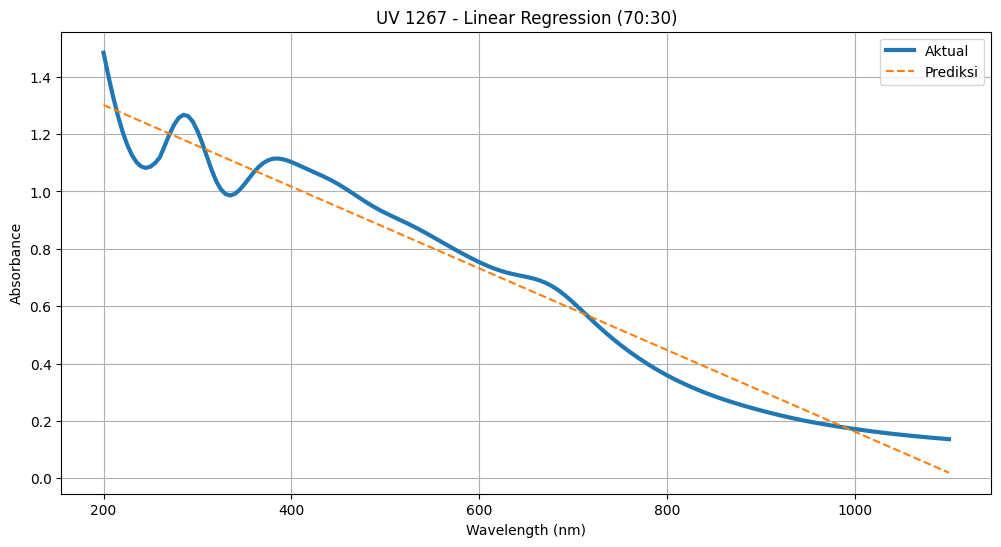


Residu Polynomial Regression


,Wavelength,Aktual,Prediksi,Residu
0,210,1.3324,1.288012,0.044388
1,245,1.082,1.237959,-0.155959
2,260,1.1193,1.216513,-0.097213
3,275,1.2319,1.195070,0.03683
4,280,1.2561,1.187923,0.068177
5,290,1.2627,1.173630,0.08907
6,295,1.2434,1.166484,0.076916
7,320,1.0354,1.130759,-0.095359
8,345,1.0059,1.095043,-0.089143
9,350,1.0251,1.087901,-0.062801


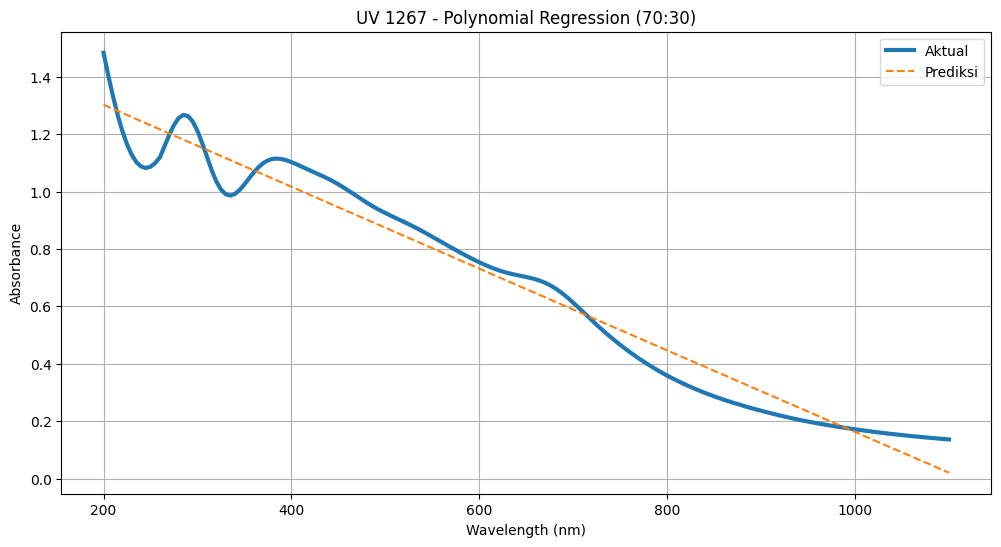


Residu Random Forest


,Wavelength,Aktual,Prediksi,Residu
0,210,1.3324,1.376806,-0.044406
1,245,1.082,1.088989,-0.006989
2,260,1.1193,1.111768,0.007532
3,275,1.2319,1.193571,0.038329
4,280,1.2561,1.234660,0.02144
5,290,1.2627,1.239806,0.022894
6,295,1.2434,1.215384,0.028016
7,320,1.0354,1.058555,-0.023155
8,345,1.0059,0.992621,0.013279
9,350,1.0251,1.012758,0.012342


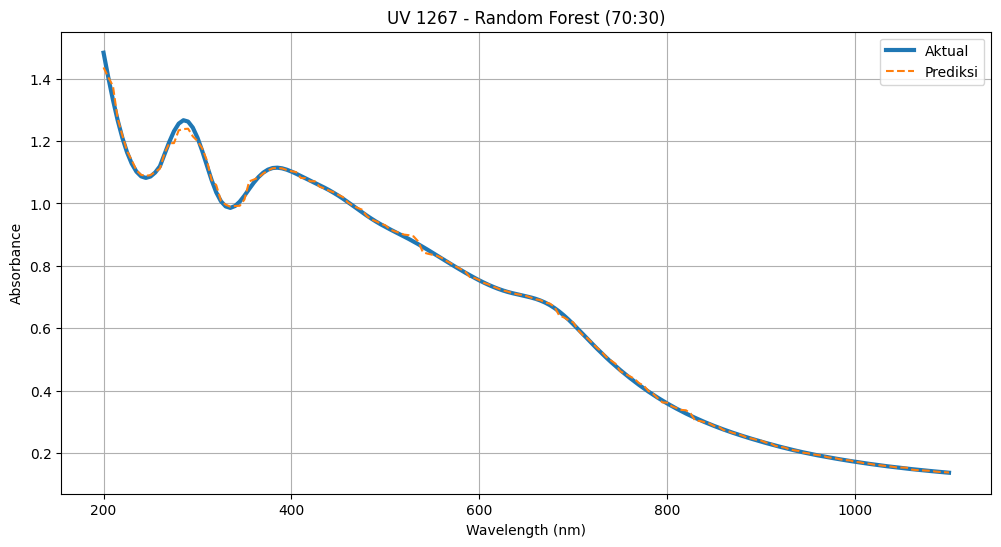


HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1267,70:30,Linear Regression,0.968946,0.068795
1,UV 1267,70:30,Polynomial Regression,0.968980,0.068757
2,UV 1267,70:30,Random Forest,0.998960,0.012589



Model terbaik : Random Forest


SAMPEL : UV 1267
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,525,0.8861
1,535,0.8694
2,355,1.0464
3,260,1.1193
4,405,1.0955
...,...,...
139,730,0.5205
140,270,1.1977
141,660,0.6942
142,1095,0.1378



TEST DATA


,Wavelength,Absorbance
0,295,1.2434
1,410,1.0881
2,965,0.1896
3,590,0.7697
4,925,0.216
5,275,1.2319
6,320,1.0354
7,540,0.8607
8,765,0.4295
9,790,0.377



Residu Linear Regression


,Wavelength,Aktual,Prediksi,Residu
0,245,1.082,1.239173,-0.157173
1,275,1.2319,1.196457,0.035443
2,280,1.2561,1.189337,0.066763
3,290,1.2627,1.175098,0.087602
4,295,1.2434,1.167979,0.075421
5,320,1.0354,1.132382,-0.096982
6,345,1.0059,1.096785,-0.090885
7,350,1.0251,1.089666,-0.064566
8,410,1.0881,1.004233,0.083867
9,425,1.066,0.982875,0.083125


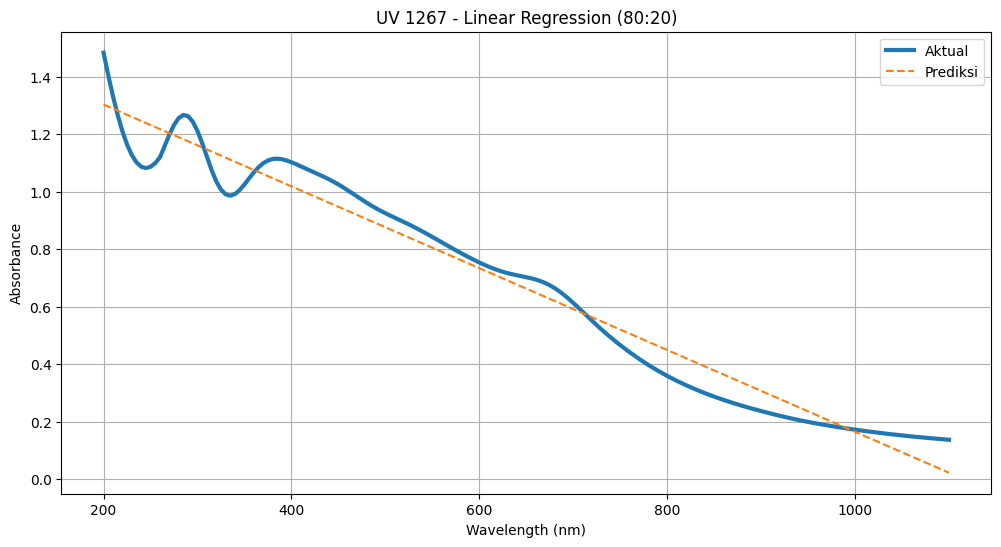


Residu Polynomial Regression


,Wavelength,Aktual,Prediksi,Residu
0,245,1.082,1.242598,-0.160598
1,275,1.2319,1.199042,0.032858
2,280,1.2561,1.191789,0.064311
3,290,1.2627,1.177289,0.085411
4,295,1.2434,1.170041,0.073359
5,320,1.0354,1.133830,-0.09843
6,345,1.0059,1.097663,-0.091763
7,350,1.0251,1.090435,-0.065335
8,410,1.0881,1.003838,0.084262
9,425,1.066,0.982229,0.083771


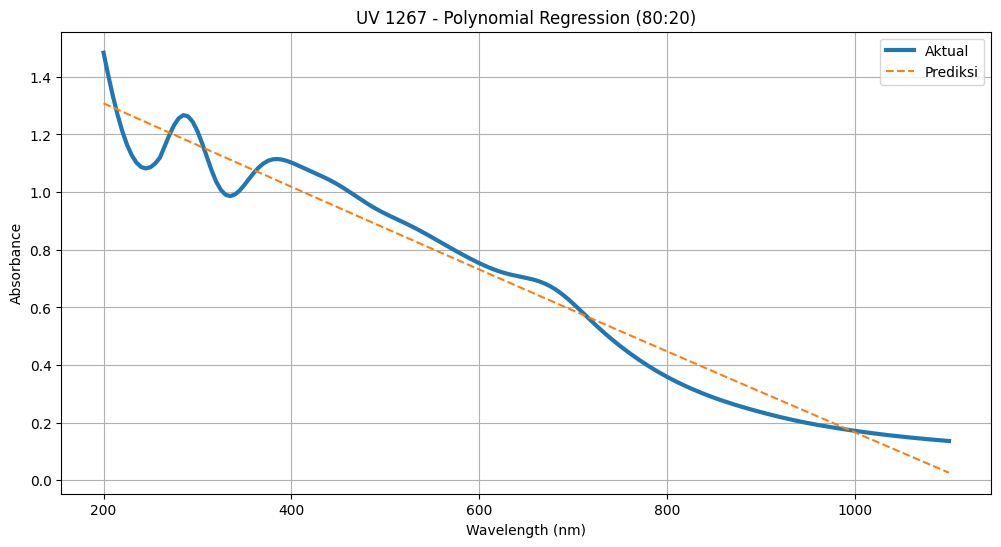


Residu Random Forest


,Wavelength,Aktual,Prediksi,Residu
0,245,1.082,1.088442,-0.006442
1,275,1.2319,1.191890,0.04001
2,280,1.2561,1.242846,0.013254
3,290,1.2627,1.245870,0.01683
4,295,1.2434,1.220524,0.022876
5,320,1.0354,1.059718,-0.024318
6,345,1.0059,0.996038,0.009862
7,350,1.0251,1.045893,-0.020793
8,410,1.0881,1.091036,-0.002936
9,425,1.066,1.069828,-0.003828


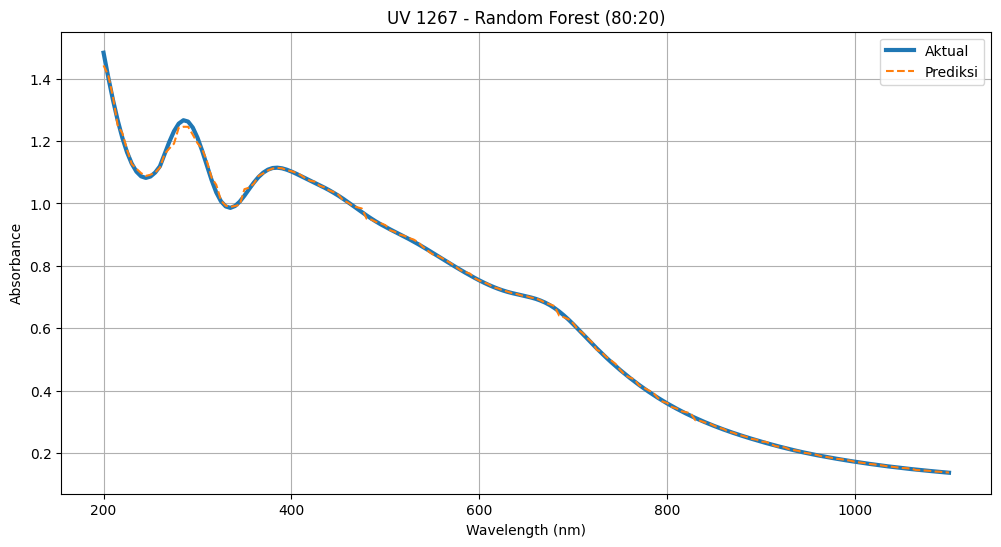


HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1267,80:20,Linear Regression,0.965782,0.070226
1,UV 1267,80:20,Polynomial Regression,0.965834,0.070173
2,UV 1267,80:20,Random Forest,0.999131,0.011188



Model terbaik : Random Forest


SAMPEL : UV 1267
Shape X : (181, 1)
Shape y : (181,)

TRAIN DATA


,Wavelength,Absorbance
0,480,0.9616
1,685,0.6536
2,800,0.3587
3,915,0.2238
4,350,1.0251
...,...,...
157,730,0.5205
158,270,1.1977
159,660,0.6942
160,1095,0.1378



TEST DATA


,Wavelength,Absorbance
0,295,1.2434
1,410,1.0881
2,965,0.1896
3,590,0.7697
4,925,0.216
5,275,1.2319
6,320,1.0354
7,540,0.8607
8,765,0.4295
9,790,0.377



Residu Linear Regression


,Wavelength,Aktual,Prediksi,Residu
0,275,1.2319,1.193948,0.037952
1,280,1.2561,1.186836,0.069264
2,295,1.2434,1.165498,0.077902
3,320,1.0354,1.129936,-0.094536
4,410,1.0881,1.001911,0.086189
5,425,1.066,0.980574,0.085426
6,455,1.0151,0.937899,0.077201
7,540,0.8607,0.816987,0.043713
8,545,0.8516,0.809874,0.041726
9,590,0.7697,0.745862,0.023838


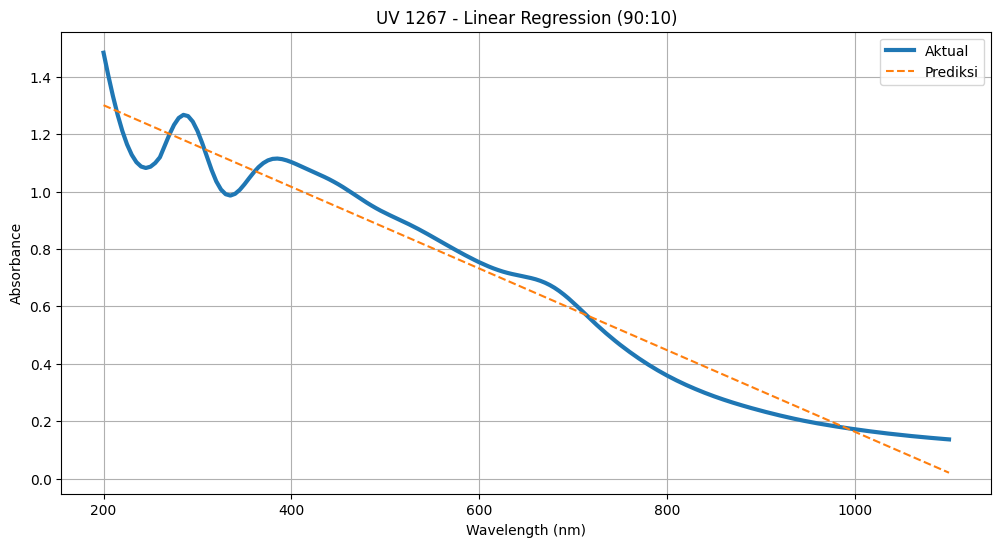


Residu Polynomial Regression


,Wavelength,Aktual,Prediksi,Residu
0,275,1.2319,1.196770,0.03513
1,280,1.2561,1.189512,0.066588
2,295,1.2434,1.167751,0.075649
3,320,1.0354,1.131522,-0.096122
4,410,1.0881,1.001498,0.086602
5,425,1.066,0.979888,0.086112
6,455,1.0151,0.936720,0.07838
7,540,0.8607,0.814791,0.045909
8,545,0.8516,0.807636,0.043964
9,590,0.7697,0.743329,0.026371


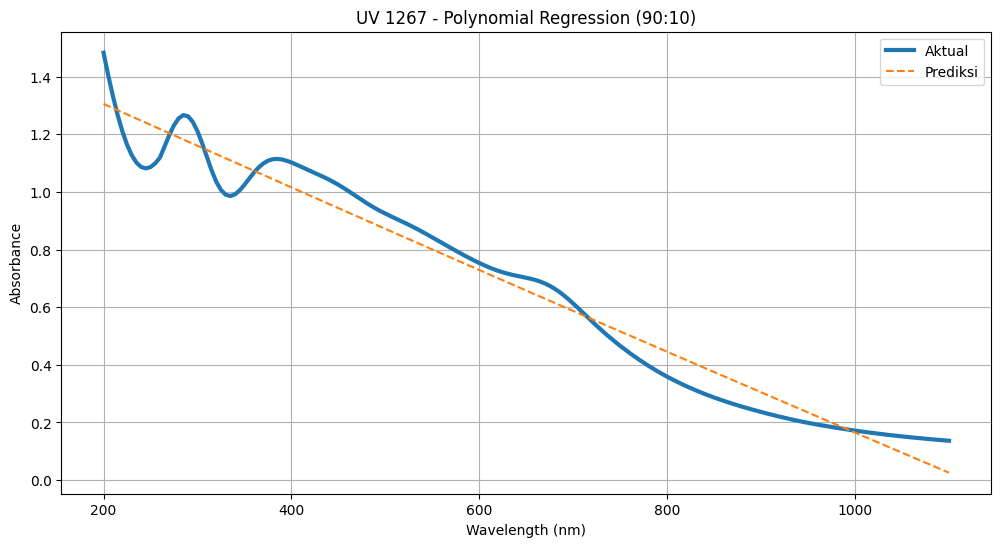


Residu Random Forest


,Wavelength,Aktual,Prediksi,Residu
0,275,1.2319,1.182509,0.049391
1,280,1.2561,1.244067,0.012033
2,295,1.2434,1.240357,0.003043
3,320,1.0354,1.060033,-0.024633
4,410,1.0881,1.091904,-0.003804
5,425,1.066,1.069761,-0.003761
6,455,1.0151,1.022468,-0.007368
7,540,0.8607,0.865031,-0.004331
8,545,0.8516,0.850819,0.000781
9,590,0.7697,0.765418,0.004282


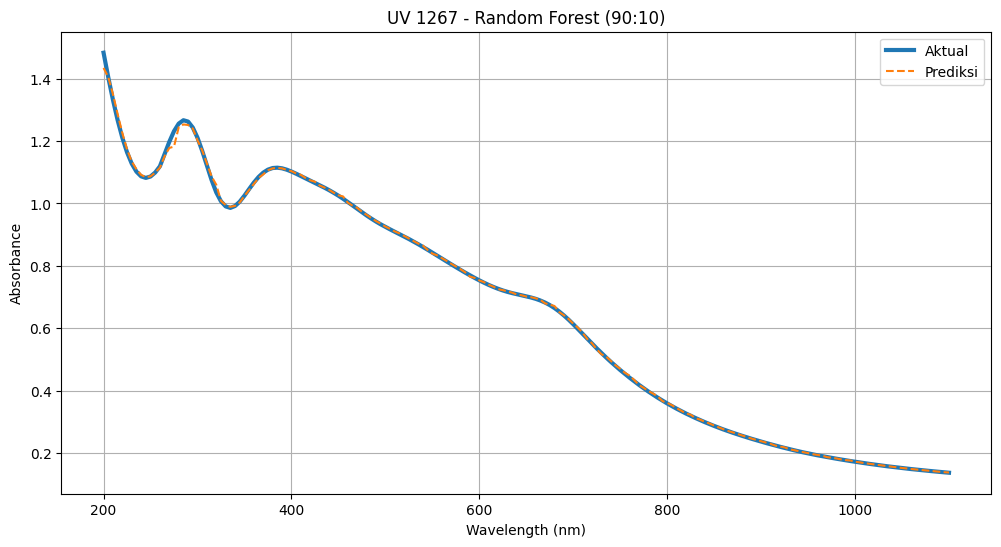


HASIL EVALUASI


,Sample,Split,Model,R2,RMSE
0,UV 1267,90:10,Linear Regression,0.971481,0.064214
1,UV 1267,90:10,Polynomial Regression,0.971498,0.064195
2,UV 1267,90:10,Random Forest,0.998755,0.013418



Model terbaik : Random Forest


In [18]:
best_prediction_s2 = {}
hasil_s2 = []
scenario2_samples = [

    'UV 1264',
    'UV 1265',
    'UV 1266',
    'UV 1267'

]

for sample in scenario2_samples:

    data = sample_data[sample]

    best_rmse = np.inf
    best_model_name = None
    best_pred_full = None

    for ts in split_list:

        hasil, model_name, pred_full = run_sample(

            sample_name=sample,

            transformed_data=data,

            test_size=ts,

            show_plot=True

        )

        hasil.insert(
            0,
            "Scenario",
            "Scenario 2"
        )

        hasil_s2.append(
            hasil
        )

        # Cari model terbaik
        current_rmse = hasil[
            'RMSE'
        ].min()

        if current_rmse < best_rmse:

            best_rmse = current_rmse

            best_model_name = model_name

            best_pred_full = pred_full

    # Simpan model terbaik sampel
    best_prediction_s2[
    f"{sample}_{int((1-ts)*100)}:{int(ts*100)}"
    ] = {
        'sample': sample,
        'split': f"{int((1-ts)*100)}:{int(ts*100)}",
        'model': best_model,
        'prediction': best_pred,
        'rmse_internal': best_rmse
    }

In [19]:
hasil_s2_df = pd.concat(

    hasil_s2,

    ignore_index=True

)

display(
    hasil_s2_df
)

,Scenario,Sample,Split,Model,R2,RMSE
0,Scenario 2,UV 1264,60:40,Linear Regression,0.596734,0.521653
1,Scenario 2,UV 1264,60:40,Polynomial Regression,0.754241,0.407231
2,Scenario 2,UV 1264,60:40,Random Forest,0.995025,0.057941
3,Scenario 2,UV 1264,70:30,Linear Regression,0.606055,0.526247
4,Scenario 2,UV 1264,70:30,Polynomial Regression,0.796119,0.378583
5,Scenario 2,UV 1264,70:30,Random Forest,0.996370,0.050512
6,Scenario 2,UV 1264,80:20,Linear Regression,0.644148,0.455123
7,Scenario 2,UV 1264,80:20,Polynomial Regression,0.791625,0.348271
8,Scenario 2,UV 1264,80:20,Random Forest,0.996429,0.045590
9,Scenario 2,UV 1264,90:10,Linear Regression,0.686715,0.452037


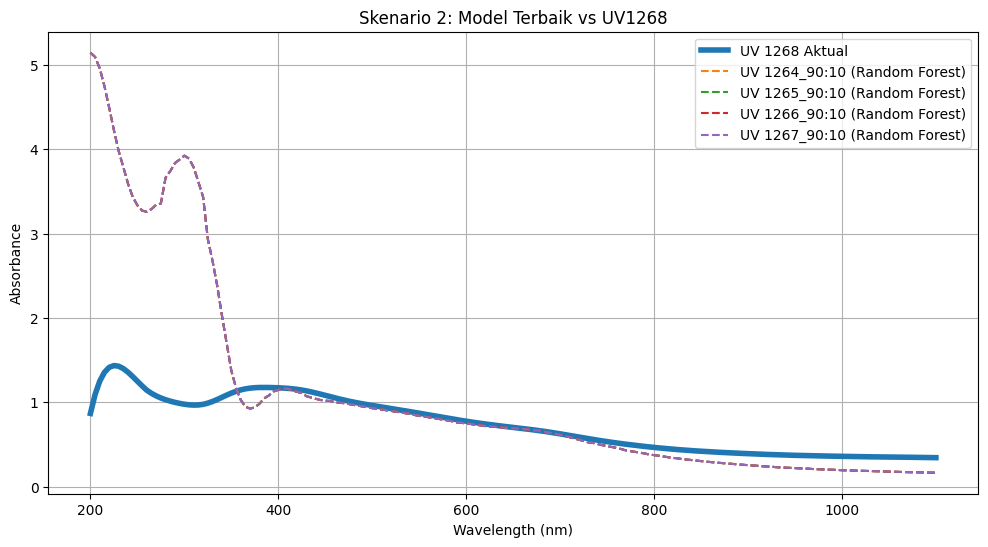

In [23]:
uv1268 = sample_data[
    'UV 1268'
]['Absorbance'].values

plt.figure(figsize=(12,6))

plt.plot(
    wavelength,
    uv1268,
    linewidth=4,
    label='UV 1268 Aktual'
)

for sample in best_prediction_s2:

    pred = best_prediction_s2[
        sample
    ]['prediction']

    model = best_prediction_s2[
        sample
    ]['model']

    plt.plot(
        wavelength,
        pred,
        '--',
        label=f'{sample} ({model})'
    )

plt.xlabel('Wavelength (nm)')
plt.ylabel('Absorbance')

plt.title(
    'Skenario 2: Model Terbaik vs UV1268'
)

plt.legend()
plt.grid(True)
plt.show()

In [24]:
comparison_s2 = []

for sample in best_prediction_s2:

    pred = best_prediction_s2[
        sample
    ]['prediction']

    rmse_uv1268 = np.sqrt(

        mean_squared_error(

            uv1268,

            pred

        )

    )

    comparison_s2.append([

        sample,

        best_prediction_s2[
            sample
        ]['model'],

        best_prediction_s2[
            sample
        ]['rmse_internal'],

        rmse_uv1268

    ])

In [25]:
comparison_s2 = pd.DataFrame(

    comparison_s2,

    columns=[

        'Sample',

        'Best Model',

        'RMSE Internal',

        'RMSE vs UV1268'

    ]

)

comparison_s2 = comparison_s2.sort_values(

    'RMSE vs UV1268'

)

display(
    comparison_s2
)

,Sample,Best Model,RMSE Internal,RMSE vs UV1268
0,UV 1264_90:10,Random Forest,0.045590,1.070066
1,UV 1265_90:10,Random Forest,0.046716,1.070066
2,UV 1266_90:10,Random Forest,0.042772,1.070066
3,UV 1267_90:10,Random Forest,0.011188,1.070066


In [27]:
hasil_all = pd.concat(

    [

        hasil_s1_df,

        hasil_s2_df

    ],

    ignore_index=True

)

print(
    "\nSEMUA HASIL"
)

display(
    hasil_all
)

hasil_all.to_excel(

    "hasil_model_uvvis.xlsx",

    index=False

)

print(
    "File berhasil disimpan"
)


SEMUA HASIL


,Scenario,Sample,Split,Model,R2,RMSE
0,Scenario 1,UV 1264,60:40,Linear Regression,0.596734,0.521653
1,Scenario 1,UV 1264,60:40,Polynomial Regression,0.754241,0.407231
2,Scenario 1,UV 1264,60:40,Random Forest,0.995025,0.057941
3,Scenario 1,UV 1264,70:30,Linear Regression,0.606055,0.526247
4,Scenario 1,UV 1264,70:30,Polynomial Regression,0.796119,0.378583
...,...,...,...,...,...,...
79,Scenario 2,UV 1267,80:20,Polynomial Regression,0.965834,0.070173
80,Scenario 2,UV 1267,80:20,Random Forest,0.999131,0.011188
81,Scenario 2,UV 1267,90:10,Linear Regression,0.971481,0.064214
82,Scenario 2,UV 1267,90:10,Polynomial Regression,0.971498,0.064195


File berhasil disimpan


## Testing atau Perbandingan Skenario 1 dengan UV 1267 

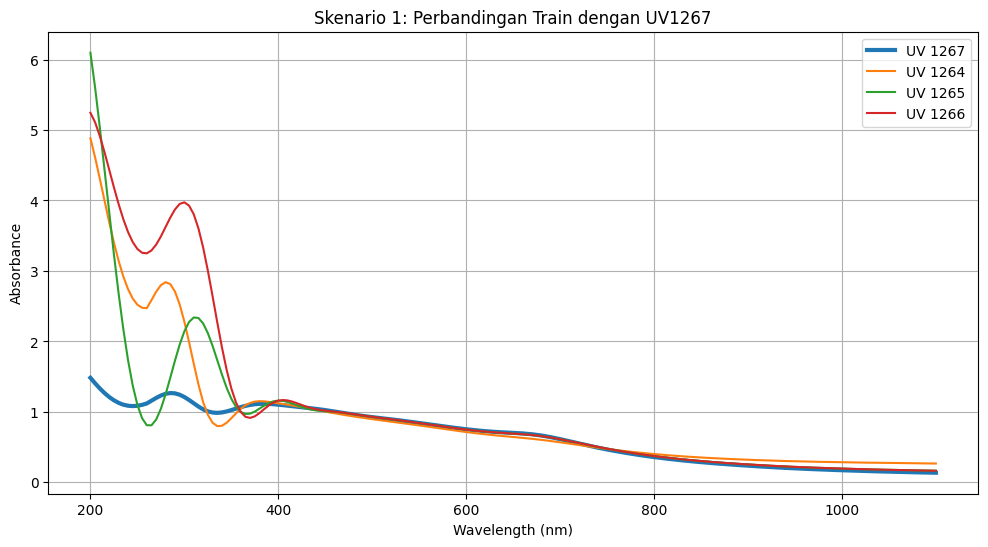

In [28]:
plt.figure(figsize=(12,6))

uv1267 = sample_data[
    'UV 1267'
]['Absorbance']

plt.plot(

    wavelength,

    uv1267,

    linewidth=3,

    label='UV 1267'

)

for sample in [

    'UV 1264',

    'UV 1265',

    'UV 1266'

]:

    plt.plot(

        wavelength,

        sample_data[sample][
            'Absorbance'
        ],

        label=sample

    )

plt.xlabel(
    'Wavelength (nm)'
)

plt.ylabel(
    'Absorbance'
)

plt.title(
    'Skenario 1: Perbandingan Train dengan UV1267'
)

plt.legend()

plt.grid(True)

plt.show()

## Testing atau Perbandingan Skenario 2 dengan UV 1268

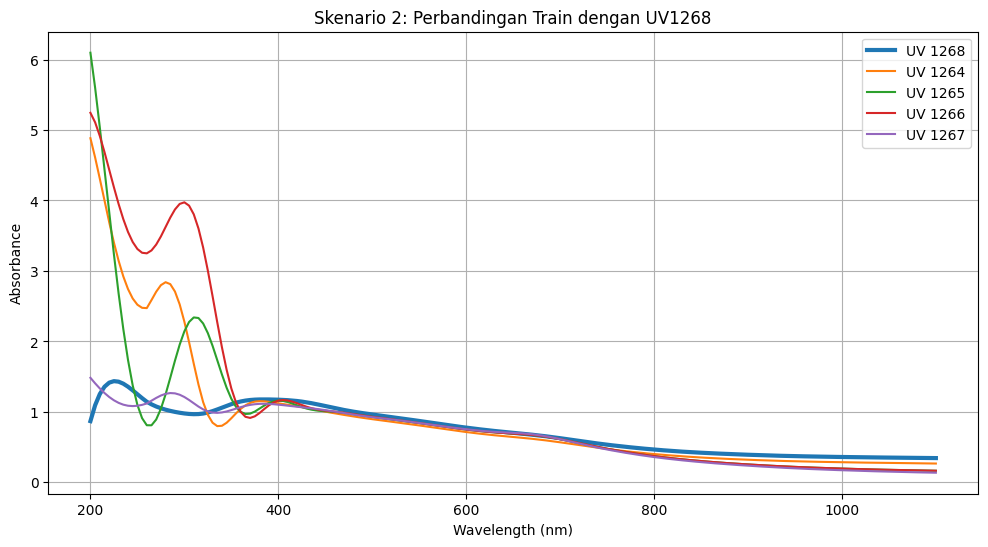

In [29]:
plt.figure(figsize=(12,6))

uv1268 = sample_data[
    'UV 1268'
]['Absorbance']

plt.plot(

    wavelength,

    uv1268,

    linewidth=3,

    label='UV 1268'

)

for sample in [

    'UV 1264',

    'UV 1265',

    'UV 1266',

    'UV 1267'

]:

    plt.plot(

        wavelength,

        sample_data[sample][
            'Absorbance'
        ],

        label=sample

    )

plt.xlabel(
    'Wavelength (nm)'
)

plt.ylabel(
    'Absorbance'
)

plt.title(
    'Skenario 2: Perbandingan Train dengan UV1268'
)

plt.legend()

plt.grid(True)

plt.show()

In [30]:
print("Jumlah eksperimen :", len(hasil_all))

display(
    hasil_all.sort_values(
        by=["Scenario", "Sample", "Split", "Model"]
    )
)

Jumlah eksperimen : 84


,Scenario,Sample,Split,Model,R2,RMSE
0,Scenario 1,UV 1264,60:40,Linear Regression,0.596734,0.521653
1,Scenario 1,UV 1264,60:40,Polynomial Regression,0.754241,0.407231
2,Scenario 1,UV 1264,60:40,Random Forest,0.995025,0.057941
3,Scenario 1,UV 1264,70:30,Linear Regression,0.606055,0.526247
4,Scenario 1,UV 1264,70:30,Polynomial Regression,0.796119,0.378583
...,...,...,...,...,...,...
79,Scenario 2,UV 1267,80:20,Polynomial Regression,0.965834,0.070173
80,Scenario 2,UV 1267,80:20,Random Forest,0.999131,0.011188
81,Scenario 2,UV 1267,90:10,Linear Regression,0.971481,0.064214
82,Scenario 2,UV 1267,90:10,Polynomial Regression,0.971498,0.064195


In [31]:
best_r2 = hasil_all.loc[
    hasil_all.groupby(
        ['Scenario', 'Sample']
    )['R2'].idxmax()
]

print("MODEL TERBAIK BERDASARKAN R²")

display(best_r2)

MODEL TERBAIK BERDASARKAN R²


,Scenario,Sample,Split,Model,R2,RMSE
8,Scenario 1,UV 1264,80:20,Random Forest,0.996429,0.045590
14,Scenario 1,UV 1265,60:40,Random Forest,0.992735,0.063791
35,Scenario 1,UV 1266,90:10,Random Forest,0.998843,0.042772
44,Scenario 2,UV 1264,80:20,Random Forest,0.996429,0.045590
50,Scenario 2,UV 1265,60:40,Random Forest,0.992735,0.063791
71,Scenario 2,UV 1266,90:10,Random Forest,0.998843,0.042772
80,Scenario 2,UV 1267,80:20,Random Forest,0.999131,0.011188


In [32]:
best_rmse = hasil_all.loc[
    hasil_all.groupby(
        ['Scenario', 'Sample']
    )['RMSE'].idxmin()
]

print("MODEL TERBAIK BERDASARKAN RMSE")

display(best_rmse)

MODEL TERBAIK BERDASARKAN RMSE


,Scenario,Sample,Split,Model,R2,RMSE
8,Scenario 1,UV 1264,80:20,Random Forest,0.996429,0.045590
20,Scenario 1,UV 1265,80:20,Random Forest,0.991850,0.046716
35,Scenario 1,UV 1266,90:10,Random Forest,0.998843,0.042772
44,Scenario 2,UV 1264,80:20,Random Forest,0.996429,0.045590
56,Scenario 2,UV 1265,80:20,Random Forest,0.991850,0.046716
71,Scenario 2,UV 1266,90:10,Random Forest,0.998843,0.042772
80,Scenario 2,UV 1267,80:20,Random Forest,0.999131,0.011188


In [33]:
mean_result = hasil_all.groupby(
    ['Model']
)[['R2', 'RMSE']].mean()

display(
    mean_result
)

,R2,RMSE
Model,,
Linear Regression,0.672072,0.469166
Polynomial Regression,0.758583,0.369578
Random Forest,0.995455,0.051304


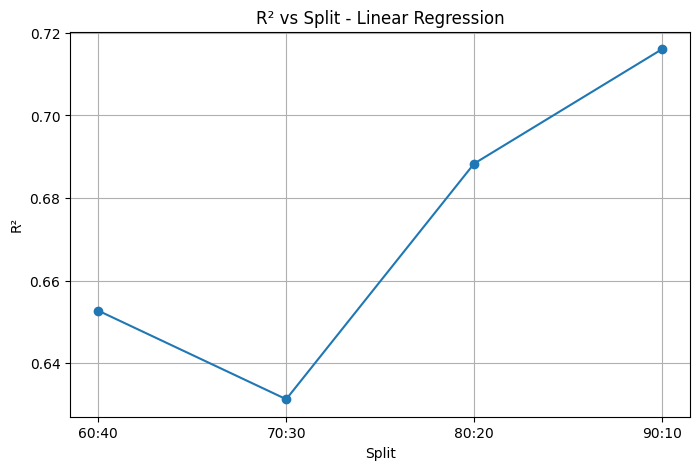

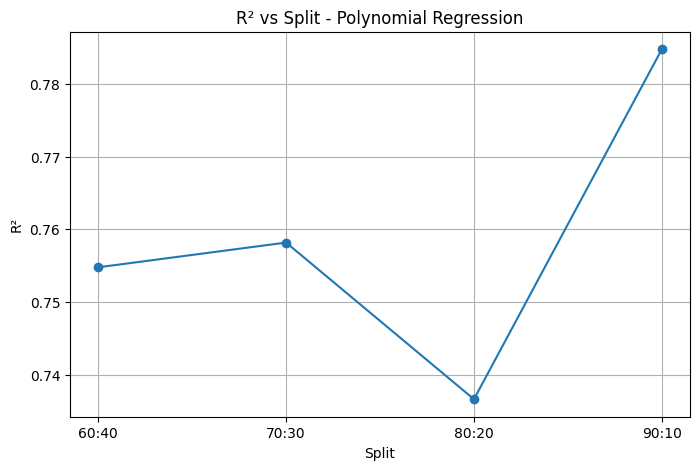

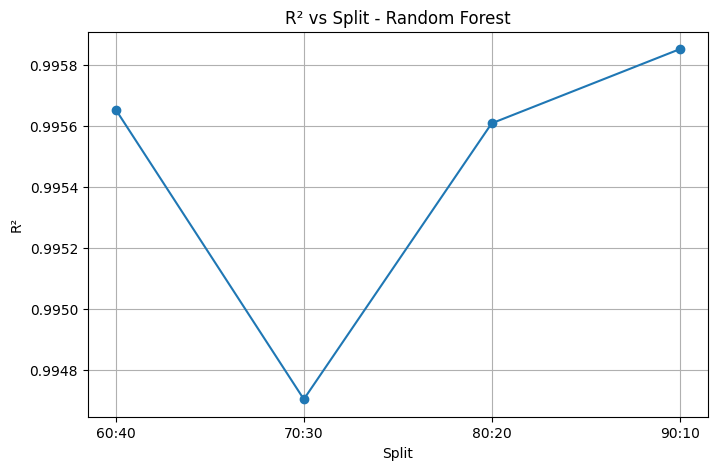

In [34]:
for model in hasil_all['Model'].unique():

    plt.figure(figsize=(8,5))

    data = hasil_all[
        hasil_all['Model'] == model
    ]

    mean_split = data.groupby(
        'Split'
    )['R2'].mean()

    plt.plot(
        mean_split.index,
        mean_split.values,
        marker='o'
    )

    plt.title(
        f'R² vs Split - {model}'
    )

    plt.xlabel('Split')
    plt.ylabel('R²')

    plt.grid(True)

    plt.show()

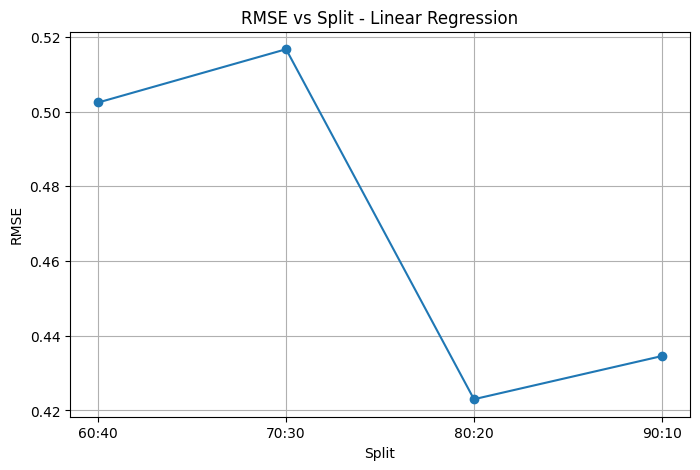

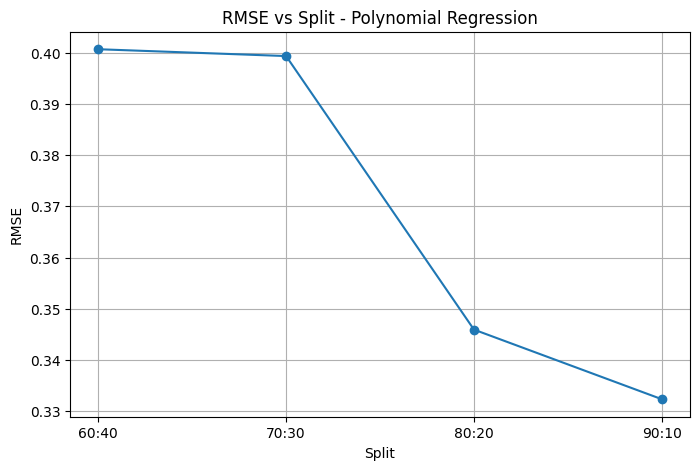

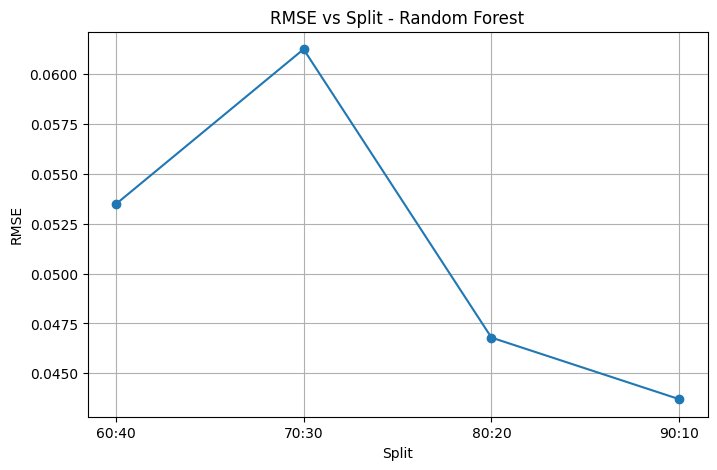

In [35]:
for model in hasil_all['Model'].unique():

    plt.figure(figsize=(8,5))

    data = hasil_all[
        hasil_all['Model'] == model
    ]

    mean_split = data.groupby(
        'Split'
    )['RMSE'].mean()

    plt.plot(
        mean_split.index,
        mean_split.values,
        marker='o'
    )

    plt.title(
        f'RMSE vs Split - {model}'
    )

    plt.xlabel('Split')
    plt.ylabel('RMSE')

    plt.grid(True)

    plt.show()

In [36]:
split_summary = hasil_all.groupby(
    'Split'
)[['R2', 'RMSE']].mean()

display(
    split_summary
)

best_split = split_summary[
    split_summary['R2']
    ==
    split_summary['R2'].max()
]

print("Split terbaik:")

display(best_split)

,R2,RMSE
Split,,
60:40,0.801037,0.318860
70:30,0.794707,0.325762
80:20,0.806844,0.271908
90:10,0.832225,0.270200


Split terbaik:


,R2,RMSE
Split,,
90:10,0.832225,0.2702
